# Leakage-Free Chronic Kidney Disease (CKD) Prediction
## MICE–ExtraTrees Imputation · Isolation Forest · Boruta–SHAP Selection · 8 Individual Learners + 3 Ensembles · Full Statistical, Robustness, Cost and Explainability Analysis

**Dataset:** UCI Chronic Kidney Disease (Kaggle mirror `mansoordaku/ckdisease`, file `kidney_disease.csv`), 400 patients × 24 clinical predictors + `id` + target.

**Design principle — leakage-free by construction.** The data are **split first**. Every step that *learns* anything from data
(LabelEncoder vocabularies, MICE–ExtraTrees imputation, Isolation Forest, Boruta–SHAP feature selection, hyperparameter search,
ensemble weights, stacking meta-learner) is **fit on the training portion only** and then *applied* to the held-out portion.
The same rule is re-applied **inside every fold** of the 10-fold cross-validation and inside every **random-seed** repetition of the
robustness analysis, so no reported number is contaminated by information from its own test patients.

| Stage | What happens | Fit on |
|---|---|---|
| Deterministic cleaning | whitespace/typo repair, missing-marker standardisation, numeric coercion, `id` removal, fixed plausibility bounds | nothing learned (row-wise rules) |
| Split | stratified 80/20 train/test (and 10 stratified folds for CV) | — |
| 1. LabelEncoder | categorical → integer codes | training split |
| 2. MICE + ExtraTrees | iterative imputation with an Extra-Trees regressor | training split |
| 3. Isolation Forest | outlier/noise detection; flagged **rows** removed from the training split only; **no feature is deleted** | training split |
| 4. Boruta–SHAP | shadow-feature statistical test using SHAP (primary) and RF-Gini (secondary) importance | training split |
| Models | 8 individual learners + stacking, soft voting, weighted voting | training split |
| Tuning | grid search with stratified inner CV | training split |

**Notebook map:** 0 Setup · 1 Data & cleaning · 2 Split first · 3 Leakage-free preprocessing · 4 Model zoo · 5 Baseline models ·
6 Hyperparameter optimisation · 7 10-fold CV, computational cost & proposed-model selection · 8 Diagnostic plots ·
9 Statistical significance (paired t-test, Bowker) · 10 Robustness (multi-seed) · 11 Cost analysis (5:1) · 12 Uncertainty (95% CI) ·
13 Surrogate trees · 14 SHAP + LIME · 15 Morris + permutation importance · 16 CKD risk factors · 17 Summary & export.

> **Kaggle settings:** turn **Internet ON** (needed once to `pip install` EBM/TabPFN/LIME/SALib and download the open TabPFN-v2 weights).
> A **GPU accelerator** makes TabPFN much faster but is optional. Expected run time on a 4-core CPU session is roughly 40–70 minutes.

## 0. Environment setup
### 0.1 Install any missing libraries

In [1]:
import importlib
import subprocess
import sys


def ensure_package(pip_name, import_name=None):
    """Import a package; install it with pip if it is missing. Returns True if importable afterwards."""
    import_name = import_name or pip_name
    try:
        importlib.import_module(import_name)
        return True
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=False)
        importlib.invalidate_caches()
        try:
            importlib.import_module(import_name)
            return True
        except ImportError:
            print(f"  !! {pip_name} could not be installed/imported.")
            return False


for pip_name, import_name in [("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("catboost", "catboost"),
                              ("interpret", "interpret"), ("shap", "shap"), ("lime", "lime"),
                              ("SALib", "SALib"), ("statsmodels", "statsmodels")]:
    ensure_package(pip_name, import_name)

# TabPFN (foundation model for tabular data). Installed separately because it depends on PyTorch.
TABPFN_IMPORTABLE = ensure_package("tabpfn", "tabpfn")

Installing interpret ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 20.1 MB/s eta 0:00:00
Installing tabpfn ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 33.8 MB/s eta 0:00:00


### 0.2 Imports

In [2]:
import os
import re
import gc
import json
import math
import time
import random
import pickle
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from scipy import stats
from scipy.cluster import hierarchy as sch
from scipy.spatial.distance import squareform

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (activates IterativeImputer)
from sklearn.impute import IterativeImputer
from sklearn.ensemble import (ExtraTreesRegressor, IsolationForest, RandomForestClassifier,
                              ExtraTreesClassifier, HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, cohen_kappa_score,
                             brier_score_loss, log_loss, accuracy_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

import xgboost
import lightgbm
import catboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
import SALib
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONWARNINGS", "ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "axes.titleweight": "bold",
                     "axes.titlesize": 11, "font.size": 10})

import sklearn
from importlib.metadata import version as _pkg_version
print("Python      :", sys.version.split()[0])
for _pkg in ["numpy", "pandas", "scikit-learn", "scipy", "xgboost", "lightgbm", "catboost", "interpret", "shap",
             "lime", "SALib", "statsmodels", "matplotlib", "seaborn", "tabpfn", "torch"]:
    try:
        print(f"{_pkg:<12}: {_pkg_version(_pkg)}")
    except Exception:
        print(f"{_pkg:<12}: not installed")

Python      : 3.12.13
numpy       : 2.0.2
pandas      : 2.3.3
scikit-learn: 1.6.1
scipy       : 1.16.3
xgboost     : 3.2.0
lightgbm    : 4.6.0
catboost    : 1.2.10
interpret   : 0.7.8
shap        : 0.51.0
lime        : 0.2.0.1
SALib       : 1.6.0
statsmodels : 0.14.6
matplotlib  : 3.10.0
seaborn     : 0.13.2
tabpfn      : 9.0.0
torch       : 2.10.0+cu128


### 0.3 Global configuration and reproducibility
All randomness is controlled by `RANDOM_STATE`. `FAST_MODE=True` shrinks every expensive loop for a quick smoke test;
**all reported results must be produced with `FAST_MODE=False`**.

In [3]:
FAST_MODE = os.environ.get("CKD_FAST_MODE", "0") == "1"      # keep False for the real run

DATA_DIR = os.environ.get("CKD_DATA_DIR", "/kaggle/input/datasets/mansoordaku/ckdisease")
_default_out = "/kaggle/working/ckd_outputs" if os.path.isdir("/kaggle/working") else "./ckd_outputs"
OUT_DIR = Path(os.environ.get("CKD_OUT_DIR", _default_out))
FIG_DIR, TAB_DIR = OUT_DIR / "figures", OUT_DIR / "tables"
for d in (OUT_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20                 # hold-out fraction (split FIRST)
INNER_CV_FOLDS = 5               # grid-search / stacking CV inside the training data
OUTER_CV_FOLDS = 10              # the 10-fold cross-validation requested
ROBUST_SEEDS = [42, 7, 21, 63, 99, 123, 256, 512, 777, 2024]   # multiple random seeds
DECISION_THRESHOLD = 0.50

MICE_ET_TREES, MICE_MAX_ITER = 50, 10                          # MICE with Extra-Trees estimator
IF_N_TREES, IF_CONTAMINATION = 300, 0.05                        # Isolation Forest
IF_REMOVE_TRAIN_OUTLIERS = True                                 # flagged rows removed from TRAIN only
BORUTA_TREES, BORUTA_MAX_DEPTH, BORUTA_MAX_ITER, BORUTA_ALPHA = 100, 6, 100, 0.05
BORUTA_MIN_FEATURES = 5

COST_FALSE, COST_CORRECT = 5.0, 1.0                              # cost ratio 5 : 1
N_BOOTSTRAP = 2000
SURROGATE_DEPTH = 3
PERM_REPEATS = 30
MORRIS_TRAJECTORIES, MORRIS_LEVELS = 100, 4
SHAP_BACKGROUND = 50
LIME_SAMPLES, LIME_PER_CLASS = 2000, 20
N_JOBS = -1

if FAST_MODE:
    ROBUST_SEEDS = ROBUST_SEEDS[:2]
    OUTER_CV_FOLDS, INNER_CV_FOLDS = 3, 3
    MICE_ET_TREES, MICE_MAX_ITER = 10, 3
    BORUTA_MAX_ITER = 20
    N_BOOTSTRAP, PERM_REPEATS, MORRIS_TRAJECTORIES = 200, 5, 20
    LIME_SAMPLES, LIME_PER_CLASS = 500, 5

def set_global_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
    except Exception:
        pass

set_global_seed()
NOTEBOOK_START = time.time()
print("FAST_MODE:", FAST_MODE, "| outputs ->", OUT_DIR.resolve())


def save_fig(fig, name):
    """Save a figure (PNG, 300 dpi) into the outputs folder and show it."""
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_table(df, name, index=True):
    df.to_csv(TAB_DIR / f"{name}.csv", index=index)
    return df

FAST_MODE: False | outputs -> /kaggle/working/ckd_outputs


## 1. Load the dataset, delete the `id` column, deterministic cleaning
### 1.1 Locate and load the raw CSV

In [4]:
def locate_dataset(preferred_dir):
    roots = [preferred_dir, "/kaggle/input/ckdisease", "/kaggle/input"]
    for root in roots:
        if root and os.path.isdir(root):
            csvs = sorted(Path(root).rglob("*.csv"))
            if csvs:
                csvs.sort(key=lambda p: (0 if re.search(r"kidney|ckd", p.name.lower()) else 1, len(str(p))))
                return csvs[0]
    raise FileNotFoundError(f"No CSV found under {roots}. Attach the 'mansoordaku/ckdisease' dataset.")


DATA_PATH = locate_dataset(DATA_DIR)
df_raw = pd.read_csv(DATA_PATH)
df_raw.to_csv(OUT_DIR / "raw_snapshot.csv", index=False)           # untouched provenance copy
print("Loaded:", DATA_PATH, "| shape:", df_raw.shape)
display(df_raw.head())
print(df_raw.dtypes.value_counts().to_string())

Loaded: /kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv | shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


object     14
float64    11
int64       1


### 1.2 Remove the complete `id` column
`id` is only a row index. The EDA showed it separates the classes perfectly (AUC = 1.0) purely because the source file lists all CKD rows
before all non-CKD rows, so it is a **leakage artefact** and is deleted from the dataset before anything else happens.

In [5]:
df_raw.columns = [str(c).strip().lower().replace(" ", "_") for c in df_raw.columns]
df_noid = df_raw.drop(columns=["id"])
assert "id" not in df_noid.columns
print("Shape after deleting `id`:", df_noid.shape)
print("Remaining columns:", list(df_noid.columns))

Shape after deleting `id`: (400, 25)
Remaining columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


### 1.3 Deterministic, label-free cleaning
These operations use fixed rules only (nothing is estimated from the data), so they are safe to apply before splitting:
whitespace/tab stripping, standardising missing markers (`?`, `\t?`, empty), lower-casing categories, coercing
`pcv`, `wc`, `rc` to numbers, canonicalising the target, and setting physiologically impossible values to missing
using the **same wide sanity bounds as the EDA** (these are data-entry errors such as `sod = 4.5`, `pot = 47`; the imputer fills them later).

In [6]:
TARGET = "classification"
NUMERIC_COLS = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc", "sod", "pot", "hemo", "pcv", "wc", "rc"]
CATEGORICAL_COLS = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]
ORDINAL_COLS = ["sg", "al", "su"]                       # snapped to observed levels after imputation
MISSING_MARKERS = {"", "?", "??", "na", "n/a", "nan", "none", "null", "<na>", "-", "--", "missing"}
CATEGORY_LEVELS = {"rbc": {"normal", "abnormal"}, "pc": {"normal", "abnormal"},
                   "pcc": {"present", "notpresent"}, "ba": {"present", "notpresent"},
                   "htn": {"yes", "no"}, "dm": {"yes", "no"}, "cad": {"yes", "no"},
                   "appet": {"good", "poor"}, "pe": {"yes", "no"}, "ane": {"yes", "no"}}
TARGET_MAP = {"ckd": "ckd", "notckd": "notckd", "ckd.": "ckd", "1": "ckd", "0": "notckd"}
PLAUSIBILITY_BOUNDS = {"age": (0, 120), "bp": (30, 300), "sg": (1.000, 1.060), "al": (0, 5), "su": (0, 5),
                       "bgr": (10, 1000), "bu": (1, 500), "sc": (0.1, 100), "sod": (100, 180), "pot": (1.5, 10),
                       "hemo": (1, 25), "pcv": (5, 75), "wc": (500, 100000), "rc": (1, 10)}
FEATURE_LABELS = {"age": "Age (years)", "bp": "Blood pressure", "sg": "Specific gravity", "al": "Albumin grade",
                  "su": "Sugar grade", "rbc": "Red blood cells (urine)", "pc": "Pus cells", "pcc": "Pus cell clumps",
                  "ba": "Bacteria", "bgr": "Blood glucose random", "bu": "Blood urea", "sc": "Serum creatinine",
                  "sod": "Sodium", "pot": "Potassium", "hemo": "Hemoglobin", "pcv": "Packed cell volume",
                  "wc": "White blood cell count", "rc": "Red blood cell count", "htn": "Hypertension",
                  "dm": "Diabetes mellitus", "cad": "Coronary artery disease", "appet": "Appetite",
                  "pe": "Pedal edema", "ane": "Anemia"}


def clean_ckd(df):
    df = df.copy()
    log = {"unexpected_categories": [], "numeric_conversion_failures": {}, "implausible_values": []}
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            s = df[c].astype("object").map(lambda v: v if pd.isna(v) else re.sub(r"\s+", "", str(v)).lower())
            df[c] = s.map(lambda v: np.nan if (pd.isna(v) or v in MISSING_MARKERS) else v).astype("object")
    for c in NUMERIC_COLS:
        before = df[c].notna()
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")
        failed = int((before & df[c].isna()).sum())
        if failed:
            log["numeric_conversion_failures"][c] = failed
    for c, levels in CATEGORY_LEVELS.items():
        bad = df[c].notna() & ~df[c].isin(levels)
        if bad.any():
            log["unexpected_categories"].append((c, df.loc[bad, c].unique().tolist()))
            df.loc[bad, c] = np.nan
    df[TARGET] = df[TARGET].map(lambda v: TARGET_MAP.get(v, v) if pd.notna(v) else v)
    for c, (lo, hi) in PLAUSIBILITY_BOUNDS.items():
        bad = df[c].notna() & ((df[c] < lo) | (df[c] > hi))
        for idx in df.index[bad]:
            log["implausible_values"].append({"row": int(idx), "feature": c, "value": float(df.at[idx, c]),
                                              "bounds": f"[{lo}, {hi}]", "action": "set to missing"})
        df.loc[bad, c] = np.nan
    return df, log


df, clean_log = clean_ckd(df_noid)
assert set(df[TARGET].dropna().unique()) == {"ckd", "notckd"} and df[TARGET].notna().all()
print("Clean shape:", df.shape)
print("Numeric conversion failures:", clean_log["numeric_conversion_failures"] or "none")
print("Unexpected category values:", clean_log["unexpected_categories"] or "none")
print("\nImplausible (data-entry) values set to missing:")
display(pd.DataFrame(clean_log["implausible_values"]))
print("\nTarget distribution:")
display(pd.DataFrame({"count": df[TARGET].value_counts(), "percent": df[TARGET].value_counts(normalize=True).mul(100).round(2)}))
miss = df.drop(columns=TARGET).isna().mean().mul(100).sort_values(ascending=False)
print("Rows with >=1 missing predictor: %.1f%%" % (df.drop(columns=TARGET).isna().any(axis=1).mean() * 100))
display(miss.head(10).round(2).to_frame("missing %").T)
df.to_csv(OUT_DIR / "clean_dataset_no_id.csv", index=False)

Clean shape: (400, 25)
Numeric conversion failures: none
Unexpected category values: none

Implausible (data-entry) values set to missing:


,row,feature,value,bounds,action
0,21,sod,4.5,"[100, 180]",set to missing
1,61,pot,39.0,"[1.5, 10]",set to missing
2,128,pot,47.0,"[1.5, 10]",set to missing



Target distribution:


,count,percent
classification,,
ckd,250,62.5
notckd,150,37.5


Rows with >=1 missing predictor: 60.8%


,rbc,rc,wc,pot,sod,pcv,pc,hemo,su,sg
missing %,38.0,32.75,26.5,22.5,22.0,17.75,16.25,13.0,12.25,11.75


## 2. Split FIRST (stratified 80/20) — the basis of leakage-free preprocessing
The hold-out test set is sealed now. It is never used to fit an encoder, imputer, outlier detector, feature selector,
hyperparameter or ensemble weight.

In [7]:
X_all_raw = df.drop(columns=[TARGET])
y_all_raw = df[TARGET].copy()
assert set(X_all_raw.columns) == set(NUMERIC_COLS + CATEGORICAL_COLS) and "id" not in X_all_raw.columns
FEATURES_ALL = list(X_all_raw.columns)
print("Predictors (%d):" % len(FEATURES_ALL), FEATURES_ALL)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_all_raw, y_all_raw, test_size=TEST_SIZE, stratify=y_all_raw, random_state=RANDOM_STATE)

# Target encoding with LabelEncoder (fit on the training labels). LabelEncoder sorts classes alphabetically
# (ckd -> 0, notckd -> 1); we re-express it so that CKD is the POSITIVE class (1), which all clinical metrics assume.
target_encoder = LabelEncoder().fit(y_train_raw)
assert list(target_encoder.classes_) == ["ckd", "notckd"]
CKD_CODE = int(target_encoder.transform(["ckd"])[0])


def encode_target(y_raw):
    return pd.Series((target_encoder.transform(y_raw) == CKD_CODE).astype(int), index=y_raw.index, name="ckd")


y_train = encode_target(y_train_raw)
y_test = encode_target(y_test_raw)
y_all = encode_target(y_all_raw)
CLASS_NAMES = ["Non-CKD", "CKD"]

split_summary = pd.DataFrame({
    "n": [len(y_train), len(y_test)],
    "CKD (1)": [int(y_train.sum()), int(y_test.sum())],
    "Non-CKD (0)": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "CKD %": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]}, index=["train", "test"])
display(split_summary)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)

Predictors (24): ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


,n,CKD (1),Non-CKD (0),CKD %
train,320,200,120,62.5
test,80,50,30,62.5


## 3. Leakage-free preprocessing (fit on the training split only)
The four steps are implemented as re-usable components and bundled in `CKDPreprocessor`, so that **exactly the same code**
is later re-fitted inside every CV fold and every robustness seed.
### 3.0 Preprocessing components

In [8]:
class CategoricalLabelEncoder(BaseEstimator, TransformerMixin):
    """One sklearn LabelEncoder per categorical column, fitted on the non-missing TRAINING values.
    Missing values stay missing (they are imputed next); unseen categories become missing."""

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.encoders_ = {c: LabelEncoder().fit(X[c].dropna().astype(str)) for c in self.columns}
        return self

    def transform(self, X):
        X = X.copy()
        for c, le in self.encoders_.items():
            s = X[c].astype("object")
            known = s.notna() & s.astype(str).isin(le.classes_)
            out = pd.Series(np.nan, index=X.index, dtype="float64")
            if known.any():
                out[known] = le.transform(s[known].astype(str)).astype(float)
            X[c] = out
        return X.astype("float64")

    def mapping_table(self):
        return pd.DataFrame([{"feature": c, **{f"code {i}": cls for i, cls in enumerate(le.classes_)}}
                             for c, le in self.encoders_.items()]).set_index("feature")


class MICEExtraTreesImputer(BaseEstimator, TransformerMixin):
    """MICE (IterativeImputer) with an ExtraTreesRegressor as the conditional model for each feature.
    Imputed categorical codes and ordinal grades are snapped to the nearest level observed in training."""

    def __init__(self, discrete_cols, n_trees=50, max_iter=10, random_state=42):
        self.discrete_cols = discrete_cols
        self.n_trees = n_trees
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y=None):
        self.columns_ = list(X.columns)
        self.imputer_ = IterativeImputer(
            estimator=ExtraTreesRegressor(n_estimators=self.n_trees, random_state=self.random_state, n_jobs=N_JOBS),
            max_iter=self.max_iter, initial_strategy="median", imputation_order="ascending",
            random_state=self.random_state, skip_complete=True)
        self.imputer_.fit(X[self.columns_].to_numpy(dtype=float))
        self.levels_ = {c: np.sort(X[c].dropna().unique()) for c in self.discrete_cols if c in self.columns_}
        self.lo_, self.hi_ = X[self.columns_].min(), X[self.columns_].max()
        return self

    def transform(self, X):
        A = self.imputer_.transform(X[self.columns_].to_numpy(dtype=float))
        out = pd.DataFrame(A, columns=self.columns_, index=X.index)
        out = out.clip(lower=self.lo_, upper=self.hi_, axis=1)
        for c, lv in self.levels_.items():
            out[c] = lv[np.abs(out[c].to_numpy()[:, None] - lv[None, :]).argmin(axis=1)]
        return out


def shap_positive_class(sv):
    """Return the SHAP matrix of the positive class for any shap output format."""
    if hasattr(sv, "values"):
        sv = sv.values
    if isinstance(sv, list):
        return np.asarray(sv[1] if len(sv) > 1 else sv[0])
    sv = np.asarray(sv)
    return sv[..., 1] if sv.ndim == 3 else sv


def bh_reject(pvals, alpha):
    """Benjamini-Hochberg: boolean mask of rejected hypotheses."""
    p = np.asarray(pvals, float)
    n = len(p)
    if n == 0:
        return np.zeros(0, bool)
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.zeros(n, bool)
    out[order] = ranked <= alpha
    return out


class BorutaSHAPSelector:
    """Hybrid Boruta-SHAP feature selection.

    Boruta: every iteration appends a shuffled 'shadow' copy of each still-active feature, fits a Random Forest, and records a
    'hit' when a real feature is more important than the best shadow. Two-step binomial tests (BH-FDR and alpha/iteration,
    as in BorutaPy) confirm or reject features. The procedure is run twice with two importance measures:
      * SHAP  (mean |TreeSHAP| of the CKD class)      -> primary decision
      * Gini  (Random Forest impurity importance)      -> secondary evidence
    Hybrid rule: selected = SHAP-Confirmed  OR  (SHAP-Tentative AND Gini-Confirmed). SHAP-Rejected features are never kept."""

    def __init__(self, n_estimators=100, max_depth=6, max_iter=100, alpha=0.05, random_state=42, min_features=5):
        self.n_estimators, self.max_depth, self.max_iter = n_estimators, max_depth, max_iter
        self.alpha, self.random_state, self.min_features = alpha, random_state, min_features

    def _run(self, X, y, importance):
        rng = np.random.default_rng(self.random_state + (0 if importance == "shap" else 7919))
        names = list(X.columns)
        Xv, yv = X.to_numpy(dtype=float), np.asarray(y).astype(int)
        p = len(names)
        dec = np.zeros(p, int)                     # 0 tentative, 1 confirmed, -1 rejected
        hits = np.zeros(p, int)
        history, shadow_max = [], []
        it = 0
        for it in range(1, self.max_iter + 1):
            active = np.where(dec >= 0)[0]
            if not (dec[active] == 0).any():
                it -= 1
                break
            Xa = Xv[:, active]
            shadows = np.column_stack([rng.permutation(Xa[:, j]) for j in range(Xa.shape[1])])
            Z = np.hstack([Xa, shadows])
            rf = RandomForestClassifier(n_estimators=self.n_estimators, max_depth=self.max_depth, n_jobs=N_JOBS,
                                        random_state=self.random_state + it).fit(Z, yv)
            if importance == "shap":
                sv = shap.TreeExplainer(rf).shap_values(Z, check_additivity=False)
                imp = np.abs(shap_positive_class(sv)).mean(axis=0)
            else:
                imp = rf.feature_importances_
            real, shad = imp[:len(active)], imp[len(active):]
            smax = shad.max()
            hits[active] += (real > smax).astype(int)
            row = np.full(p, np.nan)
            row[active] = real
            history.append(row)
            shadow_max.append(smax)
            p_acc = stats.binom.sf(hits[active] - 1, it, 0.5)
            p_rej = stats.binom.cdf(hits[active], it, 0.5)
            acc = bh_reject(p_acc, self.alpha) & (p_acc <= self.alpha / it)
            rej = bh_reject(p_rej, self.alpha) & (p_rej <= self.alpha / it)
            tent = dec[active] == 0
            dec[active[acc & tent]] = 1
            dec[active[rej & tent]] = -1
        labels = np.array(["Rejected", "Tentative", "Confirmed"])[dec + 1]
        hist = pd.DataFrame(history, columns=names)
        return {"decision": pd.Series(labels, index=names), "hits": pd.Series(hits, index=names),
                "history": hist, "shadow_max": np.asarray(shadow_max), "n_iter": it,
                "mean_importance": hist.mean(axis=0)}

    def fit(self, X, y):
        self.features_in_ = list(X.columns)
        self.shap_ = self._run(X, y, "shap")
        self.gini_ = self._run(X, y, "gini")
        s, g = self.shap_["decision"], self.gini_["decision"]
        selected = (s == "Confirmed") | ((s == "Tentative") & (g == "Confirmed"))
        if selected.sum() < self.min_features:     # safety net: keep the strongest non-rejected features
            ranked = self.shap_["mean_importance"][s != "Rejected"].sort_values(ascending=False)
            selected[:] = False
            selected[ranked.index[:self.min_features]] = True
        self.table_ = pd.DataFrame({
            "SHAP-Boruta decision": s, "SHAP hits": self.shap_["hits"],
            "mean |SHAP|": self.shap_["mean_importance"].round(5),
            "Gini-Boruta decision": g, "Gini hits": self.gini_["hits"],
            "mean Gini": self.gini_["mean_importance"].round(5),
            "Hybrid selected": selected}).sort_values("mean |SHAP|", ascending=False)
        self.selected_features_ = [f for f in self.table_.index if self.table_.at[f, "Hybrid selected"]]
        return self


class CKDPreprocessor:
    """Leakage-free preprocessing: LabelEncoder -> MICE-ExtraTrees -> Isolation Forest -> Boruta-SHAP.
    `fit` only ever sees the training rows it is given; `transform` applies the fitted steps to new rows."""

    def __init__(self, random_state=RANDOM_STATE, remove_outliers=IF_REMOVE_TRAIN_OUTLIERS):
        self.random_state = random_state
        self.remove_outliers = remove_outliers

    def step1_encode(self, X_raw):
        self.encoder_ = CategoricalLabelEncoder(CATEGORICAL_COLS).fit(X_raw)
        return self.encoder_.transform(X_raw)

    def step2_impute(self, X_enc):
        self.imputer_ = MICEExtraTreesImputer(CATEGORICAL_COLS + ORDINAL_COLS, MICE_ET_TREES, MICE_MAX_ITER,
                                              self.random_state).fit(X_enc)
        return self.imputer_.transform(X_enc)

    def step3_outliers(self, X_imp, y):
        self.iforest_ = IsolationForest(n_estimators=IF_N_TREES, contamination=IF_CONTAMINATION,
                                        random_state=self.random_state, n_jobs=N_JOBS).fit(X_imp)
        flags = self.iforest_.predict(X_imp) == -1
        self.train_if_flags_ = pd.Series(flags, index=X_imp.index)
        self.train_if_scores_ = pd.Series(-self.iforest_.score_samples(X_imp), index=X_imp.index)
        keep = ~flags if self.remove_outliers else np.ones(len(flags), bool)
        return X_imp.loc[keep], y.loc[keep]

    def step4_select(self, X, y):
        self.selector_ = BorutaSHAPSelector(BORUTA_TREES, BORUTA_MAX_DEPTH, BORUTA_MAX_ITER, BORUTA_ALPHA,
                                            self.random_state, BORUTA_MIN_FEATURES).fit(X, y)
        self.selected_features_ = self.selector_.selected_features_
        return X[self.selected_features_]

    def fit(self, X_raw, y):
        t0 = time.perf_counter()
        self.fit_index_ = X_raw.index.copy()
        X_enc = self.step1_encode(X_raw)
        self.X_train_imputed_ = self.step2_impute(X_enc)
        X_clean, y_clean = self.step3_outliers(self.X_train_imputed_, y)
        self.X_train_ = self.step4_select(X_clean, y_clean)
        self.y_train_ = y_clean
        self.fit_time_ = time.perf_counter() - t0
        return self

    def transform(self, X_raw, select=True):
        X = self.imputer_.transform(self.encoder_.transform(X_raw))
        return X[self.selected_features_] if select else X

    def outlier_flags(self, X_imputed):
        return pd.Series(self.iforest_.predict(X_imputed) == -1, index=X_imputed.index)

### 3.1 Step 1 — LabelEncoder for categorical predictors (fit on training data)

In [9]:
prep = CKDPreprocessor(random_state=RANDOM_STATE)
prep.fit_index_ = X_train_raw.index.copy()
_t0 = time.perf_counter()
X_train_enc = prep.step1_encode(X_train_raw)
X_test_enc = prep.encoder_.transform(X_test_raw)
print("LabelEncoder mapping (learned from the training split only):")
display(prep.encoder_.mapping_table())
print("Target LabelEncoder classes:", list(target_encoder.classes_), "-> re-expressed as CKD = 1, Non-CKD = 0")
display(X_train_enc.head())

LabelEncoder mapping (learned from the training split only):


,code 0,code 1
feature,,
rbc,abnormal,normal
pc,abnormal,normal
pcc,notpresent,present
ba,notpresent,present
htn,no,yes
dm,no,yes
cad,no,yes
appet,good,poor
pe,no,yes


Target LabelEncoder classes: ['ckd', 'notckd'] -> re-expressed as CKD = 1, Non-CKD = 0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
380,59.0,60.0,1.020,0.0,0.0,1.0,1.0,0.0,0.0,113.0,23.0,1.1,139.0,3.5,15.3,54.0,6500.0,4.9,0.0,0.0,0.0,0.0,0.0,0.0
56,76.0,70.0,1.015,3.0,4.0,1.0,0.0,1.0,0.0,NaN,164.0,9.7,131.0,4.4,10.2,30.0,11300.0,3.4,1.0,1.0,1.0,1.0,1.0,0.0
126,70.0,90.0,1.015,0.0,0.0,NaN,1.0,0.0,0.0,144.0,125.0,4.0,136.0,4.6,12.0,37.0,8200.0,4.5,1.0,1.0,0.0,1.0,1.0,0.0
371,28.0,60.0,1.025,0.0,0.0,1.0,1.0,0.0,0.0,79.0,50.0,0.5,145.0,5.0,17.6,51.0,6500.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
333,23.0,80.0,1.020,0.0,0.0,1.0,1.0,0.0,0.0,99.0,46.0,1.2,142.0,4.0,17.7,46.0,4300.0,5.5,0.0,0.0,0.0,0.0,0.0,0.0


### 3.2 Step 2 — MICE with Extra-Trees (Iterative Imputation using an Extra Trees estimator)
Each feature with missing values is modelled from all other features by an `ExtraTreesRegressor`, cycling for `MICE_MAX_ITER`
rounds (chained equations). The imputer is fitted on the training split and only *applied* to the test split.

Iterations run: 10


,rbc,rc,wc,pot,sod,pcv,pc,hemo,bgr,su,al,sg,sc,bu,bp,age,pcc,ba,pe,appet,ane,htn,dm,cad
missing in train (before),127,108,89,74,72,61,49,44,38,36,34,33,17,17,10,5,4,4,1,1,1,0,0,0
missing in test (before),25,23,17,16,16,10,16,8,6,13,12,14,0,2,2,4,0,0,0,0,0,2,2,2
missing in train (after),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
missing in test (after),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


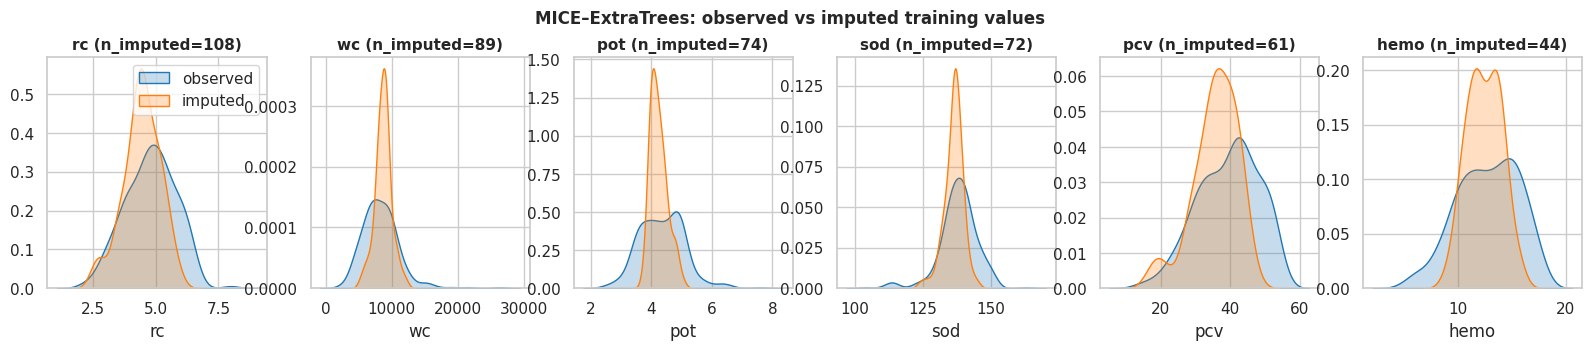

In [10]:
X_train_imp = prep.step2_impute(X_train_enc)
X_test_imp = prep.imputer_.transform(X_test_enc)
prep.X_train_imputed_ = X_train_imp
print("Iterations run:", prep.imputer_.imputer_.n_iter_)
imp_summary = pd.DataFrame({"missing in train (before)": X_train_enc.isna().sum(),
                            "missing in test (before)": X_test_enc.isna().sum(),
                            "missing in train (after)": X_train_imp.isna().sum(),
                            "missing in test (after)": X_test_imp.isna().sum()})
display(imp_summary[imp_summary.iloc[:, :2].sum(axis=1) > 0].sort_values("missing in train (before)", ascending=False).T)
assert X_train_imp.isna().sum().sum() == 0 and X_test_imp.isna().sum().sum() == 0

show_cols = [c for c in ["rc", "wc", "pot", "sod", "pcv", "hemo"] if c in X_train_imp.columns]
fig, axes = plt.subplots(1, len(show_cols), figsize=(3.3 * len(show_cols), 3))
for ax, c in zip(axes, show_cols):
    obs = X_train_enc[c].dropna()
    imp_vals = X_train_imp.loc[X_train_enc[c].isna(), c]
    sns.kdeplot(obs, ax=ax, label="observed", fill=True, color="tab:blue", warn_singular=False)
    if len(imp_vals) > 1:
        sns.kdeplot(imp_vals, ax=ax, label="imputed", fill=True, color="tab:orange", warn_singular=False)
    ax.set_title(f"{c} (n_imputed={len(imp_vals)})")
    ax.set_ylabel("")
axes[0].legend()
fig.suptitle("MICE–ExtraTrees: observed vs imputed training values", y=1.04, fontweight="bold")
save_fig(fig, "03_2_mice_observed_vs_imputed")

### 3.3 Step 3 — Isolation Forest for outlier / noise detection
Isolation Forest isolates observations with random splits; points isolated in few splits get high anomaly scores.
It is fitted on the (imputed) training features only. The `IF_CONTAMINATION` share of most anomalous **training rows** is removed from the
training data (noise filtering). **No feature/column is deleted**, and **no test row is ever removed** — test rows are only scored and flagged.

,flagged,flagged CKD,flagged Non-CKD,action
train,16,16,0,removed from training
test,7,7,0,kept (flag only)


Training rows after Isolation Forest: (304, 24) | columns unchanged: True


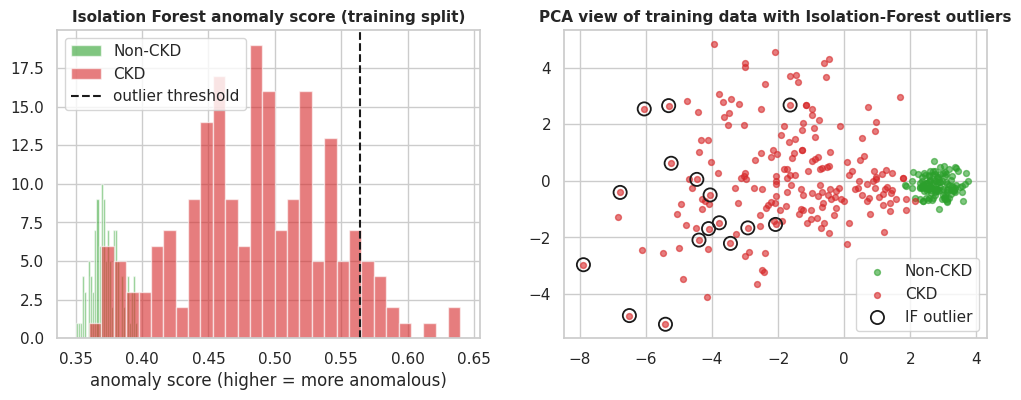

In [11]:
X_train_clean, y_train_clean = prep.step3_outliers(X_train_imp, y_train)
test_if_flags = prep.outlier_flags(X_test_imp)
if_tab = pd.DataFrame({
    "flagged": [int(prep.train_if_flags_.sum()), int(test_if_flags.sum())],
    "flagged CKD": [int(y_train[prep.train_if_flags_].sum()), int(y_test[test_if_flags].sum())],
    "flagged Non-CKD": [int((y_train[prep.train_if_flags_] == 0).sum()), int((y_test[test_if_flags] == 0).sum())],
    "action": ["removed from training" if IF_REMOVE_TRAIN_OUTLIERS else "kept (flag only)", "kept (flag only)"]},
    index=["train", "test"])
display(if_tab)
print("Training rows after Isolation Forest:", X_train_clean.shape, "| columns unchanged:",
      X_train_clean.shape[1] == X_train_imp.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc_ = prep.train_if_scores_
thr_ = sc_[prep.train_if_flags_].min() if prep.train_if_flags_.any() else sc_.max()
for cls, col in [(0, "tab:green"), (1, "tab:red")]:
    axes[0].hist(sc_[y_train == cls], bins=30, alpha=0.6, color=col, label=CLASS_NAMES[cls])
axes[0].axvline(thr_, color="k", ls="--", label="outlier threshold")
axes[0].set_title("Isolation Forest anomaly score (training split)")
axes[0].set_xlabel("anomaly score (higher = more anomalous)")
axes[0].legend()
Z = PCA(n_components=2, random_state=RANDOM_STATE).fit(
    (X_train_imp - X_train_imp.mean()) / X_train_imp.std().replace(0, 1))
P2 = Z.transform((X_train_imp - X_train_imp.mean()) / X_train_imp.std().replace(0, 1))
for cls, col in [(0, "tab:green"), (1, "tab:red")]:
    m = (y_train == cls).to_numpy()
    axes[1].scatter(P2[m, 0], P2[m, 1], s=18, alpha=0.6, color=col, label=CLASS_NAMES[cls])
f = prep.train_if_flags_.to_numpy()
axes[1].scatter(P2[f, 0], P2[f, 1], s=90, facecolors="none", edgecolors="k", linewidths=1.3, label="IF outlier")
axes[1].set_title("PCA view of training data with Isolation-Forest outliers")
axes[1].legend()
save_fig(fig, "03_3_isolation_forest")

### 3.4 Step 4 — Boruta–SHAP hybrid feature selection → final important features and feature-selected datasets

SHAP-Boruta iterations: 100 | Gini-Boruta iterations: 29


,SHAP-Boruta decision,SHAP hits,mean |SHAP|,Gini-Boruta decision,Gini hits,mean Gini,Hybrid selected
sg,Confirmed,100,0.09417,Confirmed,29,0.17127,True
hemo,Confirmed,100,0.08264,Confirmed,29,0.16201,True
sc,Confirmed,100,0.06451,Confirmed,29,0.11803,True
pcv,Confirmed,100,0.05576,Confirmed,29,0.12560,True
al,Confirmed,100,0.05446,Confirmed,29,0.09310,True
rbc,Confirmed,100,0.02307,Confirmed,29,0.03401,True
dm,Confirmed,100,0.02134,Confirmed,29,0.03207,True
rc,Confirmed,100,0.02126,Confirmed,29,0.05205,True
bgr,Confirmed,100,0.02064,Confirmed,29,0.03650,True
htn,Confirmed,100,0.01981,Confirmed,29,0.03310,True



FINAL IMPORTANT FEATURES (20/24): ['sg', 'hemo', 'sc', 'pcv', 'al', 'rbc', 'dm', 'rc', 'bgr', 'htn', 'sod', 'bu', 'su', 'bp', 'appet', 'pe', 'pc', 'pot', 'age', 'wc']
Dropped: ['pcc', 'ba', 'cad', 'ane']


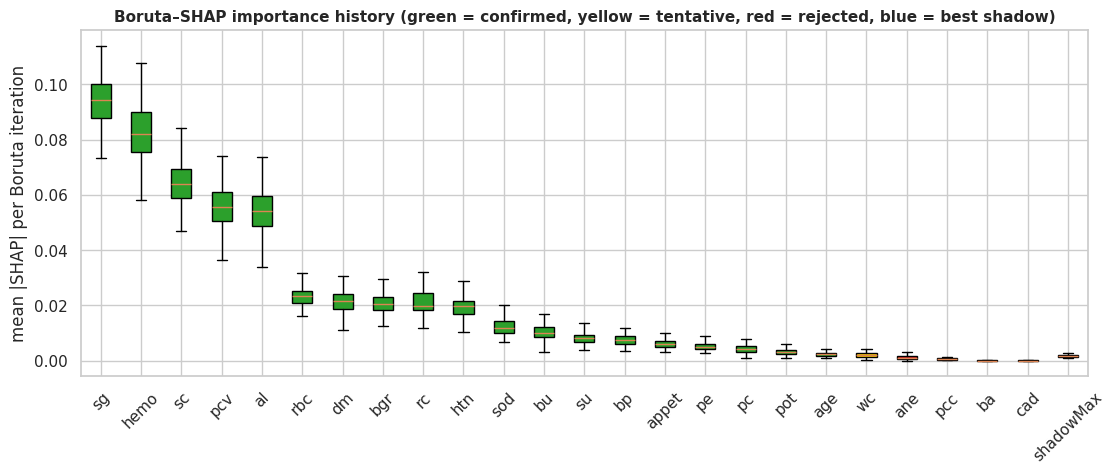

Feature-selected datasets saved: (304, 20) (80, 20)


In [12]:
X_train_sel = prep.step4_select(X_train_clean, y_train_clean)
prep.X_train_, prep.y_train_ = X_train_sel, y_train_clean
prep.fit_time_ = time.perf_counter() - _t0
SELECTED_FEATURES = list(prep.selected_features_)
X_test_sel = X_test_imp[SELECTED_FEATURES]
boruta_table = save_table(prep.selector_.table_, "03_4_boruta_shap_table")
print(f"SHAP-Boruta iterations: {prep.selector_.shap_['n_iter']} | Gini-Boruta iterations: {prep.selector_.gini_['n_iter']}")
display(boruta_table)
print(f"\nFINAL IMPORTANT FEATURES ({len(SELECTED_FEATURES)}/{len(FEATURES_ALL)}):", SELECTED_FEATURES)
print("Dropped:", [f for f in FEATURES_ALL if f not in SELECTED_FEATURES])

hist = prep.selector_.shap_["history"]
order = hist.median().sort_values(ascending=False).index
colors = {"Confirmed": "tab:green", "Tentative": "gold", "Rejected": "tab:red"}
dec = prep.selector_.shap_["decision"]
fig, ax = plt.subplots(figsize=(13, 4.5))
data = [hist[c].dropna().to_numpy() for c in order] + [prep.selector_.shap_["shadow_max"]]
bp = ax.boxplot(data, patch_artist=True, showfliers=False)
for patch, name in zip(bp["boxes"], list(order) + ["shadowMax"]):
    patch.set_facecolor(colors.get(dec.get(name, ""), "tab:blue"))
ax.set_xticks(range(1, len(order) + 2))
ax.set_xticklabels(list(order) + ["shadowMax"], rotation=45)
ax.set_ylabel("mean |SHAP| per Boruta iteration")
ax.set_title("Boruta–SHAP importance history (green = confirmed, yellow = tentative, red = rejected, blue = best shadow)")
save_fig(fig, "03_4_boruta_shap_importance")

# Feature-selected datasets
X_train_sel.assign(ckd=y_train_clean).to_csv(OUT_DIR / "train_feature_selected.csv")
X_test_sel.assign(ckd=y_test).to_csv(OUT_DIR / "test_feature_selected.csv")
print("Feature-selected datasets saved:", X_train_sel.shape, X_test_sel.shape)

### 3.5 Leakage audit (programmatic checks)

In [13]:
checks = {
    "`id` absent from all predictor sets": "id" not in FEATURES_ALL and "id" not in SELECTED_FEATURES,
    "preprocessor fitted on training rows only": set(prep.fit_index_) == set(X_train_raw.index),
    "no test row used to fit any step": set(prep.fit_index_).isdisjoint(X_test_raw.index),
    "Isolation Forest removed no test rows": len(X_test_sel) == len(X_test_raw),
    "Isolation Forest deleted no features": X_train_clean.shape[1] == len(FEATURES_ALL),
    "test set has no missing values after imputation": int(X_test_sel.isna().sum().sum()) == 0,
}
display(pd.DataFrame({"check": list(checks), "passed": list(checks.values())}))
assert all(checks.values())

,check,passed
0,`id` absent from all predictor sets,True
1,preprocessor fitted on training rows only,True
2,no test row used to fit any step,True
3,Isolation Forest removed no test rows,True
4,Isolation Forest deleted no features,True
5,test set has no missing values after imputation,True


## 4. Model zoo — 8 individual learners and 3 ensembles
### 4.1 TabPFN wrapper and availability check
TabPFN is a pretrained transformer for small tabular data. The open **TabPFN-v2** checkpoint is used (it does not require a gated
licence token). If the weights cannot be downloaded (Internet off), TabPFN is excluded **and the notebook says so explicitly**;
no other model is silently substituted for it.

In [14]:
try:
    import torch
    TABPFN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    TABPFN_DEVICE = "cpu"


def build_tabpfn(**kwargs):
    from tabpfn import TabPFNClassifier
    try:
        from tabpfn.constants import ModelVersion
        return TabPFNClassifier.create_default_for_version(ModelVersion.V2, **kwargs)
    except (ImportError, AttributeError):
        return TabPFNClassifier(**kwargs)


class TabPFNModel(BaseEstimator, ClassifierMixin):
    """Thin sklearn wrapper so TabPFN can be tuned, cloned and ensembled like every other model."""

    def __init__(self, n_estimators=None, softmax_temperature=None, random_state=0, device="cpu"):
        self.n_estimators = n_estimators
        self.softmax_temperature = softmax_temperature
        self.random_state = random_state
        self.device = device

    def fit(self, X, y):
        kw = {"device": self.device, "random_state": self.random_state}
        if self.n_estimators is not None:
            kw["n_estimators"] = self.n_estimators
        if self.softmax_temperature is not None:
            kw["softmax_temperature"] = self.softmax_temperature
        self.model_ = build_tabpfn(**kw)
        self.model_.fit(np.asarray(X, dtype=np.float32), np.asarray(y).astype(int))
        self.classes_ = np.asarray(self.model_.classes_)
        return self

    def predict_proba(self, X):
        return np.asarray(self.model_.predict_proba(np.asarray(X, dtype=np.float32)))

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


TABPFN_AVAILABLE, TABPFN_STATUS = False, "tabpfn package not importable"
if TABPFN_IMPORTABLE:
    try:
        _rs = np.random.default_rng(0)
        _Xs = _rs.normal(size=(60, 4))
        _ys = (_Xs[:, 0] + _rs.normal(scale=0.5, size=60) > 0).astype(int)
        TabPFNModel(n_estimators=1, device=TABPFN_DEVICE).fit(_Xs, _ys).predict_proba(_Xs[:5])
        TABPFN_AVAILABLE, TABPFN_STATUS = True, f"ready on {TABPFN_DEVICE}"
    except Exception as e:                                  # e.g. no Internet to download weights
        TABPFN_STATUS = f"{type(e).__name__}: {str(e)[:400]}"
print("TabPFN:", "AVAILABLE" if TABPFN_AVAILABLE else "NOT AVAILABLE", "|", TABPFN_STATUS)
if not TABPFN_AVAILABLE:
    display(Markdown("> **TabPFN could not be loaded in this session**, so it is excluded from all tables and ensembles below. "
                     "Enable *Internet* in the Kaggle notebook settings (and optionally a GPU) and re-run to include it."))

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN: AVAILABLE | ready on cuda


### 4.2 Model factory, default settings and hyperparameter grids
*Default* models use each library's default hyperparameters (only seeds/verbosity/threads are fixed). *Grids* are compact on purpose:
with n ≈ 320 training patients, large grids overfit the inner CV more than they help.

In [15]:
BASE_MODELS = ["XGBoost", "CatBoost", "LightGBM", "Random Forest", "Extra Trees", "HistGradientBoosting", "EBM", "TabPFN"]
ENSEMBLE_MODELS = ["Stacking Ensemble", "Soft Voting Ensemble", "Weighted Voting Ensemble"]
ACTIVE_BASE_MODELS = [m for m in BASE_MODELS if m != "TabPFN" or TABPFN_AVAILABLE]
ALL_MODELS = ACTIVE_BASE_MODELS + ENSEMBLE_MODELS
DEFAULT_PARAMS = {m: {} for m in BASE_MODELS}

PARAM_GRIDS = {
    "XGBoost": {"n_estimators": [100, 300], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]},
    "CatBoost": {"iterations": [300], "depth": [4, 6], "learning_rate": [0.03, 0.1], "l2_leaf_reg": [1, 3]},
    "LightGBM": {"n_estimators": [100, 300], "num_leaves": [7, 15], "learning_rate": [0.05, 0.1]},
    "Random Forest": {"n_estimators": [300], "max_depth": [None, 8], "max_features": ["sqrt", 0.5],
                      "min_samples_leaf": [1, 2]},
    "Extra Trees": {"n_estimators": [300], "max_depth": [None, 8], "max_features": ["sqrt", 0.5],
                    "min_samples_leaf": [1, 2]},
    "HistGradientBoosting": {"learning_rate": [0.05, 0.1], "max_depth": [3, None], "max_leaf_nodes": [15, 31]},
    "EBM": {"outer_bags": [8], "learning_rate": [0.015, 0.05], "interactions": [0, 3]},
    "TabPFN": {"n_estimators": [4, 8]},
}
if FAST_MODE:
    PARAM_GRIDS = {m: {k: v[:1] for k, v in g.items()} for m, g in PARAM_GRIDS.items()}
    PARAM_GRIDS["EBM"]["interactions"] = [0]
    DEFAULT_PARAMS["EBM"] = {"outer_bags": 4, "interactions": 0}


def make_model(name, params=None, seed=RANDOM_STATE):
    p = dict(params or {})
    if name == "XGBoost":
        return XGBClassifier(**{"random_state": seed, "n_jobs": N_JOBS, "verbosity": 0, "eval_metric": "logloss", **p})
    if name == "CatBoost":
        return CatBoostClassifier(**{"random_seed": seed, "verbose": 0, "thread_count": N_JOBS,
                                     "allow_writing_files": False, **p})
    if name == "LightGBM":
        return LGBMClassifier(**{"random_state": seed, "n_jobs": N_JOBS, "verbose": -1, **p})
    if name == "Random Forest":
        return RandomForestClassifier(**{"random_state": seed, "n_jobs": N_JOBS, **p})
    if name == "Extra Trees":
        return ExtraTreesClassifier(**{"random_state": seed, "n_jobs": N_JOBS, **p})
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(**{"random_state": seed, **p})
    if name == "EBM":
        return ExplainableBoostingClassifier(**{"random_state": seed, **p})
    if name == "TabPFN":
        return TabPFNModel(**{"random_state": seed, "device": TABPFN_DEVICE, **p})
    raise ValueError(name)


display(pd.DataFrame([{"model": m, "grid": json.dumps(PARAM_GRIDS[m]), "configurations": len(ParameterGrid(PARAM_GRIDS[m]))}
                      for m in ACTIVE_BASE_MODELS]).set_index("model"))

,grid,configurations
model,,
XGBoost,"{""n_estimators"": [100, 300], ""max_depth"": [3, ...",8
CatBoost,"{""iterations"": [300], ""depth"": [4, 6], ""learni...",8
LightGBM,"{""n_estimators"": [100, 300], ""num_leaves"": [7,...",8
Random Forest,"{""n_estimators"": [300], ""max_depth"": [null, 8]...",8
Extra Trees,"{""n_estimators"": [300], ""max_depth"": [null, 8]...",8
HistGradientBoosting,"{""learning_rate"": [0.05, 0.1], ""max_depth"": [3...",8
EBM,"{""outer_bags"": [8], ""learning_rate"": [0.015, 0...",4
TabPFN,"{""n_estimators"": [4, 8]}",2


### 4.3 Ensembles, metrics, and the shared training routine
* **Soft voting** — unweighted mean of the base models' CKD probabilities.
* **Weighted voting** — weights ∝ 1 / (inner-CV log-loss) of each base model, so better-calibrated, more accurate members count more.
  Log-loss is used instead of AUC because inner-CV AUCs on this dataset are all close to 1 and would give nearly equal weights.
* **Stacking** — a cross-validated logistic-regression meta-learner (`LogisticRegressionCV`) trained on the **out-of-fold** base-model
  probabilities from the inner CV (never on in-sample predictions).

All three reuse base models already fitted on the same training data, so no extra information enters.

In [16]:
class ProbAverageEnsemble(BaseEstimator, ClassifierMixin):
    """Soft (equal weights) or weighted voting over already-fitted base models."""

    def __init__(self, base_models=None, weights=None):
        self.base_models = base_models
        self.weights = weights

    def fit(self, X=None, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        names = list(self.base_models)
        w = np.array([self.weights[n] for n in names], float)
        w = w / w.sum()
        p = np.zeros(len(X))
        for wi, n in zip(w, names):
            p += wi * self.base_models[n].predict_proba(X)[:, 1]
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= DECISION_THRESHOLD).astype(int)

    def __repr__(self):
        return f"ProbAverageEnsemble({len(self.base_models)} members)"


class StackingEnsemble(BaseEstimator, ClassifierMixin):
    """Stacking: base-model CKD probabilities -> logistic-regression meta-learner."""

    def __init__(self, base_models=None, meta_model=None):
        self.base_models = base_models
        self.meta_model = meta_model

    def fit(self, X=None, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def meta_features(self, X):
        return np.column_stack([m.predict_proba(X)[:, 1] for m in self.base_models.values()])

    def predict_proba(self, X):
        return self.meta_model.predict_proba(self.meta_features(X))

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= DECISION_THRESHOLD).astype(int)

    def __repr__(self):
        return f"StackingEnsemble({len(self.base_models)} members + logistic meta-learner)"


def build_ensembles(fitted, oof, y, seed=RANDOM_STATE):
    names = list(fitted)
    y = np.asarray(y).astype(int)
    t0 = time.perf_counter()
    lls = {n: log_loss(y, np.clip(oof[n], 1e-6, 1 - 1e-6)) for n in names}
    inv = {n: 1.0 / max(lls[n], 1e-6) for n in names}
    weights = {n: inv[n] / sum(inv.values()) for n in names}
    t_w = time.perf_counter() - t0
    t0 = time.perf_counter()
    Z = np.column_stack([oof[n] for n in names])
    meta = LogisticRegressionCV(Cs=np.logspace(-3, 3, 13), cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                                scoring="neg_log_loss", max_iter=5000).fit(Z, y)
    t_meta = time.perf_counter() - t0
    ensembles = {"Stacking Ensemble": StackingEnsemble(dict(fitted), meta).fit(),
                 "Soft Voting Ensemble": ProbAverageEnsemble(dict(fitted), {n: 1.0 for n in names}).fit(),
                 "Weighted Voting Ensemble": ProbAverageEnsemble(dict(fitted), weights).fit()}
    info = {"weights": weights, "inner_logloss": lls, "meta_coef": dict(zip(names, meta.coef_.ravel())),
            "meta_intercept": float(meta.intercept_[0]), "meta_C": float(np.ravel(meta.C_)[0]),
            "extra_fit_time": {"Stacking Ensemble": t_meta, "Soft Voting Ensemble": 0.0, "Weighted Voting Ensemble": t_w}}
    return ensembles, info


METRICS = ["Accuracy", "Precision", "Recall (TPR)", "F1-score", "FPR", "FNR", "TNR", "AUC", "Kappa", "Brier", "Cost"]
CORE8 = ["Accuracy", "Precision", "Recall (TPR)", "F1-score", "FPR", "FNR", "TNR", "AUC"]
HIGHER_BETTER = {"Accuracy": True, "Precision": True, "Recall (TPR)": True, "F1-score": True, "FPR": False,
                 "FNR": False, "TNR": True, "AUC": True, "Kappa": True, "Brier": False, "Cost": False}


def cost_per_patient(tp, tn, fp, fn):
    n = tp + tn + fp + fn
    return (COST_CORRECT * (tp + tn) + COST_FALSE * (fp + fn)) / n if n else np.nan


def compute_metrics(y_true, p, thr=DECISION_THRESHOLD):
    y_true = np.asarray(y_true).astype(int)
    p = np.clip(np.asarray(p, float), 0, 1)
    y_pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    div = lambda a, b: a / b if b > 0 else 0.0
    prec, rec = div(tp, tp + fp), div(tp, tp + fn)
    both = len(np.unique(y_true)) == 2
    kappa = cohen_kappa_score(y_true, y_pred) if (both or len(np.unique(y_pred)) == 2) else np.nan
    return {"Accuracy": div(tp + tn, tp + tn + fp + fn), "Precision": prec, "Recall (TPR)": rec,
            "F1-score": div(2 * prec * rec, prec + rec), "FPR": div(fp, fp + tn), "FNR": div(fn, fn + tp),
            "TNR": div(tn, tn + fp), "AUC": roc_auc_score(y_true, p) if both else np.nan,
            "Kappa": kappa, "Brier": brier_score_loss(y_true, p), "Cost": cost_per_patient(tp, tn, fp, fn),
            "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)}


def cv_oof_proba(name, params, X, y, folds, seed):
    oof = np.zeros(len(y))
    for tr, va in folds:
        m = make_model(name, params, seed).fit(X.iloc[tr], y[tr])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    return oof


def search_params(name, X, y, grid, seed=RANDOM_STATE, n_splits=INNER_CV_FOLDS):
    """Exhaustive grid search with stratified inner CV. Selection: highest pooled out-of-fold AUC,
    ties (to 4 decimals) broken by the lowest out-of-fold log-loss. Returns the best params and their OOF probabilities."""
    y = np.asarray(y).astype(int)
    folds = list(StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, y))
    rows, oofs = [], []
    t0 = time.perf_counter()
    for params in grid:
        oof = cv_oof_proba(name, params, X, y, folds, seed)
        rows.append({"params": json.dumps(params, default=str), "inner-CV AUC": roc_auc_score(y, oof),
                     "inner-CV log-loss": log_loss(y, np.clip(oof, 1e-6, 1 - 1e-6)),
                     "inner-CV accuracy": accuracy_score(y, (oof >= DECISION_THRESHOLD).astype(int))})
        oofs.append(oof)
    best = sorted(range(len(rows)), key=lambda i: (-round(rows[i]["inner-CV AUC"], 4), rows[i]["inner-CV log-loss"]))[0]
    table = pd.DataFrame(rows)
    table["selected"] = False
    table.loc[best, "selected"] = True
    return grid[best], oofs[best], table, time.perf_counter() - t0


def train_models(X_tr, y_tr, X_te, seed=RANDOM_STATE, tune=True, n_splits=INNER_CV_FOLDS, verbose=True):
    """Fit all individual models (default params or grid-searched) + the 3 ensembles on (X_tr, y_tr)
    and return test probabilities, fitted models, selected params and timing information."""
    y_tr = np.asarray(y_tr).astype(int)
    run = {k: {} for k in ["models", "proba", "best_params", "grid_tables", "oof", "search_time",
                           "fit_time", "pred_time_ms", "n_configs"]}
    for name in ACTIVE_BASE_MODELS:
        grid = list(ParameterGrid(PARAM_GRIDS[name])) if tune else [DEFAULT_PARAMS[name]]
        best, oof, table, t_search = search_params(name, X_tr, y_tr, grid, seed, n_splits)
        t0 = time.perf_counter()
        model = make_model(name, best, seed).fit(X_tr, y_tr)
        t_fit = time.perf_counter() - t0
        t0 = time.perf_counter()
        p = model.predict_proba(X_te)[:, 1]
        t_pred = time.perf_counter() - t0
        run["models"][name], run["proba"][name], run["best_params"][name] = model, p, best
        run["grid_tables"][name], run["oof"][name] = table, oof
        run["search_time"][name], run["fit_time"][name] = t_search, t_fit
        run["pred_time_ms"][name], run["n_configs"][name] = 1000 * t_pred / len(X_te), len(grid)
        if verbose:
            print(f"   {name:<22} configs={len(grid):>2} | search/CV {t_search:6.1f}s | final fit {t_fit:6.2f}s | "
                  f"inner-CV AUC {table.loc[table.selected, 'inner-CV AUC'].iloc[0]:.4f}")
    ens, info = build_ensembles(run["models"], run["oof"], y_tr, seed)
    for name, model in ens.items():
        t0 = time.perf_counter()
        p = model.predict_proba(X_te)[:, 1]
        t_pred = time.perf_counter() - t0
        run["models"][name], run["proba"][name] = model, p
        run["search_time"][name] = sum(run["search_time"][b] for b in ACTIVE_BASE_MODELS)
        run["fit_time"][name] = sum(run["fit_time"][b] for b in ACTIVE_BASE_MODELS) + info["extra_fit_time"][name]
        run["pred_time_ms"][name] = 1000 * t_pred / len(X_te)
        run["n_configs"][name] = sum(run["n_configs"][b] for b in ACTIVE_BASE_MODELS)
    run["ensemble_info"] = info
    return run


def metrics_frame(proba_dict, y_true, models=None):
    models = models or list(proba_dict)
    return pd.DataFrame({m: compute_metrics(y_true, proba_dict[m]) for m in models}).T


def mark_best(df, cols=CORE8):
    """Return a copy with the best value per column marked by a trailing '*' (for printing)."""
    out = df.copy().astype(object)
    for c in cols:
        if c in df.columns:
            best = df[c].max() if HIGHER_BETTER[c] else df[c].min()
            out[c] = [f"{v:.4f}*" if np.isclose(v, best) else f"{v:.4f}" for v in df[c]]
    return out

## 5. Stage A — Train all models with default hyperparameters (hold-out test evaluation)
Models are trained on the feature-selected, IF-cleaned training data and evaluated once on the sealed test set (n = 80).
(`*` marks the best value in each column; FPR/FNR are lower-is-better.)

Training 11 models with DEFAULT hyperparameters on (304, 20) ...
   XGBoost                configs= 1 | search/CV    0.2s | final fit   0.03s | inner-CV AUC 0.9978
   CatBoost               configs= 1 | search/CV    6.2s | final fit   1.29s | inner-CV AUC 1.0000
   LightGBM               configs= 1 | search/CV    0.2s | final fit   0.04s | inner-CV AUC 0.9933
   Random Forest          configs= 1 | search/CV    1.1s | final fit   0.19s | inner-CV AUC 1.0000
   Extra Trees            configs= 1 | search/CV    0.9s | final fit   0.15s | inner-CV AUC 1.0000
   HistGradientBoosting   configs= 1 | search/CV    0.5s | final fit   0.13s | inner-CV AUC 0.9971
   EBM                    configs= 1 | search/CV  754.1s | final fit  22.56s | inner-CV AUC 1.0000
   TabPFN                 configs= 1 | search/CV    2.3s | final fit   0.20s | inner-CV AUC 1.0000
Stage A finished in 791.7s


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC,Kappa,Brier
XGBoost,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000136
CatBoost,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000162
LightGBM,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
Random Forest,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.00046
Extra Trees,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000431
HistGradientBoosting,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000001
EBM,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
TabPFN,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000001
Stacking Ensemble,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
Soft Voting Ensemble,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000049


,XGBoost,CatBoost,LightGBM,Random Forest,Extra Trees,HistGradientBoosting,EBM,TabPFN,Stacking Ensemble,Soft Voting Ensemble,Weighted Voting Ensemble
TP,50,50,50,50,50,50,50,50,50,50,50
FN,0,0,0,0,0,0,0,0,0,0,0
FP,0,0,0,0,0,0,0,0,0,0,0
TN,30,30,30,30,30,30,30,30,30,30,30


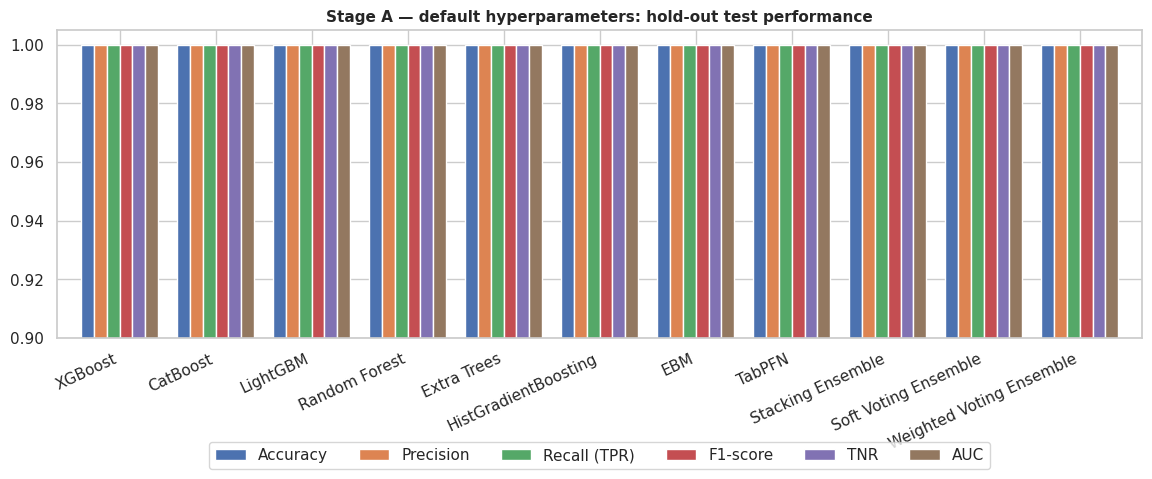

In [17]:
print(f"Training {len(ALL_MODELS)} models with DEFAULT hyperparameters on {X_train_sel.shape} ...")
t_stage = time.time()
default_run = train_models(X_train_sel, y_train_clean, X_test_sel, seed=RANDOM_STATE, tune=False)
print(f"Stage A finished in {time.time() - t_stage:.1f}s")
holdout_default = save_table(metrics_frame(default_run["proba"], y_test, ALL_MODELS), "05_holdout_default_metrics")
display(mark_best(holdout_default[CORE8 + ["Kappa", "Brier"]]))
display(holdout_default[["TP", "FN", "FP", "TN"]].astype(int).T)

fig, ax = plt.subplots(figsize=(14, 4))
holdout_default[["Accuracy", "Precision", "Recall (TPR)", "F1-score", "TNR", "AUC"]].plot.bar(ax=ax, width=0.8)
ax.set_ylim(max(0.0, holdout_default[["Accuracy", "TNR"]].min().min() - 0.1), 1.005)
ax.set_title("Stage A — default hyperparameters: hold-out test performance")
ax.legend(ncol=6, loc="lower center", bbox_to_anchor=(0.5, -0.45))
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
save_fig(fig, "05_holdout_default_bar")

## 6. Stage B — Hyperparameter optimisation (grid search) and training with optimised parameters
For every model, all grid configurations are scored by stratified `INNER_CV_FOLDS`-fold CV **inside the training split**.
The configuration with the best inner-CV AUC (ties → lower log-loss) is refitted on the whole training split and then evaluated
once on the untouched test set.

In [18]:
print(f"Grid search ({INNER_CV_FOLDS}-fold inner CV) for {len(ACTIVE_BASE_MODELS)} individual models ...")
t_stage = time.time()
tuned_run = train_models(X_train_sel, y_train_clean, X_test_sel, seed=RANDOM_STATE, tune=True)
print(f"Stage B finished in {time.time() - t_stage:.1f}s")

best_params_table = pd.DataFrame([{"model": m, "best hyperparameters": json.dumps(tuned_run["best_params"][m], default=str),
                                   "configs searched": tuned_run["n_configs"][m],
                                   "inner-CV AUC": tuned_run["grid_tables"][m].loc[tuned_run["grid_tables"][m].selected, "inner-CV AUC"].iloc[0],
                                   "inner-CV log-loss": tuned_run["grid_tables"][m].loc[tuned_run["grid_tables"][m].selected, "inner-CV log-loss"].iloc[0],
                                   "search time (s)": round(tuned_run["search_time"][m], 1)}
                                  for m in ACTIVE_BASE_MODELS]).set_index("model")
save_table(best_params_table, "06_best_hyperparameters")
print("Selected (best) hyperparameters:")
display(best_params_table)
pd.concat({m: t for m, t in tuned_run["grid_tables"].items()}).to_csv(TAB_DIR / "06_full_grid_search_results.csv")

info = tuned_run["ensemble_info"]
ens_tab = pd.DataFrame({"inner-CV log-loss": info["inner_logloss"], "weighted-voting weight": info["weights"],
                        "stacking meta coefficient": info["meta_coef"]}).round(4)
print(f"Stacking meta-learner: logistic regression, C = {info['meta_C']:.4g}, intercept = {info['meta_intercept']:.3f}")
display(save_table(ens_tab, "06_ensemble_weights"))

holdout_tuned = save_table(metrics_frame(tuned_run["proba"], y_test, ALL_MODELS), "06_holdout_tuned_metrics")
print("Optimised models — hold-out test performance:")
display(mark_best(holdout_tuned[CORE8 + ["Kappa", "Brier"]]))
display(holdout_tuned[["TP", "FN", "FP", "TN"]].astype(int).T)

delta = (holdout_tuned[["Accuracy", "F1-score", "AUC", "Brier"]] - holdout_default[["Accuracy", "F1-score", "AUC", "Brier"]])
delta.columns = [f"Δ {c} (tuned − default)" for c in delta.columns]
display(save_table(delta.round(4), "06_default_vs_tuned_delta"))

Grid search (5-fold inner CV) for 8 individual models ...
   XGBoost                configs= 8 | search/CV    2.2s | final fit   0.08s | inner-CV AUC 0.9981
   CatBoost               configs= 8 | search/CV   12.1s | final fit   0.39s | inner-CV AUC 1.0000
   LightGBM               configs= 8 | search/CV    1.8s | final fit   0.04s | inner-CV AUC 0.9981
   Random Forest          configs= 8 | search/CV   25.2s | final fit   0.57s | inner-CV AUC 1.0000
   Extra Trees            configs= 8 | search/CV   19.0s | final fit   0.41s | inner-CV AUC 1.0000
   HistGradientBoosting   configs= 8 | search/CV    3.5s | final fit   0.12s | inner-CV AUC 0.9971
   EBM                    configs= 4 | search/CV   46.3s | final fit   1.77s | inner-CV AUC 1.0000
   TabPFN                 configs= 2 | search/CV    3.6s | final fit   0.18s | inner-CV AUC 1.0000
Stage B finished in 119.1s
Selected (best) hyperparameters:


,best hyperparameters,configs searched,inner-CV AUC,inner-CV log-loss,search time (s)
model,,,,,
XGBoost,"{""learning_rate"": 0.1, ""max_depth"": 6, ""n_esti...",8,0.998098,0.047796,2.2
CatBoost,"{""depth"": 6, ""iterations"": 300, ""l2_leaf_reg"":...",8,0.999955,0.037757,12.1
LightGBM,"{""learning_rate"": 0.1, ""n_estimators"": 300, ""n...",8,0.998053,0.076388,1.8
Random Forest,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m...",8,1.000000,0.037467,25.2
Extra Trees,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",8,1.000000,0.021354,19.0
HistGradientBoosting,"{""learning_rate"": 0.1, ""max_depth"": null, ""max...",8,0.997101,0.059616,3.5
EBM,"{""interactions"": 0, ""learning_rate"": 0.05, ""ou...",4,1.000000,0.008459,46.3
TabPFN,"{""n_estimators"": 8}",2,1.000000,0.004961,3.6


Stacking meta-learner: logistic regression, C = 316.2, intercept = -8.471


,inner-CV log-loss,weighted-voting weight,stacking meta coefficient
XGBoost,0.0478,0.0445,1.4497
CatBoost,0.0378,0.0563,1.3784
LightGBM,0.0764,0.0278,1.8316
Random Forest,0.0375,0.0567,2.8361
Extra Trees,0.0214,0.0995,3.3432
HistGradientBoosting,0.0596,0.0356,2.3722
EBM,0.0085,0.2512,5.0265
TabPFN,0.0050,0.4283,4.5448


Optimised models — hold-out test performance:


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC,Kappa,Brier
XGBoost,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000206
CatBoost,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000035
LightGBM,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
Random Forest,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000452
Extra Trees,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000072
HistGradientBoosting,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000001
EBM,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
TabPFN,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000001
Stacking Ensemble,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.0
Soft Voting Ensemble,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000028


,XGBoost,CatBoost,LightGBM,Random Forest,Extra Trees,HistGradientBoosting,EBM,TabPFN,Stacking Ensemble,Soft Voting Ensemble,Weighted Voting Ensemble
TP,50,50,50,50,50,50,50,50,50,50,50
FN,0,0,0,0,0,0,0,0,0,0,0
FP,0,0,0,0,0,0,0,0,0,0,0
TN,30,30,30,30,30,30,30,30,30,30,30


,Δ Accuracy (tuned − default),Δ F1-score (tuned − default),Δ AUC (tuned − default),Δ Brier (tuned − default)
XGBoost,0.0,0.0,0.0,0.0001
CatBoost,0.0,0.0,0.0,-0.0001
LightGBM,0.0,0.0,0.0,-0.0000
Random Forest,0.0,0.0,0.0,-0.0000
Extra Trees,0.0,0.0,0.0,-0.0004
HistGradientBoosting,0.0,0.0,0.0,0.0000
EBM,0.0,0.0,0.0,0.0000
TabPFN,0.0,0.0,0.0,0.0000
Stacking Ensemble,0.0,0.0,0.0,-0.0000
Soft Voting Ensemble,0.0,0.0,0.0,-0.0000


## 7. Stage C — 10-fold cross-validation (model validation)
```
Dataset (n = 400, `id` removed, deterministic cleaning only)
   ↓
Split into 10 stratified folds
   ↓
Train: 9 folds  →  LabelEncoder → MICE-ExtraTrees → Isolation Forest → Boruta-SHAP → grid search → optimised models + ensembles
Test : 1 fold   →  transformed with the steps fitted on the 9 training folds, then predicted
   ↓
Repeat 10 times (every patient is tested exactly once)
   ↓
Average performance (mean ± SD over folds) + pooled out-of-fold predictions for the plots
```
Every step that learns from data — including hyperparameter selection — is **re-fitted inside each training portion**
(nested, leakage-free CV). This is stricter than tuning once and re-using the parameters, which would let the tuning data leak into
80% of the CV test folds.

In [19]:
outer_cv = StratifiedKFold(OUTER_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
N_ALL = len(y_all)
y_all_np = y_all.to_numpy()
cv_oof = {m: np.full(N_ALL, np.nan) for m in ALL_MODELS}
cv_fold_of = np.full(N_ALL, -1)
cv_rows, cv_time_rows, cv_folds = [], [], []
t_stage = time.time()
print(f"Running leakage-free {OUTER_CV_FOLDS}-fold CV (full pipeline re-fitted per fold) ...")
for k, (tr, te) in enumerate(outer_cv.split(X_all_raw, y_all_np), start=1):
    t_fold = time.time()
    fold_seed = RANDOM_STATE + k
    p_k = CKDPreprocessor(random_state=fold_seed).fit(X_all_raw.iloc[tr], y_all.iloc[tr])
    X_te_k = p_k.transform(X_all_raw.iloc[te])
    run_k = train_models(p_k.X_train_, p_k.y_train_, X_te_k, seed=fold_seed, tune=True, verbose=False)
    y_te_k = y_all_np[te]
    for m in ALL_MODELS:
        cv_oof[m][te] = run_k["proba"][m]
        cv_rows.append({"fold": k, "model": m, **compute_metrics(y_te_k, run_k["proba"][m])})
        cv_time_rows.append({"fold": k, "model": m, "preprocessing (s)": p_k.fit_time_,
                             "grid search / inner CV (s)": run_k["search_time"][m],
                             "final training (s)": run_k["fit_time"][m],
                             "inference (ms/patient)": run_k["pred_time_ms"][m],
                             "configs searched": run_k["n_configs"][m]})
    cv_fold_of[te] = k
    cv_folds.append({"fold": k, "train_idx": tr, "test_idx": te, "prep": p_k, "seed": fold_seed,
                     "best_params": run_k["best_params"], "selected": list(p_k.selected_features_),
                     "if_removed": int(p_k.train_if_flags_.sum()),
                     "if_removed_ckd": int(y_all.iloc[tr][p_k.train_if_flags_.to_numpy()].sum())})
    best_now = max(ALL_MODELS, key=lambda m: roc_auc_score(y_te_k, run_k["proba"][m]))
    print(f"  fold {k:>2}/{OUTER_CV_FOLDS} | train {len(tr)} (IF removed {cv_folds[-1]['if_removed']}) | test {len(te)} | "
          f"{len(p_k.selected_features_):>2} features | fold time {time.time() - t_fold:5.0f}s")
    del run_k
    gc.collect()
assert (cv_fold_of > 0).all() and all(~np.isnan(v).any() for v in cv_oof.values())
print(f"{OUTER_CV_FOLDS}-fold CV finished in {(time.time() - t_stage) / 60:.1f} min")

cv_df = save_table(pd.DataFrame(cv_rows), "07_cv_per_fold_metrics", index=False)
cv_time_df = save_table(pd.DataFrame(cv_time_rows), "07_cv_per_fold_timing", index=False)

Running leakage-free 10-fold CV (full pipeline re-fitted per fold) ...
  fold  1/10 | train 360 (IF removed 18) | test 40 | 19 features | fold time   215s
  fold  2/10 | train 360 (IF removed 18) | test 40 | 20 features | fold time   210s
  fold  3/10 | train 360 (IF removed 18) | test 40 | 20 features | fold time   235s
  fold  4/10 | train 360 (IF removed 18) | test 40 | 19 features | fold time   209s
  fold  5/10 | train 360 (IF removed 18) | test 40 | 20 features | fold time   292s
  fold  6/10 | train 360 (IF removed 18) | test 40 | 19 features | fold time   212s
  fold  7/10 | train 360 (IF removed 18) | test 40 | 19 features | fold time   225s
  fold  8/10 | train 360 (IF removed 18) | test 40 | 20 features | fold time   207s
  fold  9/10 | train 360 (IF removed 18) | test 40 | 19 features | fold time   203s
  fold 10/10 | train 360 (IF removed 18) | test 40 | 20 features | fold time   212s
10-fold CV finished in 37.0 min


### 7.1 Performance metrics — definitions
With CKD as the positive class and the confusion-matrix counts TP, TN, FP, FN:

1. **Accuracy** $=\dfrac{TP+TN}{TP+TN+FP+FN}$ — overall correct predictions.
2. **Precision** $=\dfrac{TP}{TP+FP}$ — how many predicted CKD cases were actually CKD.
3. **Recall / True Positive Rate (TPR)** $=\dfrac{TP}{TP+FN}$ — clinically critical, because missed CKD patients (false negatives) are dangerous.
4. **F1-score** $=2\times\dfrac{Precision\times Recall}{Precision+Recall}$ — balances precision and recall.
5. **False Positive Rate (FPR)** $=\dfrac{FP}{FP+TN}$ — healthy patients incorrectly classified as CKD.
6. **False Negative Rate (FNR)** $=\dfrac{FN}{FN+TP}$ — missed CKD patients.
7. **True Negative Rate (TNR)** $=\dfrac{TN}{TN+FP}$ — correct identification of non-CKD patients.
8. **AUC** — area under the ROC curve; the model's ability to separate CKD from non-CKD across all thresholds.
9. **Cohen's Kappa** $\kappa=\dfrac{p_o-p_e}{1-p_e}$ — agreement beyond chance ($p_o$ observed accuracy, $p_e$ chance agreement);
   **Brier score** $=\frac{1}{N}\sum_i (\hat p_i-y_i)^2$ — mean squared error of the predicted CKD probability (lower is better; measures calibration + sharpness).
10. **Computational cost** — preprocessing, grid-search, final-training and inference time, and model size (Section 7.3).

*Cost* (average misclassification cost per patient under the 5 : 1 cost matrix) is also reported; it is analysed in Section 11.

### 7.2 10-fold CV results for every model (mean ± SD over the 10 folds)

In [20]:
cv_mean = cv_df.groupby("model")[METRICS].mean().loc[ALL_MODELS]
cv_std = cv_df.groupby("model")[METRICS].std(ddof=1).loc[ALL_MODELS]
cv_pm = pd.DataFrame({c: [f"{cv_mean.at[m, c]:.4f} ± {cv_std.at[m, c]:.4f}" for m in ALL_MODELS] for c in METRICS},
                     index=ALL_MODELS)
save_table(cv_mean, "07_cv_mean")
save_table(cv_std, "07_cv_std")
save_table(cv_pm, "07_cv_mean_pm_std")
display(cv_pm[CORE8])
display(cv_pm[["Kappa", "Brier", "Cost"]])

cv_pooled = save_table(metrics_frame(cv_oof, y_all_np, ALL_MODELS), "07_cv_pooled_oof_metrics")
print("Pooled out-of-fold metrics (all 400 patients, each predicted once by a model that never saw it):")
display(mark_best(cv_pooled[CORE8 + ["Kappa", "Brier"]]))
display(cv_pooled[["TP", "FN", "FP", "TN"]].astype(int).T)

# Stability of the leakage-free preprocessing across folds
sel_freq = pd.Series(0, index=FEATURES_ALL)
for f in cv_folds:
    sel_freq[f["selected"]] += 1
sel_freq_df = pd.DataFrame({"selected in folds": sel_freq, "selection frequency": sel_freq / OUTER_CV_FOLDS,
                            "selected on main split": [f in SELECTED_FEATURES for f in FEATURES_ALL]}
                           ).sort_values("selection frequency", ascending=False)
save_table(sel_freq_df, "07_boruta_selection_stability")
print(f"Boruta–SHAP selection stability across the {OUTER_CV_FOLDS} CV folds:")
display(sel_freq_df.T)
display(pd.DataFrame([{"fold": f["fold"], "IF rows removed": f["if_removed"], "of which CKD": f["if_removed_ckd"],
                       "features selected": len(f["selected"])} for f in cv_folds]).set_index("fold").T)

,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC
XGBoost,0.9925 ± 0.0121,1.0000 ± 0.0000,0.9880 ± 0.0193,0.9939 ± 0.0099,0.0000 ± 0.0000,0.0120 ± 0.0193,1.0000 ± 0.0000,0.9995 ± 0.0017
CatBoost,0.9875 ± 0.0243,1.0000 ± 0.0000,0.9800 ± 0.0389,0.9895 ± 0.0206,0.0000 ± 0.0000,0.0200 ± 0.0389,1.0000 ± 0.0000,1.0000 ± 0.0000
LightGBM,0.9900 ± 0.0129,1.0000 ± 0.0000,0.9840 ± 0.0207,0.9918 ± 0.0105,0.0000 ± 0.0000,0.0160 ± 0.0207,1.0000 ± 0.0000,1.0000 ± 0.0000
Random Forest,0.9950 ± 0.0158,1.0000 ± 0.0000,0.9920 ± 0.0253,0.9958 ± 0.0132,0.0000 ± 0.0000,0.0080 ± 0.0253,1.0000 ± 0.0000,1.0000 ± 0.0000
Extra Trees,0.9950 ± 0.0105,1.0000 ± 0.0000,0.9920 ± 0.0169,0.9959 ± 0.0086,0.0000 ± 0.0000,0.0080 ± 0.0169,1.0000 ± 0.0000,1.0000 ± 0.0000
HistGradientBoosting,0.9900 ± 0.0129,1.0000 ± 0.0000,0.9840 ± 0.0207,0.9918 ± 0.0105,0.0000 ± 0.0000,0.0160 ± 0.0207,1.0000 ± 0.0000,1.0000 ± 0.0000
EBM,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
TabPFN,0.9950 ± 0.0105,1.0000 ± 0.0000,0.9920 ± 0.0169,0.9959 ± 0.0086,0.0000 ± 0.0000,0.0080 ± 0.0169,1.0000 ± 0.0000,1.0000 ± 0.0000
Stacking Ensemble,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
Soft Voting Ensemble,0.9925 ± 0.0121,1.0000 ± 0.0000,0.9880 ± 0.0193,0.9939 ± 0.0099,0.0000 ± 0.0000,0.0120 ± 0.0193,1.0000 ± 0.0000,1.0000 ± 0.0000


,Kappa,Brier,Cost
XGBoost,0.9842 ± 0.0254,0.0075 ± 0.0097,1.0300 ± 0.0483
CatBoost,0.9741 ± 0.0500,0.0097 ± 0.0161,1.0500 ± 0.0972
LightGBM,0.9789 ± 0.0272,0.0103 ± 0.0125,1.0400 ± 0.0516
Random Forest,0.9896 ± 0.0329,0.0040 ± 0.0048,1.0200 ± 0.0632
Extra Trees,0.9895 ± 0.0222,0.0044 ± 0.0071,1.0200 ± 0.0422
HistGradientBoosting,0.9789 ± 0.0272,0.0097 ± 0.0121,1.0400 ± 0.0516
EBM,1.0000 ± 0.0000,0.0001 ± 0.0001,1.0000 ± 0.0000
TabPFN,0.9895 ± 0.0222,0.0026 ± 0.0058,1.0200 ± 0.0422
Stacking Ensemble,1.0000 ± 0.0000,0.0003 ± 0.0007,1.0000 ± 0.0000
Soft Voting Ensemble,0.9842 ± 0.0254,0.0038 ± 0.0052,1.0300 ± 0.0483


Pooled out-of-fold metrics (all 400 patients, each predicted once by a model that never saw it):


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC,Kappa,Brier
XGBoost,0.9925,1.0000*,0.9880,0.9940,0.0000*,0.0120,1.0000*,0.9986,0.984064,0.007473
CatBoost,0.9875,1.0000*,0.9800,0.9899,0.0000*,0.0200,1.0000*,0.9999,0.97351,0.009676
LightGBM,0.9900,1.0000*,0.9840,0.9919,0.0000*,0.0160,1.0000*,0.9970,0.97878,0.010262
Random Forest,0.9950,1.0000*,0.9920,0.9960,0.0000*,0.0080,1.0000*,1.0000*,0.989362,0.004012
Extra Trees,0.9950,1.0000*,0.9920,0.9960,0.0000*,0.0080,1.0000*,1.0000*,0.989362,0.00435
HistGradientBoosting,0.9900,1.0000*,0.9840,0.9919,0.0000*,0.0160,1.0000*,0.9987,0.97878,0.009657
EBM,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000071
TabPFN,0.9950,1.0000*,0.9920,0.9960,0.0000*,0.0080,1.0000*,1.0000*,0.989362,0.002555
Stacking Ensemble,1.0000*,1.0000*,1.0000*,1.0000*,0.0000*,0.0000*,1.0000*,1.0000*,1.0,0.000267
Soft Voting Ensemble,0.9925,1.0000*,0.9880,0.9940,0.0000*,0.0120,1.0000*,1.0000*,0.984064,0.003837


,XGBoost,CatBoost,LightGBM,Random Forest,Extra Trees,HistGradientBoosting,EBM,TabPFN,Stacking Ensemble,Soft Voting Ensemble,Weighted Voting Ensemble
TP,247,245,246,248,248,246,250,248,250,247,248
FN,3,5,4,2,2,4,0,2,0,3,2
FP,0,0,0,0,0,0,0,0,0,0,0
TN,150,150,150,150,150,150,150,150,150,150,150


Boruta–SHAP selection stability across the 10 CV folds:


,age,bp,sg,al,su,rbc,pc,bgr,pe,bu,sc,sod,hemo,pot,pcv,rc,dm,htn,appet,wc,pcc,ba,cad,ane
selected in folds,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,5,0,0,0,0
selection frequency,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,0.0,0.0,0.0
selected on main split,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False


fold,1,2,3,4,5,6,7,8,9,10
IF rows removed,18,18,18,18,18,18,18,18,18,18
of which CKD,18,18,18,18,18,18,18,18,18,18
features selected,19,20,20,19,20,19,19,20,19,20


### 7.3 Computational efficiency / computational cost analysis
Times are measured per CV fold on this machine (mean over the 10 folds). Ensemble fit time = sum of its members' fit times + its own
combiner; ensemble inference time is measured end-to-end. Model size is the pickled size of the hold-out model.

,preprocessing (s),grid search / inner CV (s),final training (s),inference (ms/patient),configs searched,total per fold (s),model size (MB)
model,,,,,,,
XGBoost,64.4447,2.2889,0.0428,0.0689,8.0,66.7764,0.2434
CatBoost,64.4447,12.0390,0.2751,0.0198,8.0,76.7588,0.3428
LightGBM,64.4447,1.8517,0.0551,0.0417,8.0,66.3515,0.1876
Random Forest,64.4447,24.9602,0.5687,1.4828,8.0,89.9736,0.5241
Extra Trees,64.4447,18.7848,0.4065,1.5002,8.0,83.6360,0.6365
HistGradientBoosting,64.4447,3.7402,0.1045,0.0601,8.0,68.2894,0.1580
EBM,64.4447,82.3324,2.2516,0.0267,4.0,149.0287,0.1305
TabPFN,64.4447,3.6724,0.1613,4.6936,2.0,68.2784,29.8805
Stacking Ensemble,64.4447,149.6696,4.0656,9.4107,54.0,218.1799,32.1669


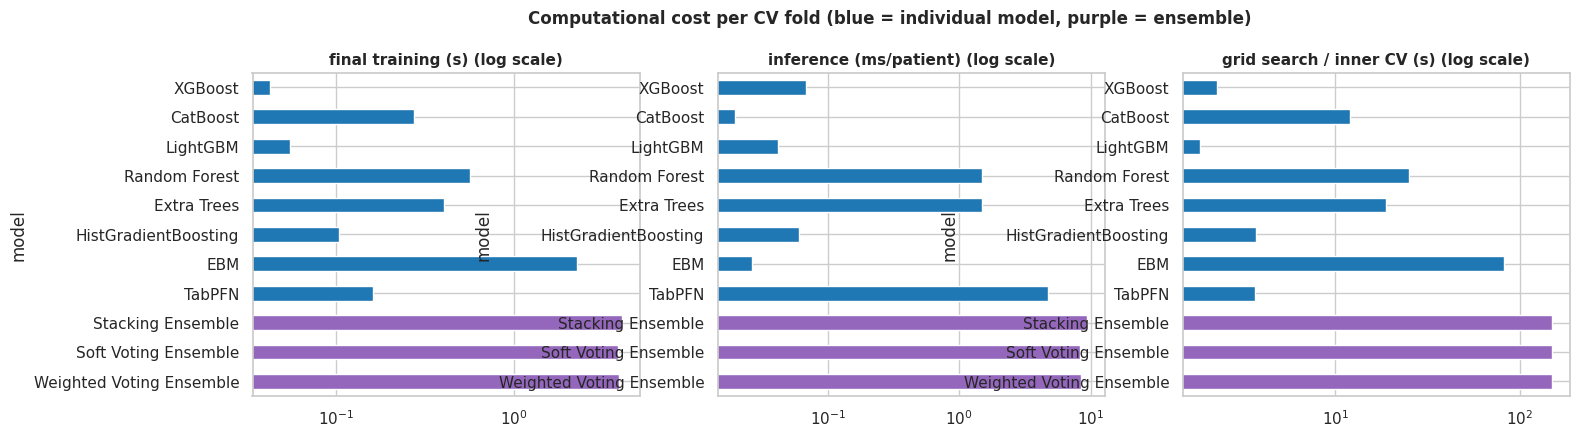

In [21]:
def model_size_mb(model):
    try:
        return len(pickle.dumps(model, protocol=4)) / 1e6
    except Exception:
        return np.nan


cost_table = cv_time_df.groupby("model")[["preprocessing (s)", "grid search / inner CV (s)", "final training (s)",
                                          "inference (ms/patient)", "configs searched"]].mean().loc[ALL_MODELS]
cost_table["total per fold (s)"] = cost_table[["preprocessing (s)", "grid search / inner CV (s)", "final training (s)"]].sum(axis=1)
cost_table["model size (MB)"] = [model_size_mb(tuned_run["models"][m]) for m in ALL_MODELS]
cost_table = save_table(cost_table.round(4), "07_computational_cost")
display(cost_table)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, col in zip(axes, ["final training (s)", "inference (ms/patient)", "grid search / inner CV (s)"]):
    cost_table[col].plot.barh(ax=ax, color=["tab:purple" if m in ENSEMBLE_MODELS else "tab:blue" for m in ALL_MODELS])
    ax.set_xscale("log")
    ax.set_title(col + " (log scale)")
    ax.invert_yaxis()
fig.suptitle("Computational cost per CV fold (blue = individual model, purple = ensemble)", fontweight="bold", y=1.03)
save_fig(fig, "07_computational_cost")

### 7.4 Selecting the overall best-performing (proposed) model
Each model is ranked on the 10-fold CV mean of **11 performance criteria** (Accuracy, Precision, Recall, F1, FPR, FNR, TNR, AUC, Kappa,
Brier, Cost) and **2 computational criteria** (final training time, inference time); all 13 criteria get equal weight, so performance
dominates (11/13). Means are rounded to 4 decimals before ranking so that numerically identical scores tie. Ties in the overall
rank are broken by higher AUC, then lower Brier score. Section 9 then tests whether the winner is *significantly* better.

In [22]:
perf_ranks = pd.DataFrame({c: cv_mean[c].round(4).rank(ascending=not HIGHER_BETTER[c], method="average") for c in METRICS})
eff_ranks = pd.DataFrame({"training time": cost_table["final training (s)"].rank(method="average"),
                          "inference time": cost_table["inference (ms/patient)"].rank(method="average")})
all_ranks = pd.concat([perf_ranks, eff_ranks], axis=1)
selection = pd.DataFrame({"mean performance rank (11)": perf_ranks.mean(axis=1),
                          "mean efficiency rank (2)": eff_ranks.mean(axis=1),
                          "overall mean rank (13)": all_ranks.mean(axis=1),
                          "CV AUC": cv_mean["AUC"], "CV Accuracy": cv_mean["Accuracy"], "CV F1": cv_mean["F1-score"],
                          "CV Recall": cv_mean["Recall (TPR)"], "CV Brier": cv_mean["Brier"],
                          "train time (s)": cost_table["final training (s)"]})
selection = selection.sort_values(["overall mean rank (13)", "CV AUC", "CV Brier"], ascending=[True, False, True])
selection.insert(0, "position", range(1, len(selection) + 1))
save_table(selection.round(4), "07_model_selection")
display(selection.round(4))
display(all_ranks.loc[selection.index].round(1))

PROPOSED = selection.index[0]
PROPOSED_MODEL = tuned_run["models"][PROPOSED]          # fitted on the training split; test set still unseen
display(Markdown(f"### ★ Proposed model: **{PROPOSED}**\n"
                 f"{OUTER_CV_FOLDS}-fold CV: AUC {cv_mean.at[PROPOSED, 'AUC']:.4f} ± {cv_std.at[PROPOSED, 'AUC']:.4f}, "
                 f"Accuracy {cv_mean.at[PROPOSED, 'Accuracy']:.4f} ± {cv_std.at[PROPOSED, 'Accuracy']:.4f}, "
                 f"F1 {cv_mean.at[PROPOSED, 'F1-score']:.4f}, Recall {cv_mean.at[PROPOSED, 'Recall (TPR)']:.4f}, "
                 f"Brier {cv_mean.at[PROPOSED, 'Brier']:.4f}; mean training time {cost_table.at[PROPOSED, 'final training (s)']:.2f}s/fold."))

MODEL_COLORS = dict(zip(ALL_MODELS, sns.color_palette("tab20", len(ALL_MODELS))))


def label(m):
    return f"{m} ★" if m == PROPOSED else m


def grid_axes(n, ncols=4, w=4.0, h=3.6):
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes

,position,mean performance rank (11),mean efficiency rank (2),overall mean rank (13),CV AUC,CV Accuracy,CV F1,CV Recall,CV Brier,train time (s)
model,,,,,,,,,,
EBM,1,3.0455,5.0,3.3462,1.0000,1.0000,1.0000,1.000,0.0001,2.2516
Stacking Ensemble,2,3.1364,11.0,4.3462,1.0000,1.0000,1.0000,1.000,0.0003,4.0656
TabPFN,3,4.9545,6.0,5.1154,1.0000,0.9950,0.9959,0.992,0.0026,0.1613
Random Forest,4,5.1364,6.5,5.3462,1.0000,0.9950,0.9958,0.992,0.0040,0.5687
Extra Trees,5,5.2273,6.5,5.4231,1.0000,0.9950,0.9959,0.992,0.0044,0.4065
Weighted Voting Ensemble,6,4.8636,10.0,5.6538,1.0000,0.9950,0.9959,0.992,0.0022,3.8735
XGBoost,7,7.4545,3.0,6.7692,0.9995,0.9925,0.9939,0.988,0.0075,0.0428
Soft Voting Ensemble,8,6.6818,9.0,7.0385,1.0000,0.9925,0.9939,0.988,0.0038,3.8657
LightGBM,9,8.3182,2.5,7.4231,1.0000,0.9900,0.9918,0.984,0.0103,0.0551


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC,Kappa,Brier,Cost,training time,inference time
model,,,,,,,,,,,,,
EBM,1.5,6.0,1.5,1.5,6.0,1.5,6.0,5.5,1.5,1.0,1.5,8.0,2.0
Stacking Ensemble,1.5,6.0,1.5,1.5,6.0,1.5,6.0,5.5,1.5,2.0,1.5,11.0,11.0
TabPFN,4.5,6.0,4.5,4.0,6.0,4.5,6.0,5.5,5.0,4.0,4.5,4.0,8.0
Random Forest,4.5,6.0,4.5,6.0,6.0,4.5,6.0,5.5,3.0,6.0,4.5,7.0,6.0
Extra Trees,4.5,6.0,4.5,4.0,6.0,4.5,6.0,5.5,5.0,7.0,4.5,6.0,7.0
Weighted Voting Ensemble,4.5,6.0,4.5,4.0,6.0,4.5,6.0,5.5,5.0,3.0,4.5,10.0,10.0
XGBoost,7.5,6.0,7.5,7.5,6.0,7.5,6.0,11.0,7.5,8.0,7.5,1.0,5.0
Soft Voting Ensemble,7.5,6.0,7.5,7.5,6.0,7.5,6.0,5.5,7.5,5.0,7.5,9.0,9.0
LightGBM,9.5,6.0,9.5,9.5,6.0,9.5,6.0,5.5,9.5,11.0,9.5,2.0,3.0


### ★ Proposed model: **EBM**
10-fold CV: AUC 1.0000 ± 0.0000, Accuracy 1.0000 ± 0.0000, F1 1.0000, Recall 1.0000, Brier 0.0001; mean training time 2.25s/fold.

## 8. Diagnostic plots for every model (including the proposed model)
Plots use the **pooled out-of-fold predictions of the 10-fold CV** (n = 400, each patient predicted once by a model that never saw it),
which is far more stable than the 80-patient hold-out set. The hold-out confusion matrices are shown as well for completeness.
### 8.1 Confusion matrices

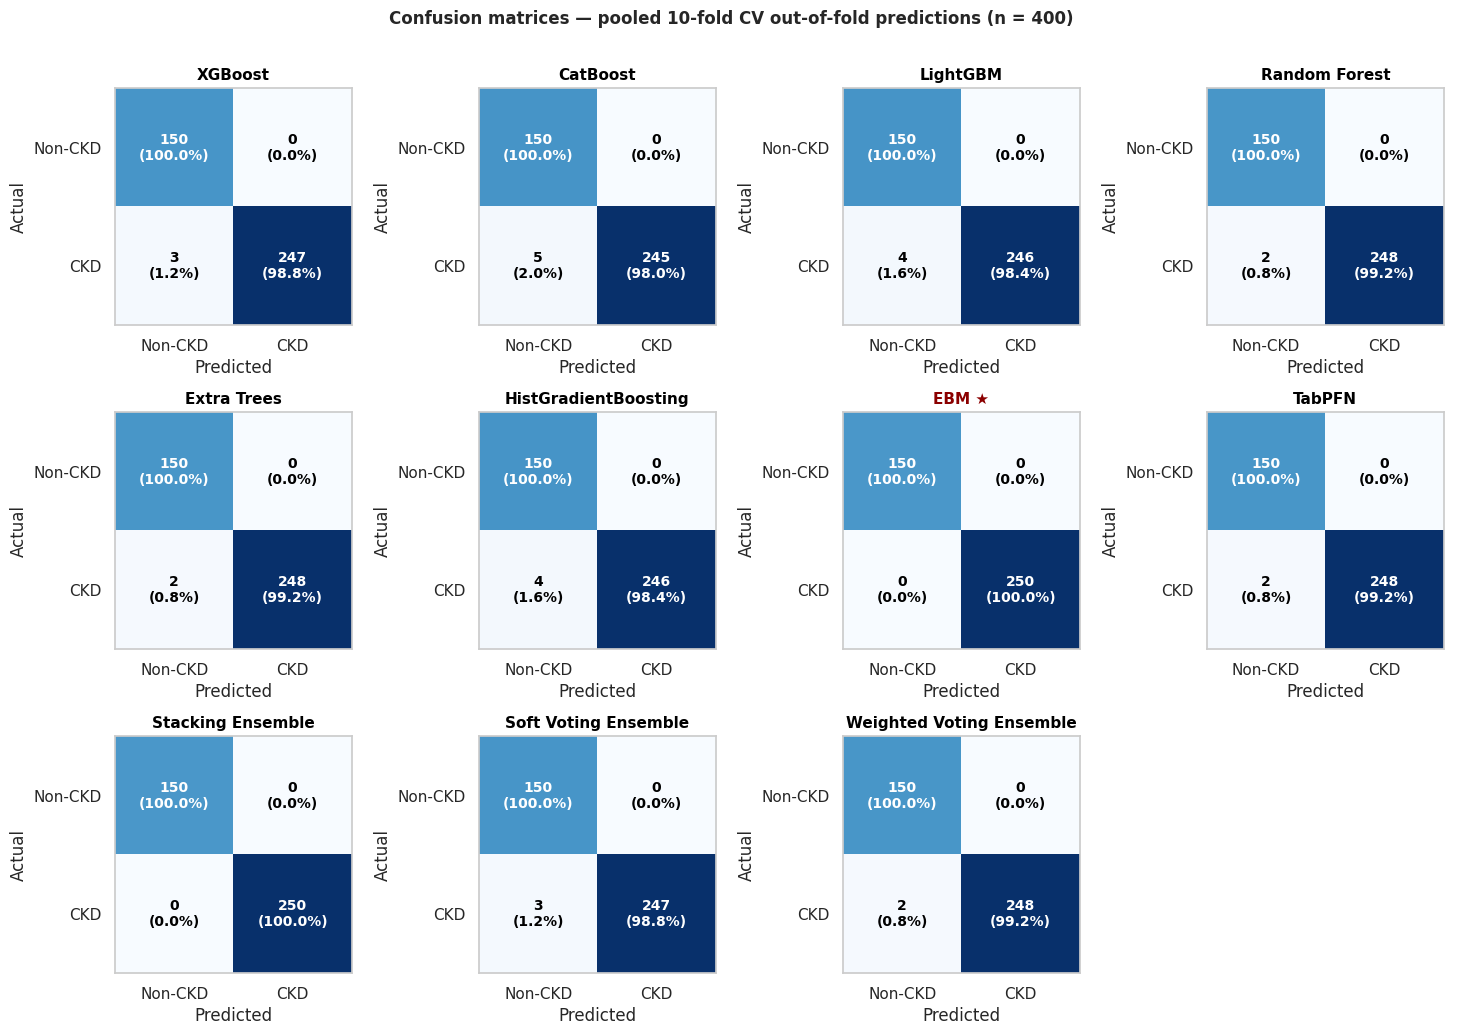

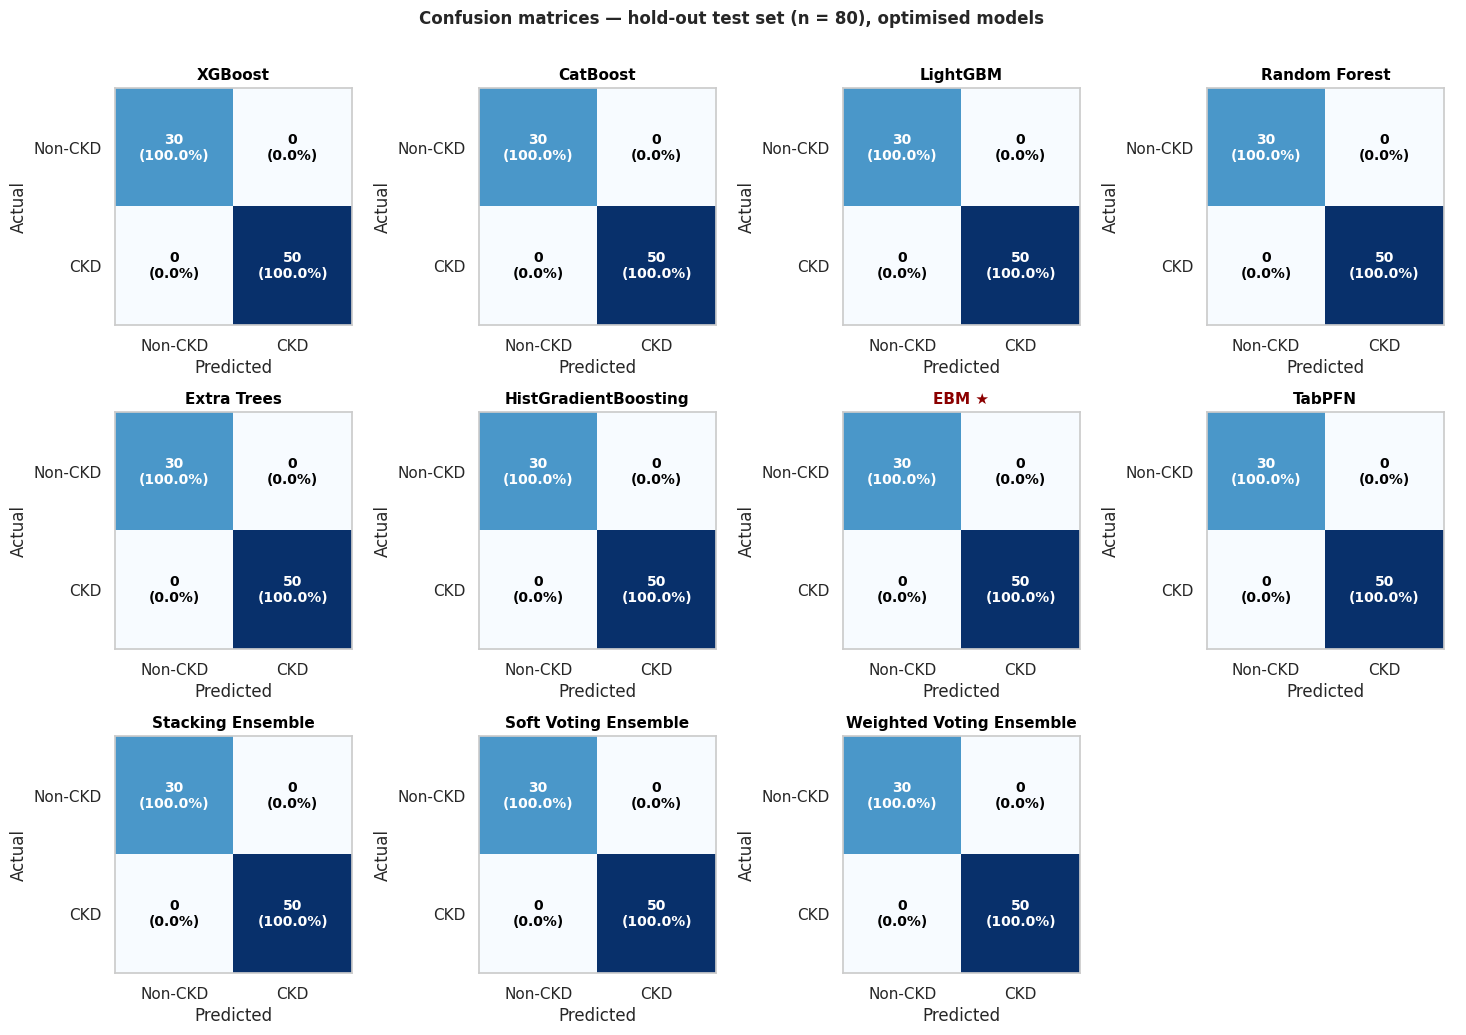

In [23]:
def plot_confusion_grid(proba, y_true, title, fname):
    fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=3.7, h=3.4)
    for ax, m in zip(axes, ALL_MODELS):
        cm = confusion_matrix(y_true, (proba[m] >= DECISION_THRESHOLD).astype(int), labels=[0, 1])
        ax.imshow(cm, cmap="Blues", vmin=0)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i, j]}\n({cm[i, j] / max(cm[i].sum(), 1):.1%})", ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10, fontweight="bold")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(label(m), color="darkred" if m == PROPOSED else "black")
        ax.grid(False)
    fig.suptitle(title, fontweight="bold", y=1.01)
    fig.tight_layout()
    save_fig(fig, fname)


plot_confusion_grid(cv_oof, y_all_np, "Confusion matrices — pooled 10-fold CV out-of-fold predictions (n = 400)", "08_1_confusion_cv")
plot_confusion_grid(tuned_run["proba"], y_test.to_numpy(), "Confusion matrices — hold-out test set (n = 80), optimised models",
                    "08_1_confusion_holdout")

### 8.2 ROC curve analysis
Thin lines: one ROC curve per CV fold; thick line: mean ROC; band: ±1 SD.

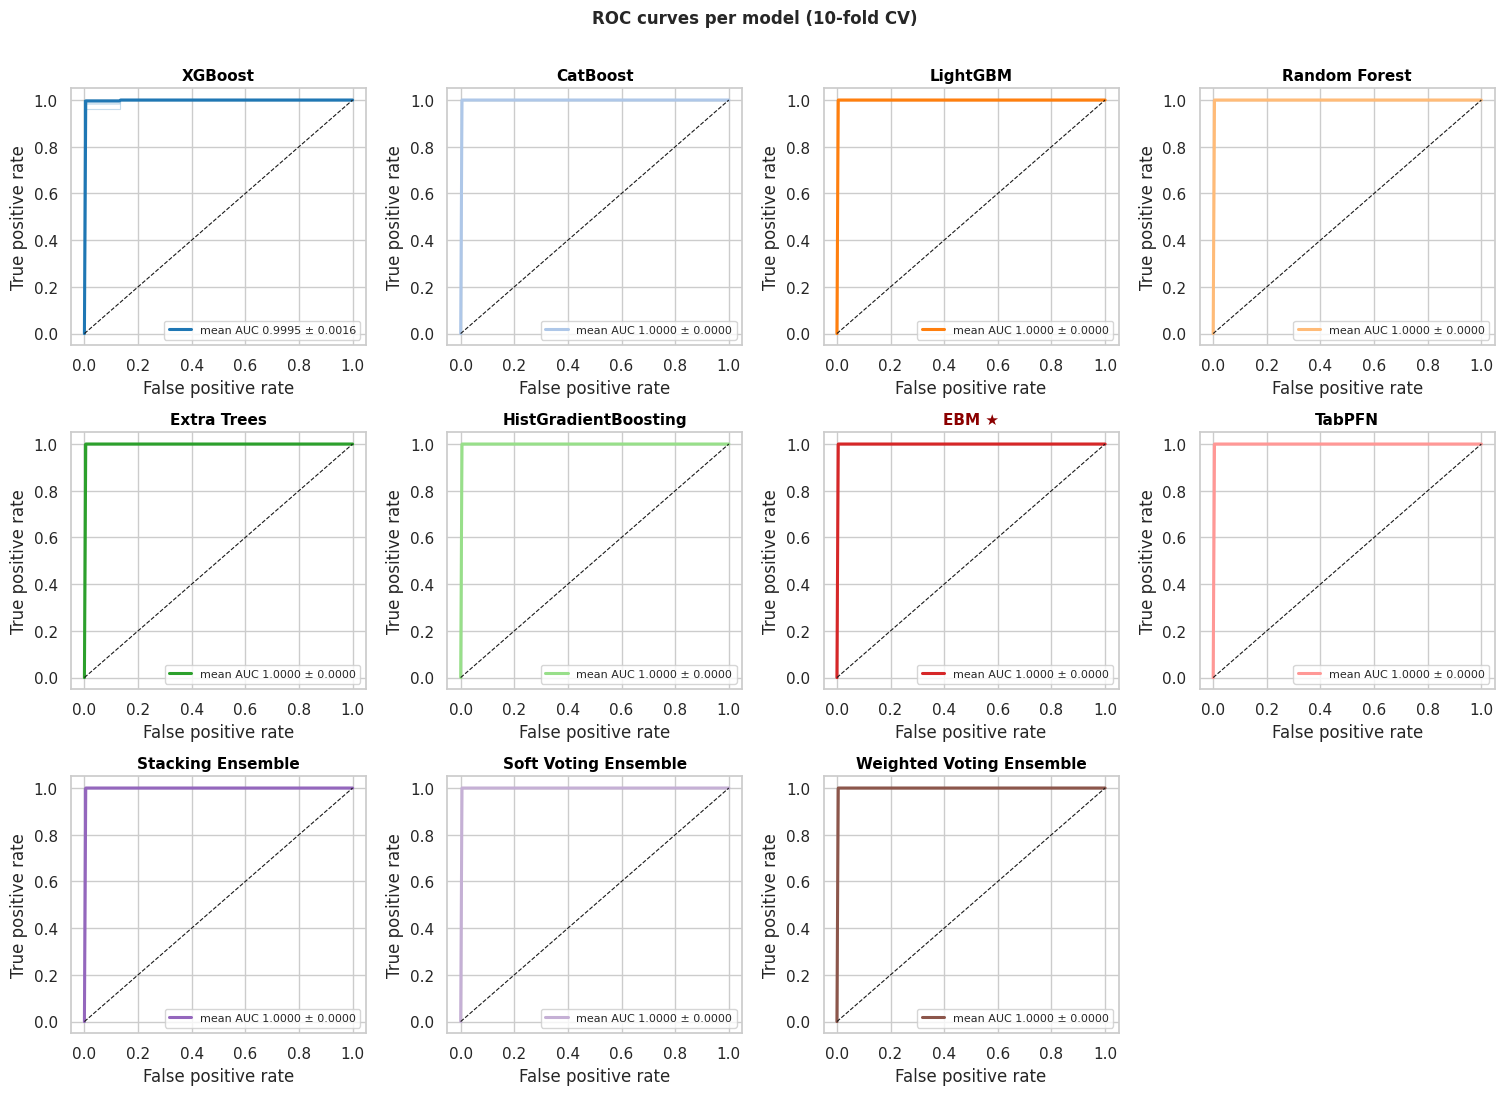

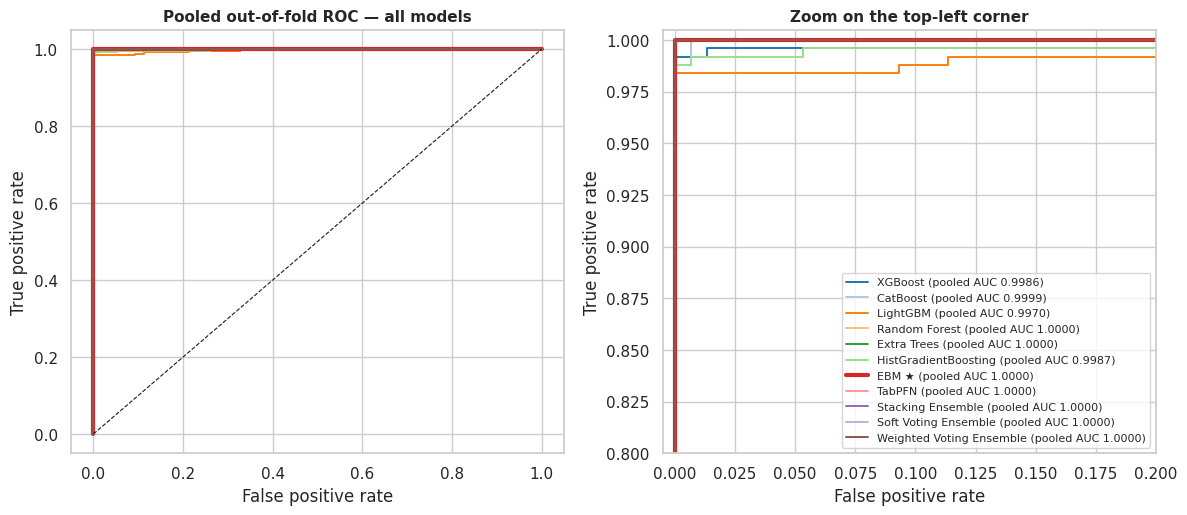

In [24]:
BASE_FPR = np.linspace(0, 1, 201)
roc_summary = {}
fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=3.8, h=3.6)
for ax, m in zip(axes, ALL_MODELS):
    tprs, aucs = [], []
    for k in range(1, OUTER_CV_FOLDS + 1):
        idx = cv_fold_of == k
        fpr, tpr, _ = roc_curve(y_all_np[idx], cv_oof[m][idx])
        ax.plot(fpr, tpr, color=MODEL_COLORS[m], alpha=0.25, lw=0.8)
        t = np.interp(BASE_FPR, fpr, tpr)
        t[0] = 0.0
        tprs.append(t)
        aucs.append(roc_auc_score(y_all_np[idx], cv_oof[m][idx]))
    mt, st = np.mean(tprs, axis=0), np.std(tprs, axis=0)
    mt[-1] = 1.0
    roc_summary[m] = (mt, np.mean(aucs), np.std(aucs))
    ax.plot(BASE_FPR, mt, color=MODEL_COLORS[m], lw=2.2, label=f"mean AUC {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    ax.fill_between(BASE_FPR, np.clip(mt - st, 0, 1), np.clip(mt + st, 0, 1), color=MODEL_COLORS[m], alpha=0.15)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(label(m), color="darkred" if m == PROPOSED else "black")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("ROC curves per model (10-fold CV)", fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "08_2_roc_per_model")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for m in ALL_MODELS:
    fpr, tpr, _ = roc_curve(y_all_np, cv_oof[m])
    for ax in axes:
        ax.plot(fpr, tpr, color=MODEL_COLORS[m], lw=3 if m == PROPOSED else 1.4,
                label=f"{label(m)} (pooled AUC {roc_auc_score(y_all_np, cv_oof[m]):.4f})")
for ax in axes:
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
axes[0].set_title("Pooled out-of-fold ROC — all models")
axes[1].set_xlim(-0.005, 0.2)
axes[1].set_ylim(0.8, 1.005)
axes[1].set_title("Zoom on the top-left corner")
axes[1].legend(fontsize=8, loc="lower right")
save_fig(fig, "08_2_roc_overlay")

### 8.3 Confidence distribution — histogram of the maximum predicted class probability
For each patient, confidence = max(P(CKD), P(Non-CKD)). Well-behaved models place correct predictions near 1 and any errors at low confidence.

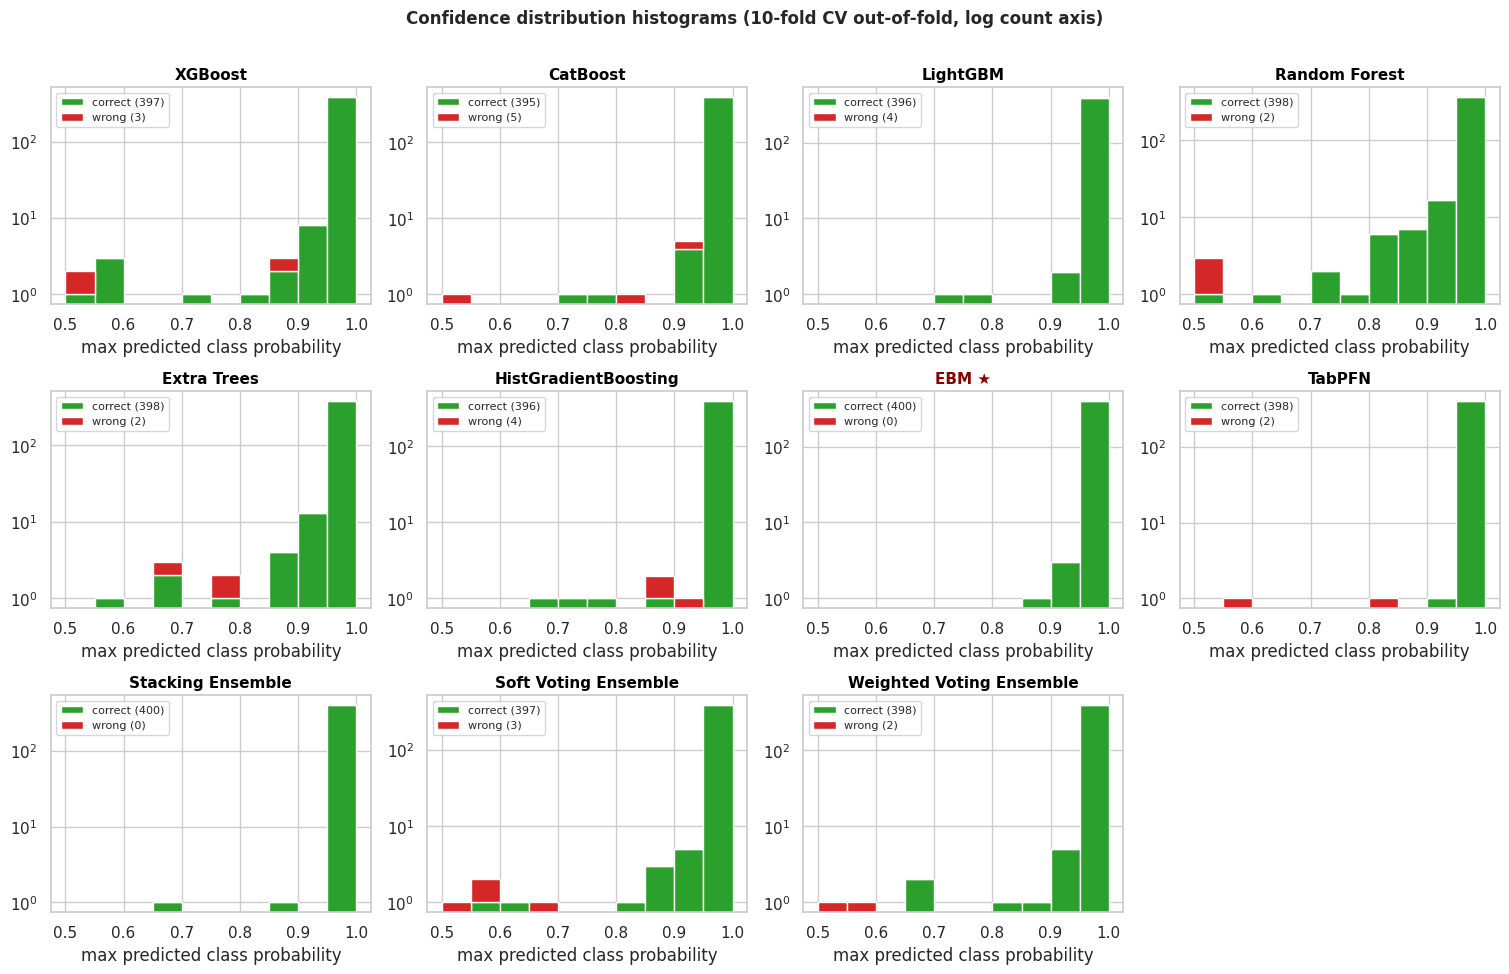

,mean confidence,mean conf. (correct),mean conf. (wrong),share with confidence ≥ 0.9
model,,,,
XGBoost,0.9848,0.9862,0.8009,0.9750
CatBoost,0.9940,0.9959,0.8425,0.9900
LightGBM,0.9972,0.9972,0.9960,0.9950
Random Forest,0.9815,0.9837,0.5300,0.9500
Extra Trees,0.9886,0.9898,0.7467,0.9750
HistGradientBoosting,0.9953,0.9958,0.9466,0.9875
EBM,0.9991,0.9991,NaN,0.9975
TabPFN,0.9977,0.9992,0.6994,0.9950
Stacking Ensemble,0.9988,0.9988,NaN,0.9950


In [25]:
fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=3.8, h=3.2)
bins = np.linspace(0.5, 1.0, 11)
conf_rows = []
for ax, m in zip(axes, ALL_MODELS):
    p = cv_oof[m]
    conf = np.maximum(p, 1 - p)
    correct = ((p >= DECISION_THRESHOLD).astype(int) == y_all_np)
    ax.hist([conf[correct], conf[~correct]], bins=bins, stacked=True, color=["tab:green", "tab:red"],
            label=[f"correct ({correct.sum()})", f"wrong ({(~correct).sum()})"])
    ax.set_yscale("log")
    ax.set_title(label(m), color="darkred" if m == PROPOSED else "black")
    ax.set_xlabel("max predicted class probability")
    ax.legend(fontsize=8, loc="upper left")
    conf_rows.append({"model": m, "mean confidence": conf.mean(), "mean conf. (correct)": conf[correct].mean(),
                      "mean conf. (wrong)": conf[~correct].mean() if (~correct).any() else np.nan,
                      "share with confidence ≥ 0.9": (conf >= 0.9).mean()})
fig.suptitle("Confidence distribution histograms (10-fold CV out-of-fold, log count axis)", fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "08_3_confidence_histograms")
display(save_table(pd.DataFrame(conf_rows).set_index("model").round(4), "08_3_confidence_summary"))

### 8.4 Calibration curves (reliability diagrams)

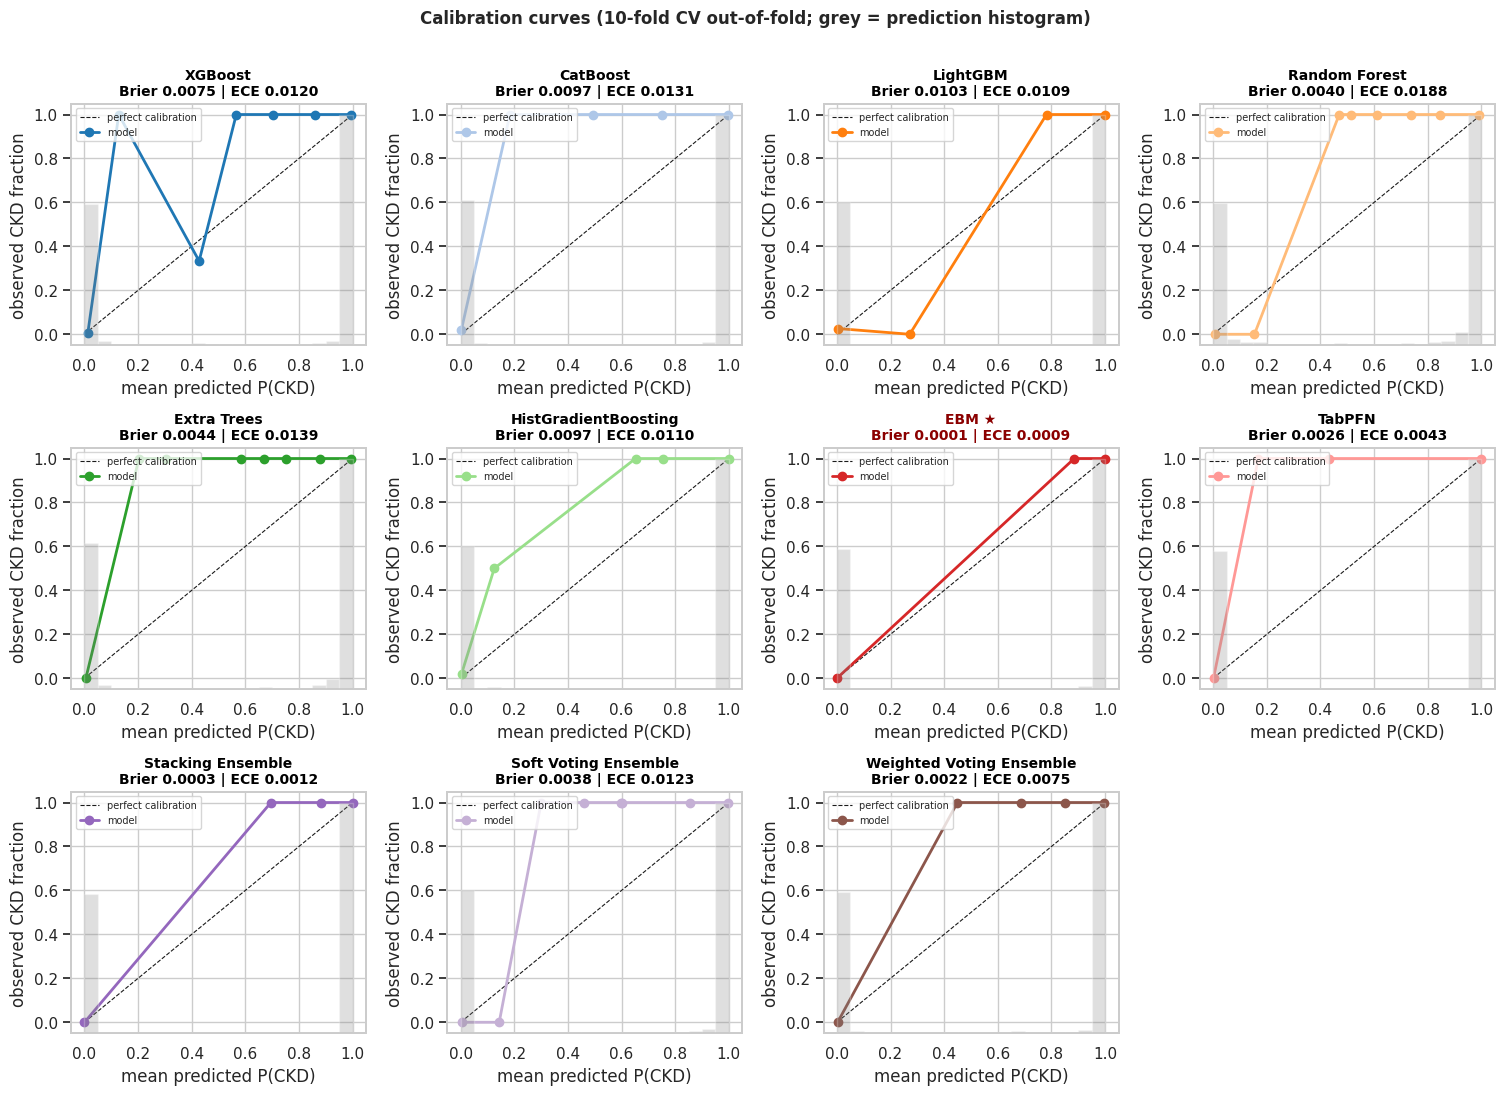

,Brier,ECE,log-loss
model,,,
XGBoost,0.0075,0.0120,0.0334
CatBoost,0.0097,0.0131,0.0357
LightGBM,0.0103,0.0109,0.0696
Random Forest,0.0040,0.0188,0.0216
Extra Trees,0.0044,0.0139,0.0181
HistGradientBoosting,0.0097,0.0110,0.0430
EBM,0.0001,0.0009,0.0009
TabPFN,0.0026,0.0043,0.0074
Stacking Ensemble,0.0003,0.0012,0.0014


In [26]:
def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    return sum(np.abs(y[idx == b].mean() - p[idx == b].mean()) * (idx == b).mean() for b in range(n_bins) if (idx == b).any())


fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=3.8, h=3.6)
cal_rows = []
for ax, m in zip(axes, ALL_MODELS):
    frac_pos, mean_pred = calibration_curve(y_all_np, cv_oof[m], n_bins=10, strategy="uniform")
    ece = expected_calibration_error(y_all_np, cv_oof[m])
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color=MODEL_COLORS[m], lw=2, label="model")
    ax2 = ax.twinx()
    ax2.hist(cv_oof[m], bins=20, range=(0, 1), color="grey", alpha=0.25)
    ax2.set_yticks([])
    ax.set_title(f"{label(m)}\nBrier {brier_score_loss(y_all_np, cv_oof[m]):.4f} | ECE {ece:.4f}",
                 color="darkred" if m == PROPOSED else "black", fontsize=10)
    ax.set_xlabel("mean predicted P(CKD)")
    ax.set_ylabel("observed CKD fraction")
    ax.legend(fontsize=7, loc="upper left")
    cal_rows.append({"model": m, "Brier": brier_score_loss(y_all_np, cv_oof[m]), "ECE": ece,
                     "log-loss": log_loss(y_all_np, np.clip(cv_oof[m], 1e-6, 1 - 1e-6))})
fig.suptitle("Calibration curves (10-fold CV out-of-fold; grey = prediction histogram)", fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "08_4_calibration_per_model")
display(save_table(pd.DataFrame(cal_rows).set_index("model").round(4), "08_4_calibration_summary"))

### 8.5 Decision Curve Analysis (DCA)
Net benefit at threshold probability $p_t$: $NB = \frac{TP}{N} - \frac{FP}{N}\cdot\frac{p_t}{1-p_t}$, compared with *treat all* and *treat none*.

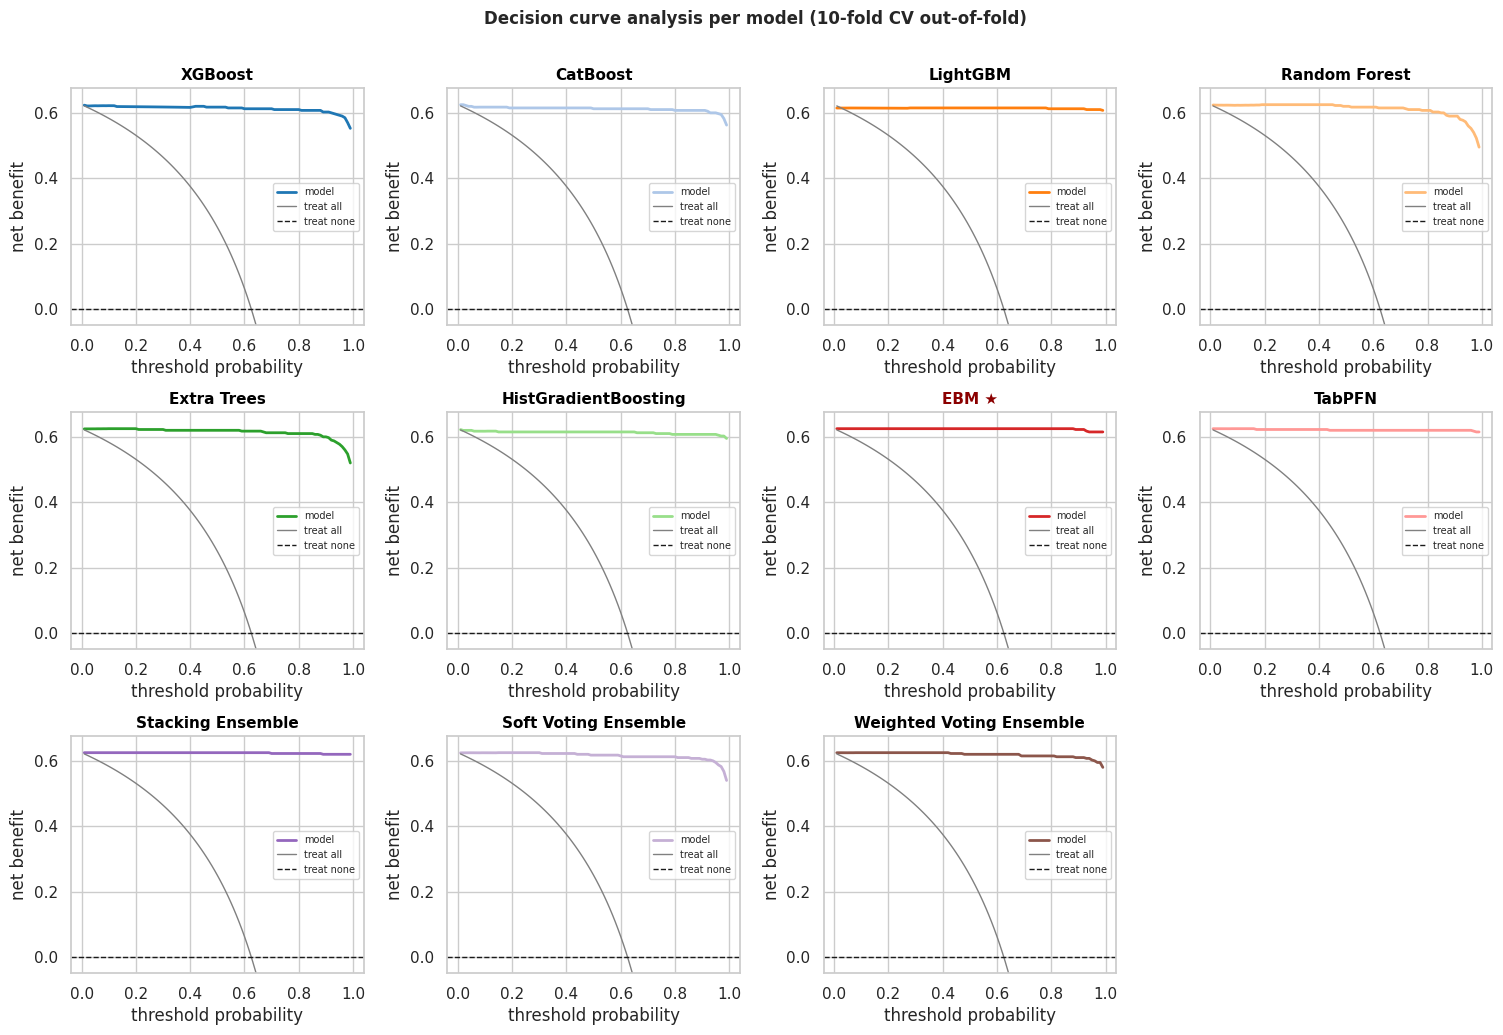

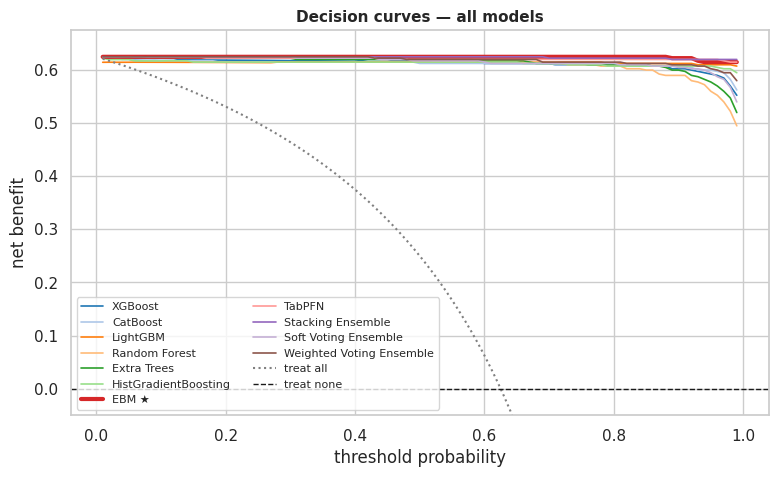

,p_t=0.1,p_t=0.2,p_t=0.3,p_t=0.5,p_t=0.7,treat all @0.5
XGBoost,0.6219,0.6188,0.6179,0.6175,0.6125,0.25
CatBoost,0.6175,0.6150,0.6150,0.6125,0.6125,0.25
LightGBM,0.6147,0.6144,0.6150,0.6150,0.6150,0.25
Random Forest,0.6233,0.6250,0.6250,0.6200,0.6150,0.25
Extra Trees,0.6250,0.6250,0.6225,0.6200,0.6125,0.25
HistGradientBoosting,0.6172,0.6150,0.6150,0.6150,0.6125,0.25
EBM,0.6250,0.6250,0.6250,0.6250,0.6250,0.25
TabPFN,0.6250,0.6225,0.6225,0.6200,0.6200,0.25
Stacking Ensemble,0.6250,0.6250,0.6250,0.6250,0.6225,0.25
Soft Voting Ensemble,0.6247,0.6250,0.6250,0.6175,0.6125,0.25


In [27]:
DCA_T = np.round(np.arange(0.01, 0.991, 0.01), 2)


def net_benefit(y, p, thresholds=DCA_T):
    y = np.asarray(y).astype(int)
    n = len(y)
    out = []
    for t in thresholds:
        pred = p >= t
        tp = np.sum(pred & (y == 1))
        fp = np.sum(pred & (y == 0))
        out.append(tp / n - fp / n * t / (1 - t))
    return np.array(out)


prev = y_all_np.mean()
nb_all = prev - (1 - prev) * DCA_T / (1 - DCA_T)
dca = {m: net_benefit(y_all_np, cv_oof[m]) for m in ALL_MODELS}
fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=3.8, h=3.4)
for ax, m in zip(axes, ALL_MODELS):
    ax.plot(DCA_T, dca[m], color=MODEL_COLORS[m], lw=2, label="model")
    ax.plot(DCA_T, nb_all, color="grey", lw=1, label="treat all")
    ax.axhline(0, color="k", lw=1, ls="--", label="treat none")
    ax.set_ylim(-0.05, prev + 0.05)
    ax.set_title(label(m), color="darkred" if m == PROPOSED else "black")
    ax.set_xlabel("threshold probability")
    ax.set_ylabel("net benefit")
    ax.legend(fontsize=7)
fig.suptitle("Decision curve analysis per model (10-fold CV out-of-fold)", fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "08_5_dca_per_model")

fig, ax = plt.subplots(figsize=(9, 5))
for m in ALL_MODELS:
    ax.plot(DCA_T, dca[m], color=MODEL_COLORS[m], lw=3 if m == PROPOSED else 1.2, label=label(m))
ax.plot(DCA_T, nb_all, color="grey", lw=1.5, ls=":", label="treat all")
ax.axhline(0, color="k", lw=1, ls="--", label="treat none")
ax.set_ylim(-0.05, prev + 0.05)
ax.set_xlabel("threshold probability")
ax.set_ylabel("net benefit")
ax.set_title("Decision curves — all models")
ax.legend(fontsize=8, ncol=2)
save_fig(fig, "08_5_dca_overlay")
dca_tab = pd.DataFrame({m: dca[m][[9, 19, 29, 49, 69]] for m in ALL_MODELS}, index=[f"p_t={t}" for t in DCA_T[[9, 19, 29, 49, 69]]]).T
dca_tab["treat all @0.5"] = nb_all[49]
display(save_table(dca_tab.round(4), "08_5_net_benefit"))

## 9. Statistical significance testing
### 9.1 Paired t-test (proposed model vs every other model, per-fold 10-fold CV scores)
The classical paired t-test on CV folds is reported as requested. Because CV folds share training data, it is known to be
anti-conservative, so the **Nadeau–Bengio corrected resampled t-test** (variance inflated by $1/k + n_{test}/n_{train}$) is reported next to it.
p-values are Holm-adjusted across the comparisons within each metric. If two models have identical scores in every fold,
the difference is exactly zero and p = 1.


--- Accuracy (higher is better)


,proposed mean,other mean,mean diff,t,p (paired t),t (corrected),p (corrected),note,"p (paired t, Holm)","p (corrected, Holm)","significant (corrected, Holm < 0.05)"
comparison,,,,,,,,,,,
EBM vs XGBoost,1.0,0.9925,0.0075,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False
EBM vs CatBoost,1.0,0.9875,0.0125,1.6270,0.1382,1.1198,0.2918,,0.8291,1.0,False
EBM vs LightGBM,1.0,0.9900,0.0100,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs Random Forest,1.0,0.9950,0.0050,1.0000,0.3434,0.6882,0.5086,,0.8393,1.0,False
EBM vs Extra Trees,1.0,0.9950,0.0050,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs HistGradientBoosting,1.0,0.9900,0.0100,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs TabPFN,1.0,0.9950,0.0050,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs Stacking Ensemble,1.0,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,identical in every fold,1.0000,1.0,False
EBM vs Soft Voting Ensemble,1.0,0.9925,0.0075,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False



--- F1-score (higher is better)


,proposed mean,other mean,mean diff,t,p (paired t),t (corrected),p (corrected),note,"p (paired t, Holm)","p (corrected, Holm)","significant (corrected, Holm < 0.05)"
comparison,,,,,,,,,,,
EBM vs XGBoost,1.0,0.9939,0.0061,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False
EBM vs CatBoost,1.0,0.9895,0.0105,1.6079,0.1423,1.1066,0.2972,,0.8539,1.0,False
EBM vs LightGBM,1.0,0.9918,0.0082,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs Random Forest,1.0,0.9958,0.0042,1.0000,0.3434,0.6882,0.5086,,0.8539,1.0,False
EBM vs Extra Trees,1.0,0.9959,0.0041,1.5000,0.1679,1.0324,0.3288,,0.8539,1.0,False
EBM vs HistGradientBoosting,1.0,0.9918,0.0082,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs TabPFN,1.0,0.9959,0.0041,1.5000,0.1679,1.0324,0.3288,,0.8539,1.0,False
EBM vs Stacking Ensemble,1.0,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,identical in every fold,1.0000,1.0,False
EBM vs Soft Voting Ensemble,1.0,0.9939,0.0061,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False



--- AUC (higher is better)


...

,proposed mean,other mean,mean diff,t,p (paired t),t (corrected),p (corrected),note,"p (paired t, Holm)","p (corrected, Holm)","significant (corrected, Holm < 0.05)"
comparison,,,,,,,,,,,
EBM vs XGBoost,1.0,0.988,0.012,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False
EBM vs CatBoost,1.0,0.980,0.020,1.6270,0.1382,1.1198,0.2918,,0.8291,1.0,False
EBM vs LightGBM,1.0,0.984,0.016,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs Random Forest,1.0,0.992,0.008,1.0000,0.3434,0.6882,0.5086,,0.8393,1.0,False
EBM vs Extra Trees,1.0,0.992,0.008,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs HistGradientBoosting,1.0,0.984,0.016,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs TabPFN,1.0,0.992,0.008,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs Stacking Ensemble,1.0,1.000,0.000,0.0000,1.0000,0.0000,1.0000,identical in every fold,1.0000,1.0,False
EBM vs Soft Voting Ensemble,1.0,0.988,0.012,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False



--- Kappa (higher is better)


,proposed mean,other mean,mean diff,t,p (paired t),t (corrected),p (corrected),note,"p (paired t, Holm)","p (corrected, Holm)","significant (corrected, Holm < 0.05)"
comparison,,,,,,,,,,,
EBM vs XGBoost,1.0,0.9842,0.0158,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False
EBM vs CatBoost,1.0,0.9741,0.0259,1.6389,0.1357,1.1280,0.2885,,0.8139,1.0,False
EBM vs LightGBM,1.0,0.9789,0.0211,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs Random Forest,1.0,0.9896,0.0104,1.0000,0.3434,0.6882,0.5086,,0.8393,1.0,False
EBM vs Extra Trees,1.0,0.9895,0.0105,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs HistGradientBoosting,1.0,0.9789,0.0211,2.4495,0.0368,1.6859,0.1261,,0.3679,1.0,False
EBM vs TabPFN,1.0,0.9895,0.0105,1.5000,0.1679,1.0324,0.3288,,0.8393,1.0,False
EBM vs Stacking Ensemble,1.0,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,identical in every fold,1.0000,1.0,False
EBM vs Soft Voting Ensemble,1.0,0.9842,0.0158,1.9640,0.0811,1.3517,0.2095,,0.6490,1.0,False



--- Brier (lower is better)


,proposed mean,other mean,mean diff,t,p (paired t),t (corrected),p (corrected),note,"p (paired t, Holm)","p (corrected, Holm)","significant (corrected, Holm < 0.05)"
comparison,,,,,,,,,,,
EBM vs XGBoost,0.0001,0.0075,-0.0074,-2.4293,0.0380,-1.6720,0.1289,,0.2719,1.0,False
EBM vs CatBoost,0.0001,0.0097,-0.0096,-1.8936,0.0908,-1.3033,0.2248,,0.4437,1.0,False
EBM vs LightGBM,0.0001,0.0103,-0.0102,-2.5905,0.0292,-1.7829,0.1083,,0.2719,1.0,False
EBM vs Random Forest,0.0001,0.0040,-0.0039,-2.6338,0.0272,-1.8127,0.1033,,0.2719,1.0,False
EBM vs Extra Trees,0.0001,0.0044,-0.0043,-1.9081,0.0887,-1.3132,0.2216,,0.4437,1.0,False
EBM vs HistGradientBoosting,0.0001,0.0097,-0.0096,-2.5188,0.0328,-1.7335,0.1170,,0.2719,1.0,False
EBM vs TabPFN,0.0001,0.0026,-0.0025,-1.3684,0.2044,-0.9418,0.3709,,0.4437,1.0,False
EBM vs Stacking Ensemble,0.0001,0.0003,-0.0002,-0.8767,0.4035,-0.6034,0.5612,,0.4437,1.0,False
EBM vs Soft Voting Ensemble,0.0001,0.0038,-0.0038,-2.3159,0.0458,-1.5939,0.1454,,0.2748,1.0,False


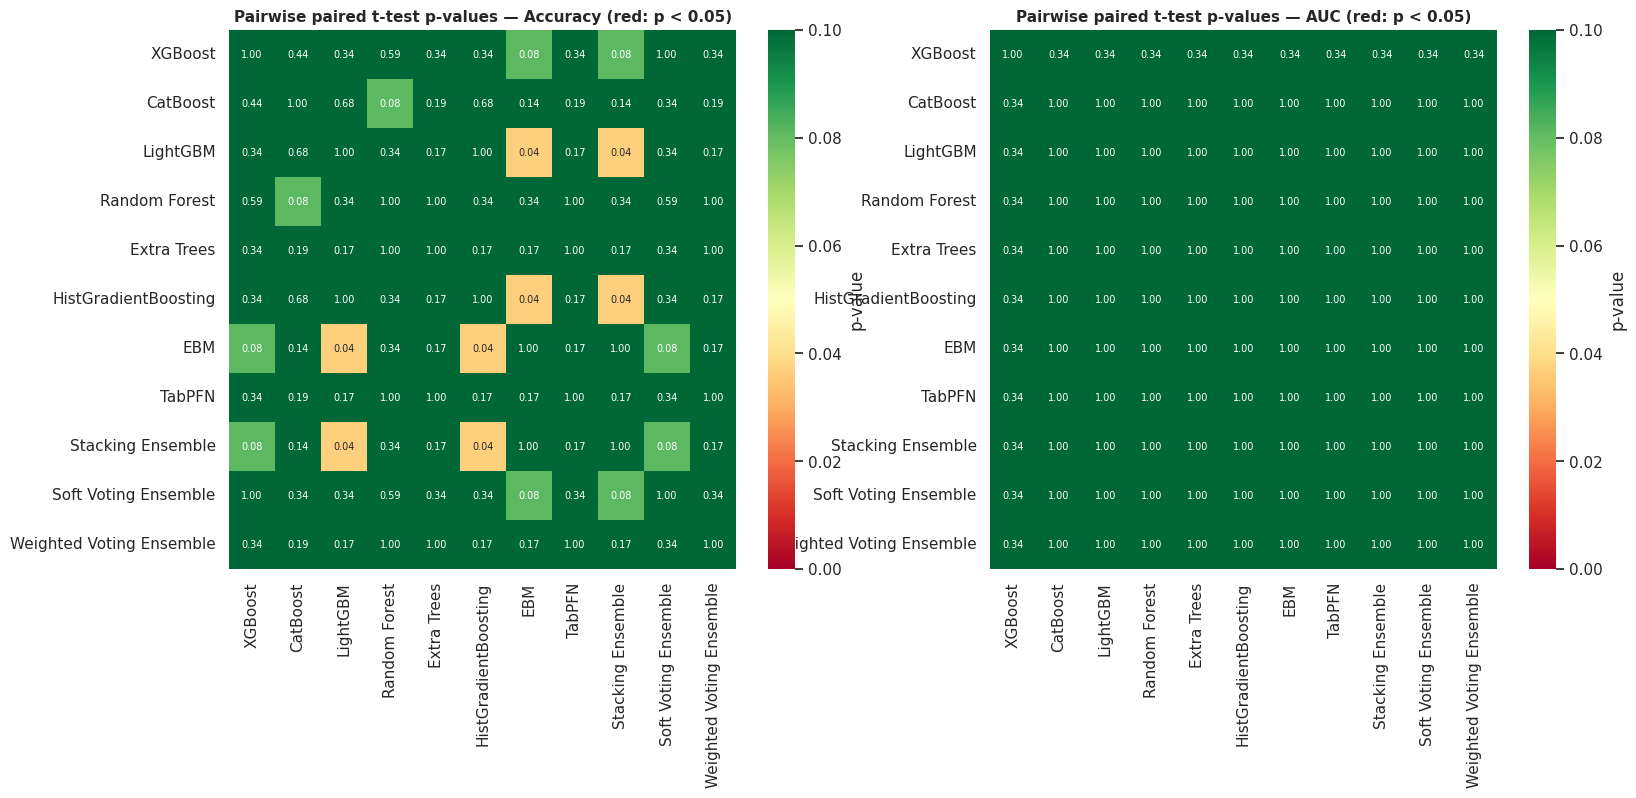

In [28]:
def paired_t_tests(a, b, n_train, n_test):
    """Classical paired t-test (scipy.stats.ttest_rel) + Nadeau-Bengio corrected resampled t-test.
    Per-fold differences are rounded to 10 decimals so floating-point noise cannot create a spurious zero-variance
    'significance'. If every fold difference is identical the t statistic is undefined: identical scores -> p = 1;
    a constant non-zero difference -> p reported as NaN and flagged in the 'note' column."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = np.round(a - b, 10)
    k = len(d)
    mean_d, sd = d.mean(), d.std(ddof=1)
    if sd <= 1e-12:
        if abs(mean_d) <= 1e-12:
            return {"mean diff": 0.0, "t": 0.0, "p (paired t)": 1.0, "t (corrected)": 0.0, "p (corrected)": 1.0,
                    "note": "identical in every fold"}
        return {"mean diff": mean_d, "t": np.nan, "p (paired t)": np.nan, "t (corrected)": np.nan, "p (corrected)": np.nan,
                "note": "constant difference in every fold (zero variance: t-test undefined)"}
    t_res = stats.ttest_rel(a, b)
    t_c = mean_d / np.sqrt((1 / k + n_test / n_train) * sd ** 2)
    return {"mean diff": mean_d, "t": float(t_res.statistic), "p (paired t)": float(t_res.pvalue),
            "t (corrected)": t_c, "p (corrected)": float(2 * stats.t.sf(abs(t_c), k - 1)), "note": ""}


def holm(pvals):
    """Holm step-down adjustment; NaN p-values are left as NaN and excluded from the family."""
    p = np.asarray(pvals, float)
    out = np.full(len(p), np.nan)
    ok = np.where(~np.isnan(p))[0]
    m = len(ok)
    running = 0.0
    for rank, i in enumerate(ok[np.argsort(p[ok])]):
        running = max(running, min(1.0, (m - rank) * p[i]))
        out[i] = running
    return out


n_tr_cv = int(np.mean([len(f["train_idx"]) for f in cv_folds]))
n_te_cv = int(np.mean([len(f["test_idx"]) for f in cv_folds]))
TEST_METRICS = ["Accuracy", "F1-score", "AUC", "Recall (TPR)", "Kappa", "Brier"]
sig_rows = []
for metric in TEST_METRICS:
    a = cv_df[cv_df.model == PROPOSED].sort_values("fold")[metric].to_numpy()
    block = []
    for m in ALL_MODELS:
        if m == PROPOSED:
            continue
        b = cv_df[cv_df.model == m].sort_values("fold")[metric].to_numpy()
        block.append({"metric": metric, "comparison": f"{PROPOSED} vs {m}",
                      "proposed mean": a.mean(), "other mean": b.mean(), **paired_t_tests(a, b, n_tr_cv, n_te_cv)})
    ph = holm([r["p (paired t)"] for r in block])
    pc = holm([r["p (corrected)"] for r in block])
    for r, x, y_ in zip(block, ph, pc):
        r["p (paired t, Holm)"], r["p (corrected, Holm)"] = x, y_
        r["significant (corrected, Holm < 0.05)"] = bool(y_ < 0.05)
    sig_rows += block
sig_df = save_table(pd.DataFrame(sig_rows), "09_1_paired_t_tests", index=False)
for metric in TEST_METRICS:
    print(f"\n--- {metric} (higher is better)" if HIGHER_BETTER[metric] else f"\n--- {metric} (lower is better)")
    display(sig_df[sig_df.metric == metric].drop(columns="metric").set_index("comparison").round(4))


def pairwise_p_matrix(metric):
    M = pd.DataFrame(np.ones((len(ALL_MODELS), len(ALL_MODELS))), index=ALL_MODELS, columns=ALL_MODELS)
    for i, a_ in enumerate(ALL_MODELS):
        for j, b_ in enumerate(ALL_MODELS):
            if i < j:
                a = cv_df[cv_df.model == a_].sort_values("fold")[metric].to_numpy()
                b = cv_df[cv_df.model == b_].sort_values("fold")[metric].to_numpy()
                M.iloc[i, j] = M.iloc[j, i] = paired_t_tests(a, b, n_tr_cv, n_te_cv)["p (paired t)"]
    return M


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, metric in zip(axes, ["Accuracy", "AUC"]):
    M = pairwise_p_matrix(metric)
    save_table(M.round(4), f"09_1_pairwise_p_{metric}")
    sns.heatmap(M, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=0.1, ax=ax, cbar_kws={"label": "p-value"},
                annot_kws={"fontsize": 7})
    ax.set_title(f"Pairwise paired t-test p-values — {metric} (red: p < 0.05)")
save_fig(fig, "09_1_pairwise_pvalues")

### 9.2 Misclassification asymmetry — Bowker's test of symmetry
Bowker's test checks whether a square contingency table is symmetric: $\chi^2_B=\sum_{i<j}\frac{(n_{ij}-n_{ji})^2}{n_{ij}+n_{ji}}$,
with one degree of freedom per off-diagonal pair that contains at least one observation. It is used twice:

1. **Within each model** on the actual × predicted table: symmetry means FP ≈ FN, i.e. errors are not systematically biased toward
   missed CKD patients or toward false alarms. (For a 2 × 2 table Bowker equals McNemar; the exact binomial p-value is also given
   because error counts are small.)
2. **Proposed model vs each competitor** on a 3 × 3 table of paired outcomes (Correct / False positive / False negative per patient):
   symmetry means switching models does not systematically move patients into or out of a particular error type.

In [29]:
def bowker_test(table):
    t = np.asarray(table, float)
    k = t.shape[0]
    stat, df = 0.0, 0
    for i in range(k):
        for j in range(i + 1, k):
            s = t[i, j] + t[j, i]
            if s > 0:
                stat += (t[i, j] - t[j, i]) ** 2 / s
                df += 1
    return stat, df, (stats.chi2.sf(stat, df) if df > 0 else 1.0)


# verification against statsmodels on a reference table
from statsmodels.stats.contingency_tables import SquareTable
_ref = np.array([[20, 5, 3], [2, 30, 6], [1, 9, 15]])
_ours, _sm = bowker_test(_ref), SquareTable(_ref, shift_zeros=False).symmetry("bowker")
assert np.isclose(_ours[0], _sm.statistic) and np.isclose(_ours[2], _sm.pvalue)
print(f"Implementation check vs statsmodels: chi2 = {_ours[0]:.4f} (statsmodels {_sm.statistic:.4f}), p = {_ours[2]:.4f}")

bow_rows = []
for m in ALL_MODELS:
    cm = confusion_matrix(y_all_np, (cv_oof[m] >= DECISION_THRESHOLD).astype(int), labels=[0, 1])
    fp, fn = int(cm[0, 1]), int(cm[1, 0])
    chi2_, df_, p_ = bowker_test(cm)
    p_exact = stats.binomtest(fn, fp + fn, 0.5).pvalue if fp + fn > 0 else 1.0
    direction = "no errors" if fp + fn == 0 else ("more FN (missed CKD)" if fn > fp else ("more FP (false alarms)" if fp > fn else "balanced"))
    bow_rows.append({"model": m, "FP": fp, "FN": fn, "Bowker chi2": chi2_, "df": df_, "p (Bowker)": p_,
                     "p (exact binomial)": p_exact, "direction": direction,
                     "asymmetric at 0.05": bool(p_exact < 0.05)})
bow_df = save_table(pd.DataFrame(bow_rows).set_index("model"), "09_2_bowker_within_model")
print("1) Error-direction symmetry within each model (10-fold CV out-of-fold):")
display(bow_df.round(4))

OUTCOME = ["Correct", "False positive", "False negative"]


def outcome_codes(y, p):
    yhat = (p >= DECISION_THRESHOLD).astype(int)
    return np.where(yhat == y, 0, np.where(yhat == 1, 1, 2))


oa = outcome_codes(y_all_np, cv_oof[PROPOSED])
pair_rows, tables = [], {}
for m in ALL_MODELS:
    if m == PROPOSED:
        continue
    ob = outcome_codes(y_all_np, cv_oof[m])
    T = np.zeros((3, 3), int)
    for i, j in zip(oa, ob):
        T[i, j] += 1
    tables[m] = T
    chi2_, df_, p_ = bowker_test(T)
    pair_rows.append({"comparison": f"{PROPOSED} (rows) vs {m} (cols)", "discordant patients": int(T.sum() - np.trace(T)),
                      "Bowker chi2": chi2_, "df": df_, "p (Bowker)": p_, "significant at 0.05": p_ < 0.05})
pair_bow = save_table(pd.DataFrame(pair_rows).set_index("comparison"), "09_2_bowker_pairwise")
print("2) Paired outcome symmetry, proposed model vs competitors:")
display(pair_bow.round(4))
first = next(iter(tables))
print(f"Example 3x3 table — rows: {PROPOSED}, columns: {first}")
display(pd.DataFrame(tables[first], index=[f"{PROPOSED}: {o}" for o in OUTCOME], columns=[f"{first}: {o}" for o in OUTCOME]))

Implementation check vs statsmodels: chi2 = 2.8857 (statsmodels 2.8857), p = 0.4096
1) Error-direction symmetry within each model (10-fold CV out-of-fold):


,FP,FN,Bowker chi2,df,p (Bowker),p (exact binomial),direction,asymmetric at 0.05
model,,,,,,,,
XGBoost,0,3,3.0,1,0.0833,0.2500,more FN (missed CKD),False
CatBoost,0,5,5.0,1,0.0253,0.0625,more FN (missed CKD),False
LightGBM,0,4,4.0,1,0.0455,0.1250,more FN (missed CKD),False
Random Forest,0,2,2.0,1,0.1573,0.5000,more FN (missed CKD),False
Extra Trees,0,2,2.0,1,0.1573,0.5000,more FN (missed CKD),False
HistGradientBoosting,0,4,4.0,1,0.0455,0.1250,more FN (missed CKD),False
EBM,0,0,0.0,0,1.0000,1.0000,no errors,False
TabPFN,0,2,2.0,1,0.1573,0.5000,more FN (missed CKD),False
Stacking Ensemble,0,0,0.0,0,1.0000,1.0000,no errors,False


2) Paired outcome symmetry, proposed model vs competitors:


,discordant patients,Bowker chi2,df,p (Bowker),significant at 0.05
comparison,,,,,
EBM (rows) vs XGBoost (cols),3,3.0,1,0.0833,False
EBM (rows) vs CatBoost (cols),5,5.0,1,0.0253,True
EBM (rows) vs LightGBM (cols),4,4.0,1,0.0455,True
EBM (rows) vs Random Forest (cols),2,2.0,1,0.1573,False
EBM (rows) vs Extra Trees (cols),2,2.0,1,0.1573,False
EBM (rows) vs HistGradientBoosting (cols),4,4.0,1,0.0455,True
EBM (rows) vs TabPFN (cols),2,2.0,1,0.1573,False
EBM (rows) vs Stacking Ensemble (cols),0,0.0,0,1.0000,False
EBM (rows) vs Soft Voting Ensemble (cols),3,3.0,1,0.0833,False


Example 3x3 table — rows: EBM, columns: XGBoost


,XGBoost: Correct,XGBoost: False positive,XGBoost: False negative
EBM: Correct,397,0,3
EBM: False positive,0,0,0
EBM: False negative,0,0,0


## 10. Robustness analysis — multiple random seeds
```
Multiple random seeds  →  Repeated evaluation  →  Mean ± Std performance  →  95% confidence interval
```
For each seed the **whole pipeline** is repeated from scratch: a new stratified 80/20 split, new LabelEncoder/MICE/Isolation-Forest/
Boruta–SHAP fit on the new training split, a new grid search, new ensembles, and evaluation on the new test split.
The 95% CI of the mean uses the t-distribution: $\bar x \pm t_{0.975,\,n-1}\, s/\sqrt{n}$.

Repeating the full pipeline for 10 random seeds ...
  seed    42: 20 features | IF removed 16 | EBM AUC 1.0000 |  308s
  seed     7: 19 features | IF removed 16 | EBM AUC 1.0000 |  216s
  seed    21: 19 features | IF removed 16 | EBM AUC 1.0000 |  282s
  seed    63: 20 features | IF removed 16 | EBM AUC 1.0000 |  290s
  seed    99: 19 features | IF removed 16 | EBM AUC 1.0000 |  241s
  seed   123: 19 features | IF removed 16 | EBM AUC 1.0000 |  229s
  seed   256: 20 features | IF removed 16 | EBM AUC 0.9993 |  312s
  seed   512: 20 features | IF removed 16 | EBM AUC 1.0000 |  302s
  seed   777: 18 features | IF removed 16 | EBM AUC 1.0000 |  188s
  seed  2024: 20 features | IF removed 16 | EBM AUC 1.0000 |  293s
Robustness analysis finished in 44.4 min
Mean ± SD [95% CI] over 10 seeds (hold-out test of each seed):


,Accuracy,Precision,Recall (TPR),F1-score
model,,,,
XGBoost,"0.9887 ± 0.0161 [0.9772, 1.0003]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9820 ± 0.0257 [0.9636, 1.0004]","0.9908 ± 0.0134 [0.9812, 1.0003]"
CatBoost,"0.9850 ± 0.0154 [0.9740, 0.9960]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9760 ± 0.0246 [0.9584, 0.9936]","0.9877 ± 0.0127 [0.9787, 0.9968]"
LightGBM,"0.9912 ± 0.0132 [0.9818, 1.0007]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9860 ± 0.0212 [0.9708, 1.0012]","0.9928 ± 0.0109 [0.9851, 1.0006]"
Random Forest,"0.9887 ± 0.0171 [0.9765, 1.0010]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9820 ± 0.0274 [0.9624, 1.0016]","0.9907 ± 0.0142 [0.9806, 1.0009]"
Extra Trees,"0.9975 ± 0.0053 [0.9937, 1.0013]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9960 ± 0.0084 [0.9900, 1.0020]","0.9980 ± 0.0043 [0.9949, 1.0010]"
HistGradientBoosting,"0.9912 ± 0.0132 [0.9818, 1.0007]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9860 ± 0.0212 [0.9708, 1.0012]","0.9928 ± 0.0109 [0.9851, 1.0006]"
EBM,"0.9925 ± 0.0121 [0.9839, 1.0011]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9880 ± 0.0193 [0.9742, 1.0018]","0.9939 ± 0.0099 [0.9868, 1.0009]"
TabPFN,"0.9975 ± 0.0053 [0.9937, 1.0013]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9960 ± 0.0084 [0.9900, 1.0020]","0.9980 ± 0.0043 [0.9949, 1.0010]"
Stacking Ensemble,"0.9938 ± 0.0106 [0.9862, 1.0013]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9900 ± 0.0170 [0.9778, 1.0022]","0.9949 ± 0.0087 [0.9887, 1.0011]"


,FPR,FNR,TNR,AUC,Kappa,Brier
model,,,,,,
XGBoost,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0180 ± 0.0257 [-0.0004, 0.0364]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9981 ± 0.0038 [0.9954, 1.0007]","0.9764 ± 0.0335 [0.9524, 1.0004]","0.0104 ± 0.0148 [-0.0002, 0.0210]"
CatBoost,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0240 ± 0.0246 [0.0064, 0.0416]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9998 ± 0.0003 [0.9996, 1.0000]","0.9685 ± 0.0322 [0.9455, 0.9915]","0.0118 ± 0.0135 [0.0022, 0.0215]"
LightGBM,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0140 ± 0.0212 [-0.0012, 0.0292]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9987 ± 0.0028 [0.9967, 1.0007]","0.9816 ± 0.0278 [0.9617, 1.0015]","0.0086 ± 0.0130 [-0.0007, 0.0179]"
Random Forest,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0180 ± 0.0274 [-0.0016, 0.0376]","1.0000 ± 0.0000 [1.0000, 1.0000]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9764 ± 0.0357 [0.9509, 1.0020]","0.0069 ± 0.0074 [0.0016, 0.0122]"
Extra Trees,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0040 ± 0.0084 [-0.0020, 0.0100]","1.0000 ± 0.0000 [1.0000, 1.0000]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9947 ± 0.0112 [0.9867, 1.0027]","0.0037 ± 0.0047 [0.0003, 0.0071]"
HistGradientBoosting,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0140 ± 0.0212 [-0.0012, 0.0292]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9993 ± 0.0019 [0.9979, 1.0006]","0.9816 ± 0.0278 [0.9617, 1.0015]","0.0071 ± 0.0106 [-0.0004, 0.0147]"
EBM,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0120 ± 0.0193 [-0.0018, 0.0258]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9999 ± 0.0002 [0.9998, 1.0001]","0.9842 ± 0.0254 [0.9660, 1.0024]","0.0063 ± 0.0094 [-0.0004, 0.0131]"
TabPFN,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0040 ± 0.0084 [-0.0020, 0.0100]","1.0000 ± 0.0000 [1.0000, 1.0000]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9947 ± 0.0112 [0.9867, 1.0027]","0.0011 ± 0.0022 [-0.0005, 0.0027]"
Stacking Ensemble,"0.0000 ± 0.0000 [0.0000, 0.0000]","0.0100 ± 0.0170 [-0.0022, 0.0222]","1.0000 ± 0.0000 [1.0000, 1.0000]","1.0000 ± 0.0000 [1.0000, 1.0000]","0.9868 ± 0.0224 [0.9708, 1.0028]","0.0046 ± 0.0079 [-0.0010, 0.0103]"


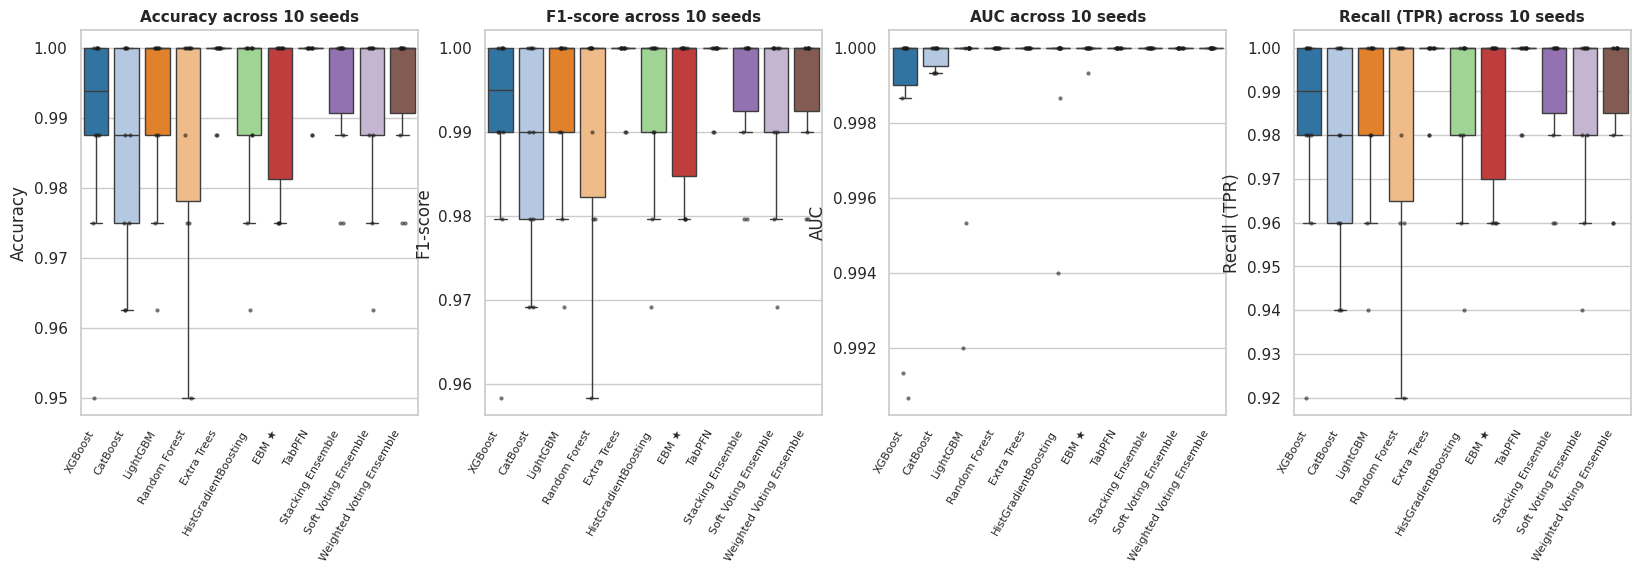

seed,42,7,21,63,99,123,256,512,777,2024
proposed model rank,10.0,1.0,4.0,4.0,5.0,1.0,7.0,1.0,11.0,2.0
best model on this seed,TabPFN,LightGBM,Stacking Ensemble,HistGradientBoosting,TabPFN,EBM,TabPFN,CatBoost,LightGBM,Stacking Ensemble


EBM: mean rank 4.60 | top-1 in 3/10 seeds | top-3 in 4/10 seeds


In [30]:
rob_rows = []
t_stage = time.time()
print(f"Repeating the full pipeline for {len(ROBUST_SEEDS)} random seeds ...")
for s in ROBUST_SEEDS:
    t_seed = time.time()
    set_global_seed(s)
    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X_all_raw, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=s)
    p_s = CKDPreprocessor(random_state=s).fit(Xtr_r, ytr_r)
    run_s = train_models(p_s.X_train_, p_s.y_train_, p_s.transform(Xte_r), seed=s, tune=True, verbose=False)
    for m in ALL_MODELS:
        rob_rows.append({"seed": s, "model": m, **compute_metrics(yte_r, run_s["proba"][m])})
    print(f"  seed {s:>5}: {len(p_s.selected_features_)} features | IF removed {int(p_s.train_if_flags_.sum())} | "
          f"{PROPOSED} AUC {compute_metrics(yte_r, run_s['proba'][PROPOSED])['AUC']:.4f} | {time.time() - t_seed:4.0f}s")
    del run_s
    gc.collect()
set_global_seed(RANDOM_STATE)
print(f"Robustness analysis finished in {(time.time() - t_stage) / 60:.1f} min")
rob_df = save_table(pd.DataFrame(rob_rows), "10_robustness_per_seed", index=False)


def t_ci(x, level=0.95):
    x = np.asarray(x, float)
    n = len(x)
    m, s = x.mean(), x.std(ddof=1) if n > 1 else 0.0
    h = stats.t.ppf(0.5 + level / 2, n - 1) * s / np.sqrt(n) if n > 1 else 0.0
    return m, s, m - h, m + h


ROB_METRICS = CORE8 + ["Kappa", "Brier"]
rob_summary_rows = []
for m in ALL_MODELS:
    row = {"model": m}
    for c in ROB_METRICS:
        mu, sd, lo, hi = t_ci(rob_df[rob_df.model == m][c])
        row[c] = f"{mu:.4f} ± {sd:.4f} [{lo:.4f}, {hi:.4f}]"
    rob_summary_rows.append(row)
rob_summary = save_table(pd.DataFrame(rob_summary_rows).set_index("model"), "10_robustness_summary")
print(f"Mean ± SD [95% CI] over {len(ROBUST_SEEDS)} seeds (hold-out test of each seed):")
display(rob_summary[["Accuracy", "Precision", "Recall (TPR)", "F1-score"]])
display(rob_summary[["FPR", "FNR", "TNR", "AUC", "Kappa", "Brier"]])

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
for ax, c in zip(axes, ["Accuracy", "F1-score", "AUC", "Recall (TPR)"]):
    sns.boxplot(data=rob_df, x="model", y=c, order=ALL_MODELS, ax=ax, palette=[MODEL_COLORS[m] for m in ALL_MODELS],
                showfliers=False)
    sns.stripplot(data=rob_df, x="model", y=c, order=ALL_MODELS, ax=ax, color="k", size=3, alpha=0.6)
    ax.set_xticklabels([label(m) for m in ALL_MODELS], rotation=60, ha="right", fontsize=8)
    ax.set_xlabel("")
    ax.set_title(f"{c} across {len(ROBUST_SEEDS)} seeds")
save_fig(fig, "10_robustness_boxplots")

# Stability of the proposed model's rank across seeds (performance criteria only)
rank_rows = []
for s in ROBUST_SEEDS:
    sub = rob_df[rob_df.seed == s].set_index("model")[METRICS].round(4)
    r = pd.DataFrame({c: sub[c].rank(ascending=not HIGHER_BETTER[c], method="average") for c in METRICS}).mean(axis=1)
    rank_rows.append({"seed": s, "proposed model rank": r.rank(method="min")[PROPOSED], "best model on this seed": r.idxmin()})
rank_df = pd.DataFrame(rank_rows).set_index("seed")
display(rank_df.T)
print(f"{PROPOSED}: mean rank {rank_df['proposed model rank'].mean():.2f} | top-1 in {int((rank_df['proposed model rank'] == 1).sum())}"
      f"/{len(ROBUST_SEEDS)} seeds | top-3 in {int((rank_df['proposed model rank'] <= 3).sum())}/{len(ROBUST_SEEDS)} seeds")

### 10.1 Supplementary robustness check — contribution of Isolation Forest and Boruta–SHAP (proposed model)
Using the same 10 CV folds, fold-specific imputation and fold-specific best hyperparameters, the proposed model is retrained
(a) **without** removing the Isolation-Forest-flagged training rows and (b) **without** Boruta–SHAP selection (all 24 features).

In [31]:
def fit_named_model(name, X, y, params, seed):
    y = np.asarray(y).astype(int)
    if name in BASE_MODELS:
        return make_model(name, params[name], seed).fit(X, y)
    fitted, oof = {}, {}
    for b in ACTIVE_BASE_MODELS:
        _, oof[b], _, _ = search_params(b, X, y, [params[b]], seed)
        fitted[b] = make_model(b, params[b], seed).fit(X, y)
    return build_ensembles(fitted, oof, y, seed)[0][name]


abl_rows = []
t_stage = time.time()
for f in cv_folds:
    pk, tr, te = f["prep"], f["train_idx"], f["test_idx"]
    y_tr_full = y_all.iloc[tr]
    X_tr_imp_full = pk.X_train_imputed_
    X_te_imp = pk.transform(X_all_raw.iloc[te], select=False)
    keep = ~pk.train_if_flags_.to_numpy()
    variants = {"full pipeline (IF + Boruta–SHAP)": None,
                "without Isolation-Forest row removal": (X_tr_imp_full[f["selected"]], y_tr_full, X_te_imp[f["selected"]]),
                "without Boruta–SHAP (all 24 features)": (X_tr_imp_full.loc[keep], y_tr_full.loc[keep], X_te_imp)}
    for v, data in variants.items():
        if data is None:
            p = cv_oof[PROPOSED][te]
        else:
            mdl = fit_named_model(PROPOSED, data[0], data[1], f["best_params"], f["seed"])
            p = mdl.predict_proba(data[2])[:, 1]
        abl_rows.append({"fold": f["fold"], "variant": v, **compute_metrics(y_all_np[te], p)})
abl_df = pd.DataFrame(abl_rows)
abl_sum = abl_df.groupby("variant")[["Accuracy", "F1-score", "Recall (TPR)", "AUC", "Brier"]].agg(["mean", "std"]).round(4)
ref = abl_df[abl_df.variant.str.startswith("full")].sort_values("fold")
for v in abl_df.variant.unique():
    if v.startswith("full"):
        continue
    cur = abl_df[abl_df.variant == v].sort_values("fold")
    for c in ["Accuracy", "AUC", "Brier"]:
        abl_sum.loc[v, (c, "p vs full (corrected t)")] = paired_t_tests(ref[c], cur[c], n_tr_cv, n_te_cv)["p (corrected)"]
save_table(abl_sum, "10_1_ablation_proposed")
print(f"Ablation for {PROPOSED} ({(time.time() - t_stage):.0f}s):")
display(abl_sum)

Ablation for EBM (138s):


Accuracy      F1-score      Recall (TPR)       AUC        Brier                        Accuracy                     AUC                   Brier
                                          mean  std     mean  std         mean  std mean  std    mean     std p vs full (corrected t) p vs full (corrected t) p vs full (corrected t)
variant                                                                                                                                                                              
full pipeline (IF + Boruta–SHAP)           1.0  0.0      1.0  0.0          1.0  0.0  1.0  0.0  0.0001  0.0001                     NaN                     NaN                     NaN
without Boruta–SHAP (all 24 features)      1.0  0.0      1.0  0.0          1.0  0.0  1.0  0.0  0.0001  0.0001                     1.0                     1.0                0.834960
without Isolation-Forest row removal       1.0  0.0      1.0  0.0          1.0  0.0  1.0  0.0  0.0001  0.0002                     1.0                     1.0                0.521855

## 11. Cost analysis — cost matrix with False : Correct classification cost = 5 : 1
| | Predicted Non-CKD | Predicted CKD |
|---|---|---|
| **Actual Non-CKD** | TN → cost 1 (correct) | FP → cost 5 (false) |
| **Actual CKD** | FN → cost 5 (false) | TP → cost 1 (correct) |

Total cost $=1\cdot(TP+TN)+5\cdot(FP+FN)$; the average cost per patient ranges from 1 (perfect) to 5 (all wrong).
The Bayes-optimal threshold for this matrix is $t^*=\frac{C_{FP}-C_{TN}}{(C_{FP}-C_{TN})+(C_{FN}-C_{TP})}=\frac{4}{8}=0.5$,
so the default threshold is already cost-optimal. Models are compared with the trivial *treat-all* (everyone CKD) and
*treat-none* strategies.

,Predicted Non-CKD,Predicted CKD
Actual Non-CKD,1.0,5.0
Actual CKD,5.0,1.0


Bayes-optimal decision threshold t* = 0.50
Reference strategies: treat-all 2.500/patient, treat-none 3.500/patient, perfect 1.000/patient


,FP,FN,"total cost (CV, n=400)",cost / patient (CV),cost / patient per fold (mean ± SD),excess over perfect (CV),saving vs treat-all (%),saving vs treat-none (%),"cost / patient (hold-out, n=80)"
model,,,,,,,,,
EBM,0,0,400.0,1.00,1.0000 ± 0.0000,0.00,60.0,71.4286,1.0
Stacking Ensemble,0,0,400.0,1.00,1.0000 ± 0.0000,0.00,60.0,71.4286,1.0
Extra Trees,0,2,408.0,1.02,1.0200 ± 0.0422,0.02,59.2,70.8571,1.0
Random Forest,0,2,408.0,1.02,1.0200 ± 0.0632,0.02,59.2,70.8571,1.0
Weighted Voting Ensemble,0,2,408.0,1.02,1.0200 ± 0.0422,0.02,59.2,70.8571,1.0
TabPFN,0,2,408.0,1.02,1.0200 ± 0.0422,0.02,59.2,70.8571,1.0
XGBoost,0,3,412.0,1.03,1.0300 ± 0.0483,0.03,58.8,70.5714,1.0
Soft Voting Ensemble,0,3,412.0,1.03,1.0300 ± 0.0483,0.03,58.8,70.5714,1.0
LightGBM,0,4,416.0,1.04,1.0400 ± 0.0516,0.04,58.4,70.2857,1.0


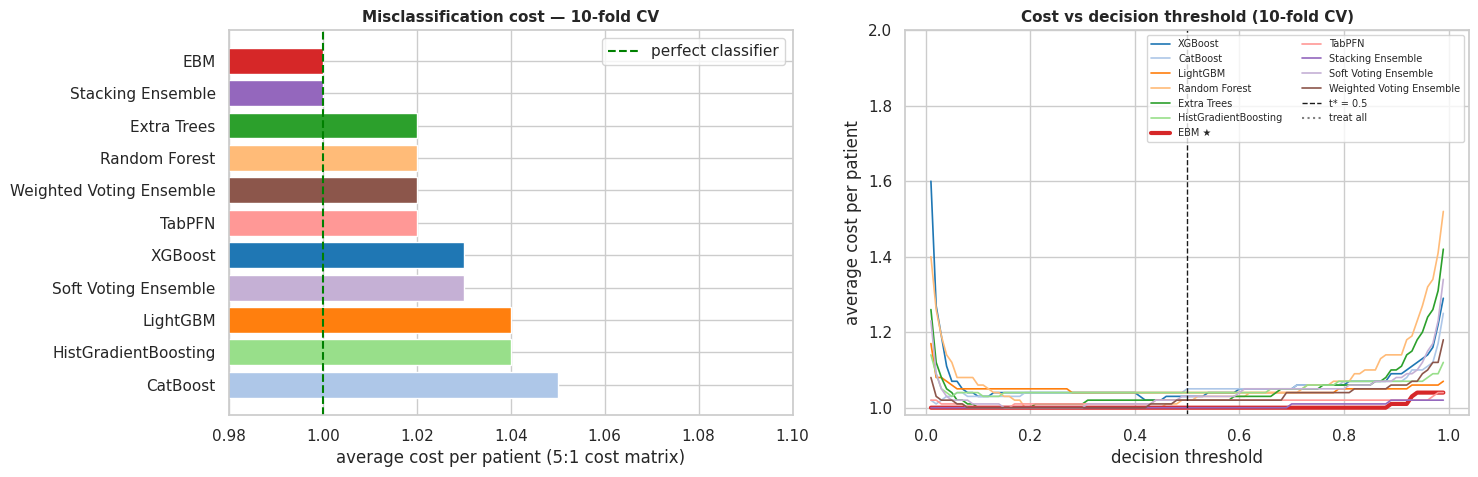

In [32]:
COST_MATRIX = pd.DataFrame([[COST_CORRECT, COST_FALSE], [COST_FALSE, COST_CORRECT]],
                           index=["Actual Non-CKD", "Actual CKD"], columns=["Predicted Non-CKD", "Predicted CKD"])
display(COST_MATRIX)
T_STAR = (COST_FALSE - COST_CORRECT) / ((COST_FALSE - COST_CORRECT) + (COST_FALSE - COST_CORRECT))
print(f"Bayes-optimal decision threshold t* = {T_STAR:.2f}")


def cost_summary(y, p):
    mt = compute_metrics(y, p)
    total = COST_CORRECT * (mt["TP"] + mt["TN"]) + COST_FALSE * (mt["FP"] + mt["FN"])
    return total, total / len(y), mt["FP"], mt["FN"]


n1, n0 = int(y_all_np.sum()), int((1 - y_all_np).sum())
treat_all_cost = (COST_CORRECT * n1 + COST_FALSE * n0) / len(y_all_np)
treat_none_cost = (COST_CORRECT * n0 + COST_FALSE * n1) / len(y_all_np)
cost_rows = []
for m in ALL_MODELS:
    tot, per, fp, fn = cost_summary(y_all_np, cv_oof[m])
    tot_h, per_h, _, _ = cost_summary(y_test.to_numpy(), tuned_run["proba"][m])
    fold_costs = cv_df[cv_df.model == m]["Cost"]
    cost_rows.append({"model": m, "FP": fp, "FN": fn, "total cost (CV, n=400)": tot, "cost / patient (CV)": per,
                      "cost / patient per fold (mean ± SD)": f"{fold_costs.mean():.4f} ± {fold_costs.std(ddof=1):.4f}",
                      "excess over perfect (CV)": per - COST_CORRECT,
                      "saving vs treat-all (%)": 100 * (treat_all_cost - per) / treat_all_cost,
                      "saving vs treat-none (%)": 100 * (treat_none_cost - per) / treat_none_cost,
                      "cost / patient (hold-out, n=80)": per_h})
cost_df = save_table(pd.DataFrame(cost_rows).set_index("model").sort_values("cost / patient (CV)"), "11_cost_analysis")
print(f"Reference strategies: treat-all {treat_all_cost:.3f}/patient, treat-none {treat_none_cost:.3f}/patient, perfect {COST_CORRECT:.3f}/patient")
display(cost_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cd = cost_df["cost / patient (CV)"]
axes[0].barh(cd.index, cd.values, color=[MODEL_COLORS[m] for m in cd.index])
axes[0].axvline(COST_CORRECT, color="green", ls="--", label="perfect classifier")
axes[0].set_xlim(COST_CORRECT * 0.98, max(cd.max() * 1.02, COST_CORRECT + 0.1))
axes[0].invert_yaxis()
axes[0].set_xlabel("average cost per patient (5:1 cost matrix)")
axes[0].set_title("Misclassification cost — 10-fold CV")
axes[0].legend()
ths = np.linspace(0.01, 0.99, 99)
for m in ALL_MODELS:
    cs = []
    for t in ths:
        yhat = (cv_oof[m] >= t).astype(int)
        err = int((yhat != y_all_np).sum())
        cs.append((COST_CORRECT * (len(y_all_np) - err) + COST_FALSE * err) / len(y_all_np))
    axes[1].plot(ths, cs, color=MODEL_COLORS[m], lw=3 if m == PROPOSED else 1.2, label=label(m))
axes[1].axvline(T_STAR, color="k", ls="--", lw=1, label="t* = 0.5")
axes[1].axhline(treat_all_cost, color="grey", ls=":", label="treat all")
axes[1].set_ylim(COST_CORRECT * 0.98, min(treat_all_cost, 2.0))
axes[1].set_xlabel("decision threshold")
axes[1].set_ylabel("average cost per patient")
axes[1].set_title("Cost vs decision threshold (10-fold CV)")
axes[1].legend(fontsize=7, ncol=2)
save_fig(fig, "11_cost_analysis")

## 12. Uncertainty quantification — 95% confidence intervals
Three complementary 95% intervals are reported:
* **Stratified bootstrap** ($B$ = `N_BOOTSTRAP` resamples, class proportions preserved) on the pooled 10-fold CV predictions (n = 400);
* **Stratified bootstrap** on the single hold-out test set (n = 80) — wider, as expected for a small test set;
* **t-interval over the 10 CV folds** (fold-to-fold variability).

Bootstrap finished in 11s
Point estimate [95% bootstrap CI] — pooled 10-fold CV predictions (n = 400):


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC
XGBoost,"0.9925 [0.9825, 1.0000]","1.0000 [1.0000, 1.0000]","0.9880 [0.9720, 1.0000]","0.9940 [0.9858, 1.0000]","0.0000 [0.0000, 0.0000]","0.0120 [0.0000, 0.0280]","1.0000 [1.0000, 1.0000]","0.9986 [0.9956, 1.0000]"
CatBoost,"0.9875 [0.9750, 0.9975]","1.0000 [1.0000, 1.0000]","0.9800 [0.9600, 0.9960]","0.9899 [0.9796, 0.9980]","0.0000 [0.0000, 0.0000]","0.0200 [0.0040, 0.0400]","1.0000 [1.0000, 1.0000]","0.9999 [0.9996, 1.0000]"
LightGBM,"0.9900 [0.9800, 0.9975]","1.0000 [1.0000, 1.0000]","0.9840 [0.9680, 0.9960]","0.9919 [0.9837, 0.9980]","0.0000 [0.0000, 0.0000]","0.0160 [0.0040, 0.0320]","1.0000 [1.0000, 1.0000]","0.9970 [0.9933, 0.9997]"
Random Forest,"0.9950 [0.9875, 1.0000]","1.0000 [1.0000, 1.0000]","0.9920 [0.9800, 1.0000]","0.9960 [0.9899, 1.0000]","0.0000 [0.0000, 0.0000]","0.0080 [0.0000, 0.0200]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Extra Trees,"0.9950 [0.9875, 1.0000]","1.0000 [1.0000, 1.0000]","0.9920 [0.9800, 1.0000]","0.9960 [0.9899, 1.0000]","0.0000 [0.0000, 0.0000]","0.0080 [0.0000, 0.0200]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
HistGradientBoosting,"0.9900 [0.9800, 0.9975]","1.0000 [1.0000, 1.0000]","0.9840 [0.9680, 0.9960]","0.9919 [0.9837, 0.9980]","0.0000 [0.0000, 0.0000]","0.0160 [0.0040, 0.0320]","1.0000 [1.0000, 1.0000]","0.9987 [0.9962, 1.0000]"
EBM,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
TabPFN,"0.9950 [0.9875, 1.0000]","1.0000 [1.0000, 1.0000]","0.9920 [0.9800, 1.0000]","0.9960 [0.9899, 1.0000]","0.0000 [0.0000, 0.0000]","0.0080 [0.0000, 0.0200]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Stacking Ensemble,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Soft Voting Ensemble,"0.9925 [0.9825, 1.0000]","1.0000 [1.0000, 1.0000]","0.9880 [0.9720, 1.0000]","0.9940 [0.9858, 1.0000]","0.0000 [0.0000, 0.0000]","0.0120 [0.0000, 0.0280]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"


,Kappa,Brier,Cost
XGBoost,"0.9841 [0.9630, 1.0000]","0.0075 [0.0021, 0.0145]","1.0300 [1.0000, 1.0700]"
CatBoost,"0.9735 [0.9474, 0.9947]","0.0097 [0.0023, 0.0194]","1.0500 [1.0100, 1.1000]"
LightGBM,"0.9788 [0.9578, 0.9947]","0.0103 [0.0026, 0.0203]","1.0400 [1.0100, 1.0800]"
Random Forest,"0.9894 [0.9735, 1.0000]","0.0040 [0.0019, 0.0067]","1.0200 [1.0000, 1.0500]"
Extra Trees,"0.9894 [0.9735, 1.0000]","0.0044 [0.0010, 0.0091]","1.0200 [1.0000, 1.0500]"
HistGradientBoosting,"0.9788 [0.9578, 0.9947]","0.0097 [0.0023, 0.0191]","1.0400 [1.0100, 1.0800]"
EBM,"1.0000 [1.0000, 1.0000]","0.0001 [0.0000, 0.0002]","1.0000 [1.0000, 1.0000]"
TabPFN,"0.9894 [0.9735, 1.0000]","0.0026 [0.0000, 0.0069]","1.0200 [1.0000, 1.0500]"
Stacking Ensemble,"1.0000 [1.0000, 1.0000]","0.0003 [0.0000, 0.0008]","1.0000 [1.0000, 1.0000]"
Soft Voting Ensemble,"0.9841 [0.9630, 1.0000]","0.0038 [0.0010, 0.0075]","1.0300 [1.0000, 1.0700]"


Point estimate [95% bootstrap CI] — hold-out test set (n = 80):


,Accuracy,Precision,Recall (TPR),F1-score,FPR,FNR,TNR,AUC
XGBoost,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
CatBoost,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
LightGBM,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Random Forest,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Extra Trees,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
HistGradientBoosting,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
EBM,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
TabPFN,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Stacking Ensemble,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"
Soft Voting Ensemble,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0000 [0.0000, 0.0000]","0.0000 [0.0000, 0.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]"


Mean [95% t-CI] over the 10 CV folds:


,Accuracy,F1-score,AUC,Recall (TPR),Brier
XGBoost,"0.9925 [0.9839, 1.0011]","0.9939 [0.9868, 1.0009]","0.9995 [0.9983, 1.0007]","0.9880 [0.9742, 1.0018]","0.0075 [0.0005, 0.0144]"
CatBoost,"0.9875 [0.9701, 1.0049]","0.9895 [0.9748, 1.0043]","1.0000 [1.0000, 1.0000]","0.9800 [0.9522, 1.0078]","0.0097 [-0.0018, 0.0212]"
LightGBM,"0.9900 [0.9808, 0.9992]","0.9918 [0.9843, 0.9994]","1.0000 [1.0000, 1.0000]","0.9840 [0.9692, 0.9988]","0.0103 [0.0013, 0.0192]"
Random Forest,"0.9950 [0.9837, 1.0063]","0.9958 [0.9864, 1.0053]","1.0000 [1.0000, 1.0000]","0.9920 [0.9739, 1.0101]","0.0040 [0.0006, 0.0074]"
Extra Trees,"0.9950 [0.9875, 1.0025]","0.9959 [0.9898, 1.0021]","1.0000 [1.0000, 1.0000]","0.9920 [0.9799, 1.0041]","0.0044 [-0.0007, 0.0094]"
HistGradientBoosting,"0.9900 [0.9808, 0.9992]","0.9918 [0.9843, 0.9994]","1.0000 [1.0000, 1.0000]","0.9840 [0.9692, 0.9988]","0.0097 [0.0010, 0.0183]"
EBM,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0001 [-0.0000, 0.0001]"
TabPFN,"0.9950 [0.9875, 1.0025]","0.9959 [0.9898, 1.0021]","1.0000 [1.0000, 1.0000]","0.9920 [0.9799, 1.0041]","0.0026 [-0.0016, 0.0067]"
Stacking Ensemble,"1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","1.0000 [1.0000, 1.0000]","0.0003 [-0.0003, 0.0008]"
Soft Voting Ensemble,"0.9925 [0.9839, 1.0011]","0.9939 [0.9868, 1.0009]","1.0000 [1.0000, 1.0000]","0.9880 [0.9742, 1.0018]","0.0038 [0.0001, 0.0076]"


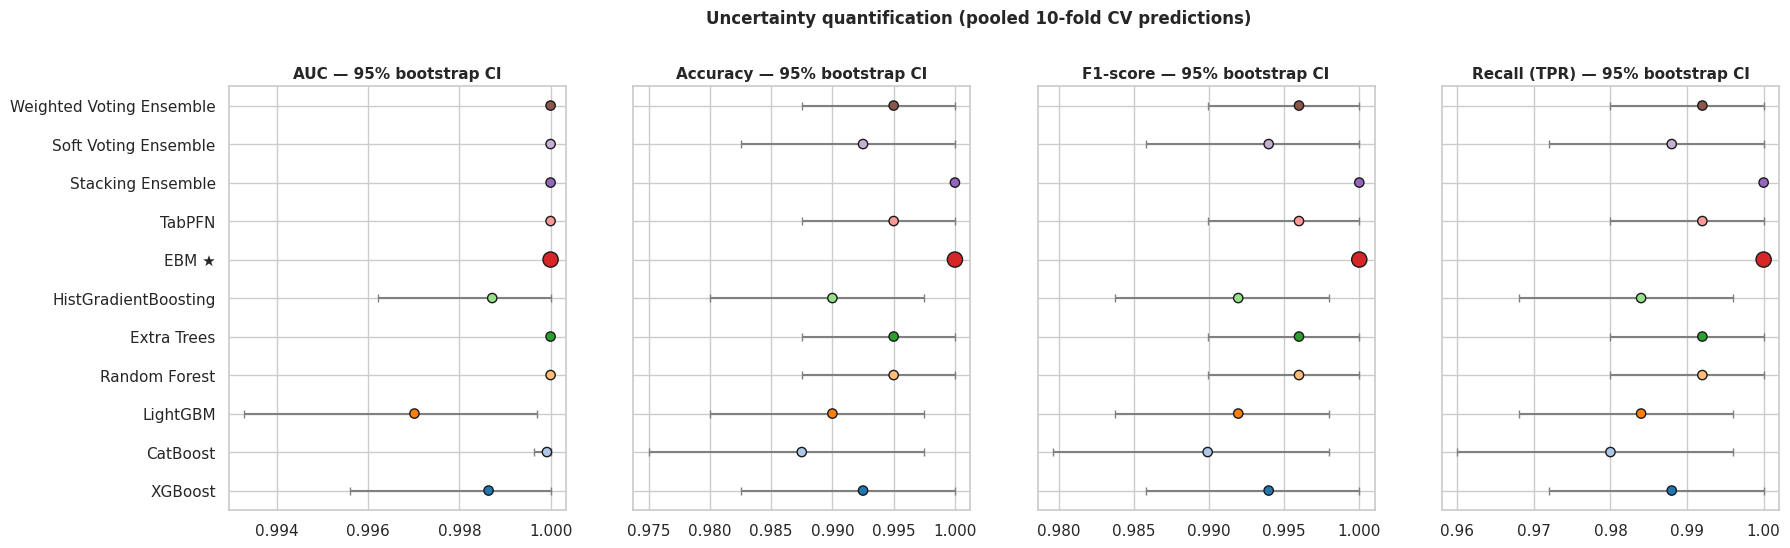

In [33]:
def fast_metrics(y, p, thr=DECISION_THRESHOLD):
    """Vectorised version of compute_metrics used inside the bootstrap (identical definitions)."""
    yhat = (p >= thr).astype(int)
    tp = int(np.sum((yhat == 1) & (y == 1)))
    tn = int(np.sum((yhat == 0) & (y == 0)))
    fp = int(np.sum((yhat == 1) & (y == 0)))
    fn = int(np.sum((yhat == 0) & (y == 1)))
    n, n1_, n0_ = len(y), tp + fn, tn + fp
    div = lambda a, b: a / b if b > 0 else 0.0
    prec, rec = div(tp, tp + fp), div(tp, tp + fn)
    ranks = stats.rankdata(p)
    auc = (ranks[y == 1].sum() - n1_ * (n1_ + 1) / 2) / (n1_ * n0_) if n1_ and n0_ else np.nan
    po = (tp + tn) / n
    pe = ((tp + fp) * (tp + fn) + (tn + fn) * (tn + fp)) / n ** 2
    return {"Accuracy": po, "Precision": prec, "Recall (TPR)": rec, "F1-score": div(2 * prec * rec, prec + rec),
            "FPR": div(fp, fp + tn), "FNR": div(fn, fn + tp), "TNR": div(tn, tn + fp), "AUC": auc,
            "Kappa": (po - pe) / (1 - pe) if pe < 1 else np.nan, "Brier": float(np.mean((p - y) ** 2)),
            "Cost": cost_per_patient(tp, tn, fp, fn)}


_chk_a, _chk_b = fast_metrics(y_all_np, cv_oof[PROPOSED]), compute_metrics(y_all_np, cv_oof[PROPOSED])
assert all(np.isclose(_chk_a[c], _chk_b[c], equal_nan=True) for c in METRICS)


def bootstrap_ci(y, p, B=N_BOOTSTRAP, seed=RANDOM_STATE):
    y, p = np.asarray(y).astype(int), np.asarray(p, float)
    rng = np.random.default_rng(seed)
    i1, i0 = np.where(y == 1)[0], np.where(y == 0)[0]
    boots = []
    for _ in range(B):
        s = np.concatenate([rng.choice(i1, len(i1)), rng.choice(i0, len(i0))])
        boots.append(fast_metrics(y[s], p[s]))
    bd = pd.DataFrame(boots)
    point = fast_metrics(y, p)
    return pd.DataFrame({"estimate": pd.Series(point), "CI low": bd.quantile(0.025), "CI high": bd.quantile(0.975),
                         "bootstrap SE": bd.std(ddof=1)}).loc[METRICS]


t_stage = time.time()
ci_cv = {m: bootstrap_ci(y_all_np, cv_oof[m]) for m in ALL_MODELS}
ci_ho = {m: bootstrap_ci(y_test.to_numpy(), tuned_run["proba"][m]) for m in ALL_MODELS}
print(f"Bootstrap finished in {time.time() - t_stage:.0f}s")


def ci_string_table(ci):
    return pd.DataFrame({m: {c: f"{ci[m].at[c, 'estimate']:.4f} [{ci[m].at[c, 'CI low']:.4f}, {ci[m].at[c, 'CI high']:.4f}]"
                             for c in METRICS} for m in ALL_MODELS}).T


pd.concat({m: ci_cv[m] for m in ALL_MODELS}).to_csv(TAB_DIR / "12_bootstrap_ci_cv.csv")
pd.concat({m: ci_ho[m] for m in ALL_MODELS}).to_csv(TAB_DIR / "12_bootstrap_ci_holdout.csv")
print("Point estimate [95% bootstrap CI] — pooled 10-fold CV predictions (n = 400):")
display(ci_string_table(ci_cv)[CORE8])
display(ci_string_table(ci_cv)[["Kappa", "Brier", "Cost"]])
print("Point estimate [95% bootstrap CI] — hold-out test set (n = 80):")
display(ci_string_table(ci_ho)[CORE8])

fold_ci = pd.DataFrame({m: {c: "{:.4f} [{:.4f}, {:.4f}]".format(*[t_ci(cv_df[cv_df.model == m][c])[i] for i in (0, 2, 3)])
                            for c in ["Accuracy", "F1-score", "AUC", "Recall (TPR)", "Brier"]} for m in ALL_MODELS}).T
save_table(fold_ci, "12_fold_t_ci")
print(f"Mean [95% t-CI] over the {OUTER_CV_FOLDS} CV folds:")
display(fold_ci)

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), sharey=True)
ypos = np.arange(len(ALL_MODELS))
for ax, c in zip(axes, ["AUC", "Accuracy", "F1-score", "Recall (TPR)"]):
    est = np.array([ci_cv[m].at[c, "estimate"] for m in ALL_MODELS])
    lo = np.array([ci_cv[m].at[c, "CI low"] for m in ALL_MODELS])
    hi = np.array([ci_cv[m].at[c, "CI high"] for m in ALL_MODELS])
    ax.errorbar(est, ypos, xerr=[est - lo, hi - est], fmt="none", ecolor="grey", capsize=3)
    ax.scatter(est, ypos, c=[MODEL_COLORS[m] for m in ALL_MODELS], s=[120 if m == PROPOSED else 45 for m in ALL_MODELS],
               zorder=3, edgecolors="k")
    ax.set_title(f"{c} — 95% bootstrap CI")
    ax.set_yticks(ypos)
    ax.set_yticklabels([label(m) for m in ALL_MODELS])
    ax.invert_yaxis()
fig.suptitle("Uncertainty quantification (pooled 10-fold CV predictions)", fontweight="bold", y=1.02)
save_fig(fig, "12_forest_plot_ci")

## 13. Surrogate decision trees for every model (including the proposed model)
A global surrogate is a shallow decision tree (depth = `SURROGATE_DEPTH`) trained to **mimic each model's predictions** on the training
data. *Fidelity* = agreement between surrogate and model on the unseen test set. The tree shows how the top splitting features partition
a subset of the patients into regions dominated by CKD or Non-CKD predictions; the caption blanks are filled automatically from each tree.

,fidelity train,fidelity test,surrogate accuracy vs truth (test),feature 1,feature 2,subset,total,dominant classes
model,,,,,,,,
XGBoost,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
CatBoost,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
LightGBM,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
Random Forest,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
Extra Trees,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
HistGradientBoosting,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
EBM,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
TabPFN,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD
Stacking Ensemble,0.9967,1.0,1.0,hemo,pcv,160,304,Non-CKD and CKD


* **XGBoost** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **CatBoost** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **LightGBM** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **Random Forest** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **Extra Trees** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **HistGradientBoosting** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **EBM ★** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **TabPFN** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **Stacking Ensemble** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **Soft Voting Ensemble** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.
* **Weighted Voting Ensemble** (fidelity 100.0%): The features **hemo** (Hemoglobin) and **pcv** (Packed cell volume) partition a subset of **160 of 304 training patients** into regions dominated by **Non-CKD and CKD** classes.

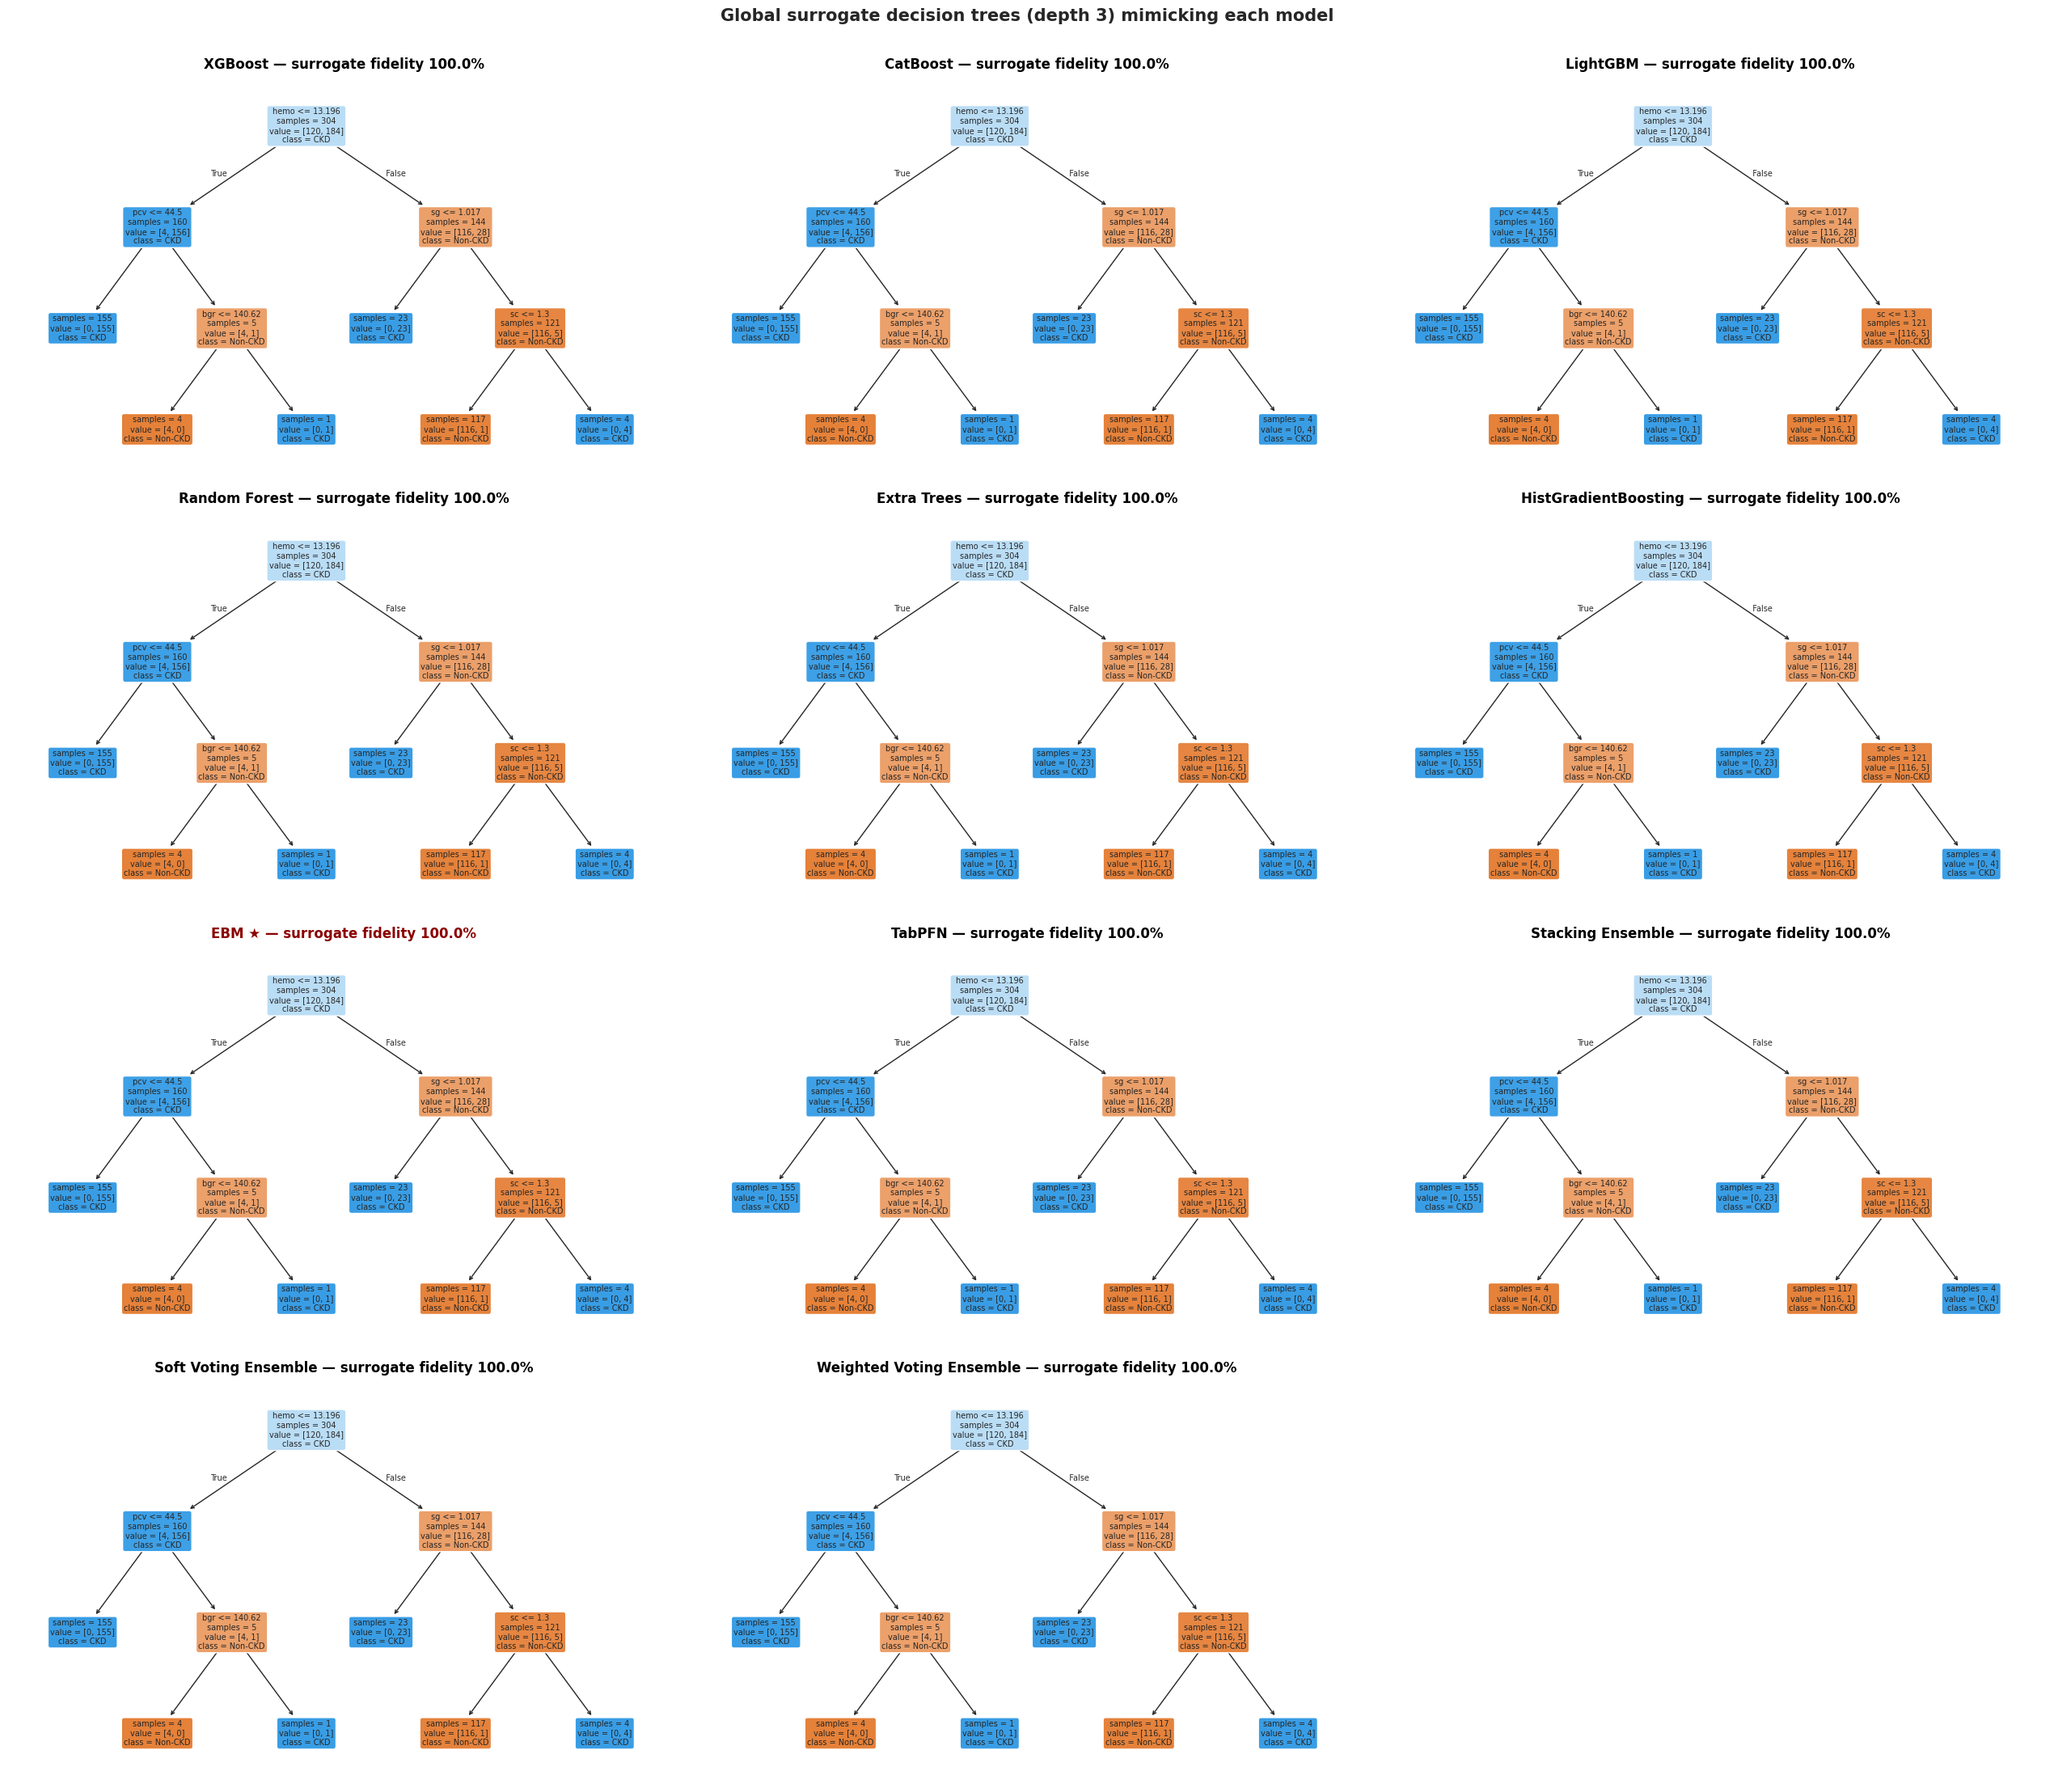

Text version of the proposed model's surrogate (EBM):
|--- hemo <= 13.20
|   |--- pcv <= 44.50
|   |   |--- class: 1
|   |--- pcv >  44.50
|   |   |--- bgr <= 140.62
|   |   |   |--- class: 0
|   |   |--- bgr >  140.62
|   |   |   |--- class: 1
|--- hemo >  13.20
|   |--- sg <= 1.02
|   |   |--- class: 1
|   |--- sg >  1.02
|   |   |--- sc <= 1.30
|   |   |   |--- class: 0
|   |   |--- sc >  1.30
|   |   |   |--- class: 1



In [34]:
def model_labels(model, X):
    return (model.predict_proba(X)[:, 1] >= DECISION_THRESHOLD).astype(int)


def subtree_leaves(t, node):
    if t.children_left[node] == -1:
        return [node]
    return subtree_leaves(t, t.children_left[node]) + subtree_leaves(t, t.children_right[node])


def surrogate_caption(tree, feats):
    t = tree.tree_
    N = int(t.n_node_samples[0])
    if t.feature[0] < 0:
        return {"feature 1": "—", "feature 2": "—", "subset": N, "total": N, "dominant classes": CLASS_NAMES[int(np.argmax(t.value[0]))]}
    f1 = feats[t.feature[0]]
    kids = [c for c in (t.children_left[0], t.children_right[0]) if t.feature[c] >= 0]
    node = max(kids, key=lambda c: t.n_node_samples[c]) if kids else 0
    f2 = feats[t.feature[node]] if kids else f1
    leaves = subtree_leaves(t, node)
    dom = sorted({CLASS_NAMES[int(np.argmax(t.value[l]))] for l in leaves}, key=CLASS_NAMES.index)
    return {"feature 1": f1, "feature 2": f2, "subset": int(t.n_node_samples[node]), "total": N,
            "dominant classes": " and ".join(dom)}


sur_rows, surrogates = [], {}
for m in ALL_MODELS:
    mdl = tuned_run["models"][m]
    yhat_tr, yhat_te = model_labels(mdl, X_train_sel), model_labels(mdl, X_test_sel)
    tree = DecisionTreeClassifier(max_depth=SURROGATE_DEPTH, random_state=RANDOM_STATE).fit(X_train_sel, yhat_tr)
    surrogates[m] = tree
    cap = surrogate_caption(tree, SELECTED_FEATURES)
    sur_rows.append({"model": m, "fidelity train": accuracy_score(yhat_tr, tree.predict(X_train_sel)),
                     "fidelity test": accuracy_score(yhat_te, tree.predict(X_test_sel)),
                     "surrogate accuracy vs truth (test)": accuracy_score(y_test, tree.predict(X_test_sel)),
                     **cap,
                     "caption": (f"The features **{cap['feature 1']}** ({FEATURE_LABELS.get(cap['feature 1'], '')}) and "
                                 f"**{cap['feature 2']}** ({FEATURE_LABELS.get(cap['feature 2'], '')}) partition a subset of "
                                 f"**{cap['subset']} of {cap['total']} training patients** into regions dominated by "
                                 f"**{cap['dominant classes']}** classes.")})
sur_df = save_table(pd.DataFrame(sur_rows).set_index("model"), "13_surrogate_trees")
display(sur_df.drop(columns="caption").round(4))
display(Markdown("\n".join(f"* **{label(m)}** (fidelity {sur_df.at[m, 'fidelity test']:.1%}): {sur_df.at[m, 'caption']}"
                           for m in ALL_MODELS)))

ncols = 3
nrows = math.ceil(len(ALL_MODELS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8.5 * ncols, 5.5 * nrows))
axes = axes.ravel()
for ax, m in zip(axes, ALL_MODELS):
    plot_tree(surrogates[m], feature_names=SELECTED_FEATURES, class_names=CLASS_NAMES, filled=True, rounded=True,
              impurity=False, fontsize=7, ax=ax)
    ax.set_title(f"{label(m)} — surrogate fidelity {sur_df.at[m, 'fidelity test']:.1%}",
                 color="darkred" if m == PROPOSED else "black", fontsize=12)
for ax in axes[len(ALL_MODELS):]:
    ax.axis("off")
fig.suptitle("Global surrogate decision trees (depth 3) mimicking each model", fontweight="bold", fontsize=15, y=1.005)
fig.tight_layout()
save_fig(fig, "13_surrogate_trees")
print(f"Text version of the proposed model's surrogate ({PROPOSED}):")
print(export_text(surrogates[PROPOSED], feature_names=SELECTED_FEATURES))

### 13.1 Two-feature decision regions
Using the two features that open the **proposed model's** surrogate tree, a depth-3 surrogate restricted to those two features is fitted
for every model and its decision regions are drawn (red = CKD region, green = Non-CKD region; points = training patients coloured by
the model's own prediction).

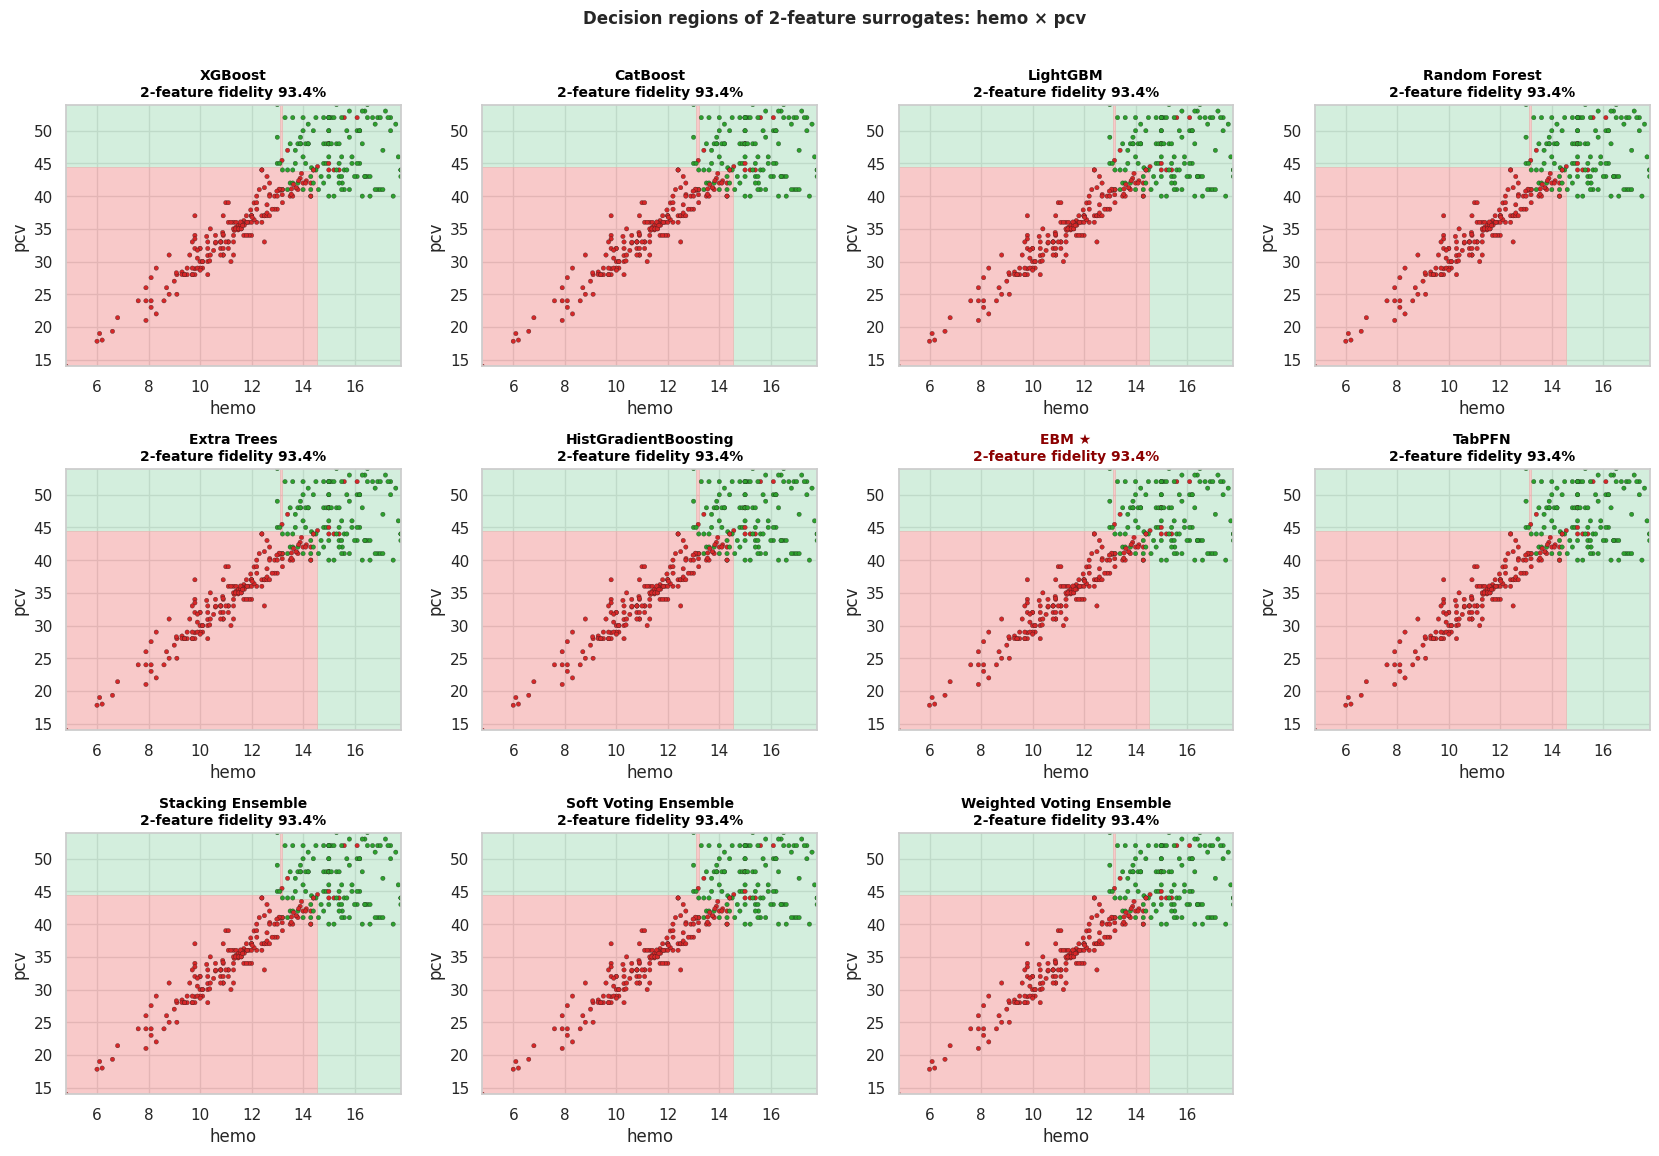

In [35]:
F1_2D = sur_df.at[PROPOSED, "feature 1"]
F2_2D = sur_df.at[PROPOSED, "feature 2"]
if F2_2D == F1_2D or F2_2D == "—":
    imp_ = pd.Series(surrogates[PROPOSED].feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=False)
    F1_2D, F2_2D = imp_.index[0], imp_.index[1]
xx, yy = np.meshgrid(np.linspace(X_train_sel[F1_2D].min(), X_train_sel[F1_2D].max(), 300),
                     np.linspace(X_train_sel[F2_2D].min(), X_train_sel[F2_2D].max(), 300))
fig, axes = grid_axes(len(ALL_MODELS), ncols=4, w=4.2, h=3.8)
for ax, m in zip(axes, ALL_MODELS):
    yhat_tr = model_labels(tuned_run["models"][m], X_train_sel)
    t2 = DecisionTreeClassifier(max_depth=SURROGATE_DEPTH, random_state=RANDOM_STATE).fit(X_train_sel[[F1_2D, F2_2D]], yhat_tr)
    Zg = t2.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[F1_2D, F2_2D])).reshape(xx.shape)
    ax.contourf(xx, yy, Zg, levels=[-0.5, 0.5, 1.5], colors=["#b7e4c7", "#f4a6a6"], alpha=0.6)
    ax.scatter(X_train_sel[F1_2D], X_train_sel[F2_2D], c=np.where(yhat_tr == 1, "tab:red", "tab:green"), s=10,
               edgecolors="k", linewidths=0.2)
    fid = accuracy_score(yhat_tr, t2.predict(X_train_sel[[F1_2D, F2_2D]]))
    ax.set_title(f"{label(m)}\n2-feature fidelity {fid:.1%}", color="darkred" if m == PROPOSED else "black", fontsize=10)
    ax.set_xlabel(F1_2D)
    ax.set_ylabel(F2_2D)
fig.suptitle(f"Decision regions of 2-feature surrogates: {F1_2D} × {F2_2D}", fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "13_1_surrogate_decision_regions")

## 14. Explainability of the proposed model
The proposed model **as fitted on the training split** is explained on the **hold-out test patients**. SHAP values are computed with the
model-agnostic Permutation explainer on the predicted CKD **probability**, so the same method works whether the proposed model is a
single learner or an ensemble; SHAP values are therefore in probability units and sum (with the base value) to each patient's P(CKD).
### 14.1 Hierarchical explainability — global → class-wise (cohort) → local SHAP

SHAP values for 80 test patients × 20 features in 4s
Local accuracy check: max |Σφ + base − P(CKD)| = 1.22e-15


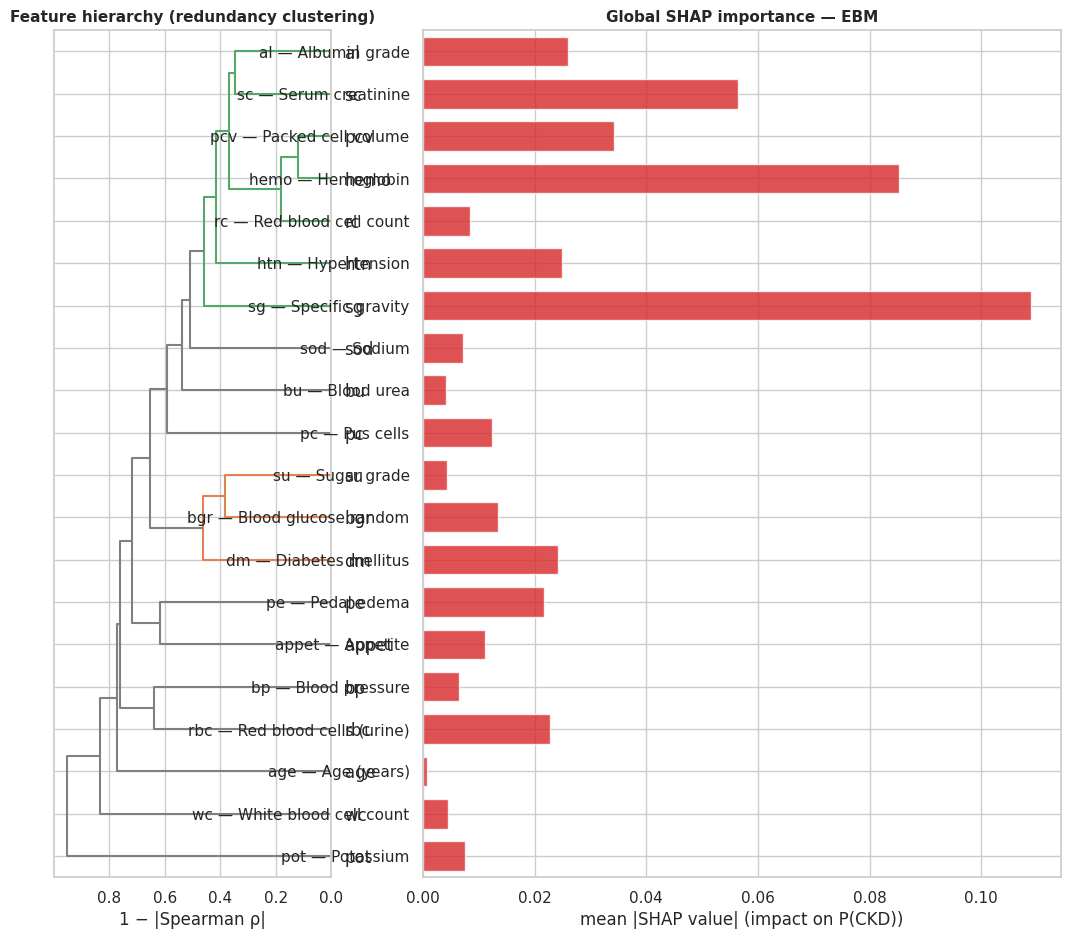

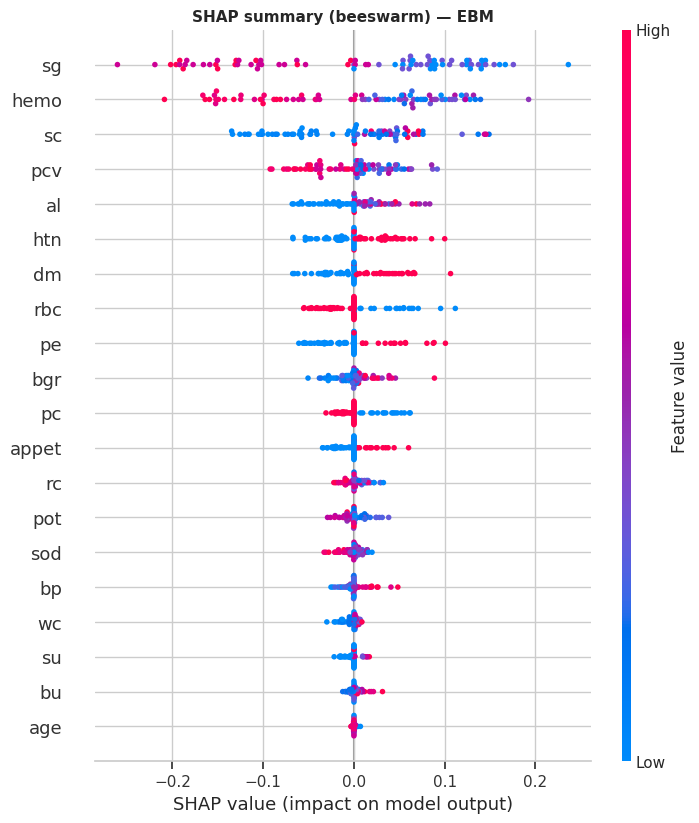

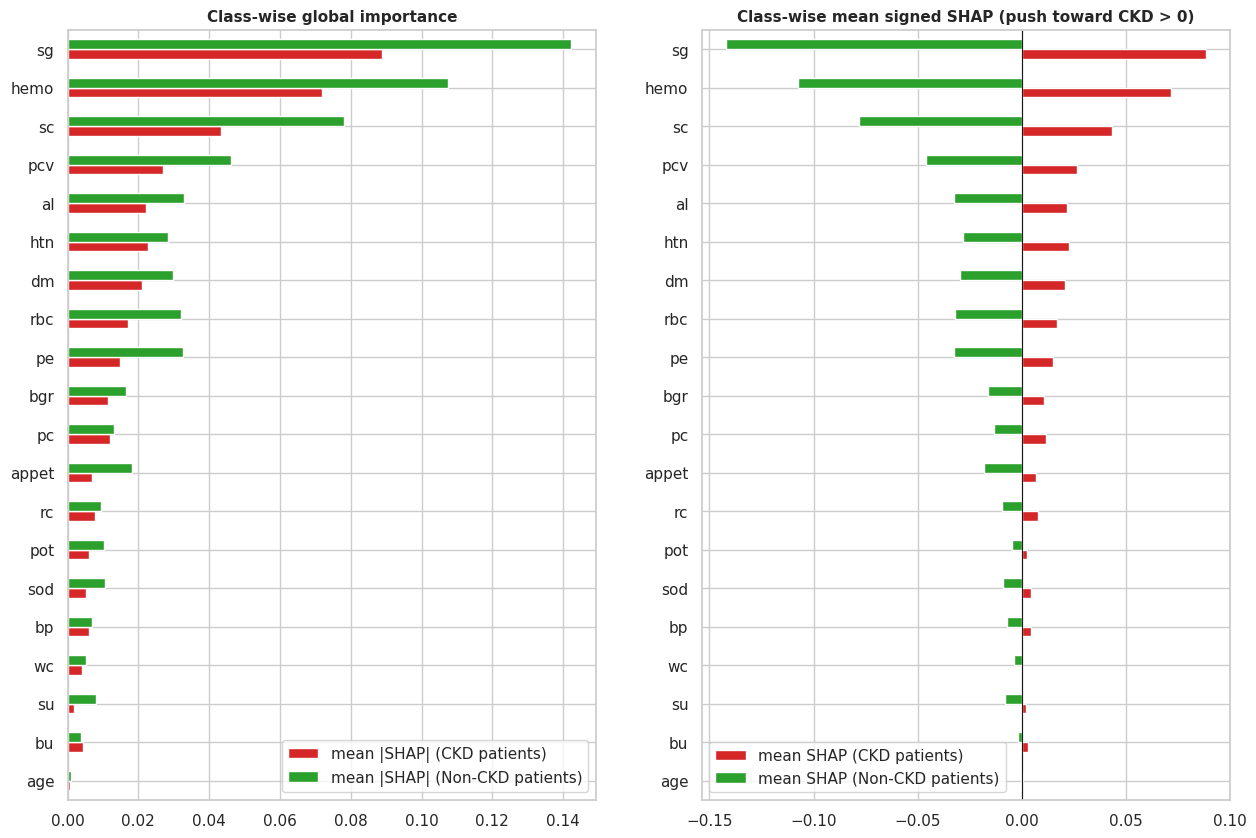

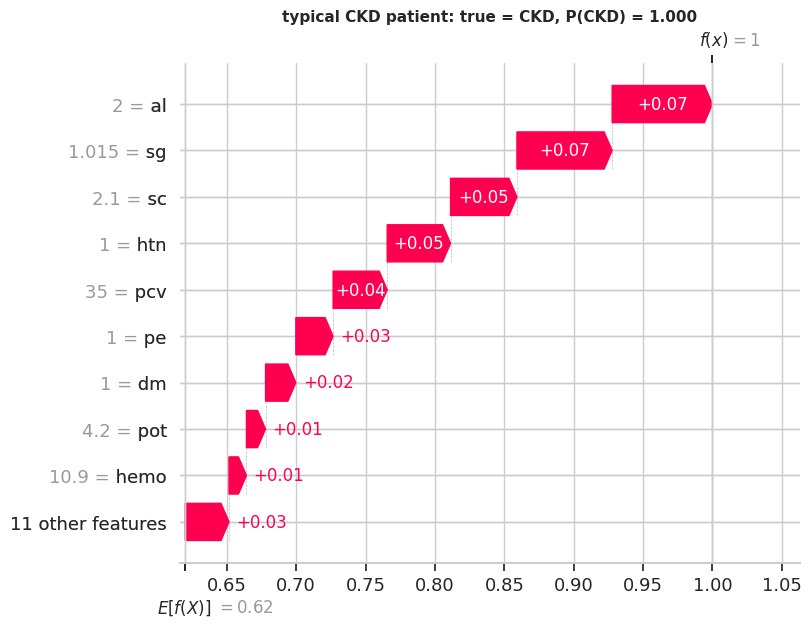

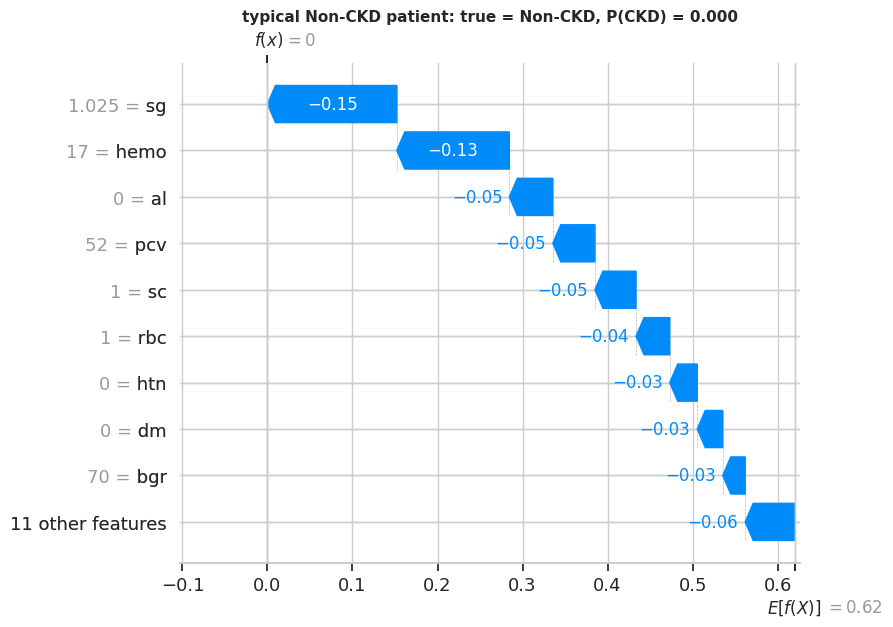

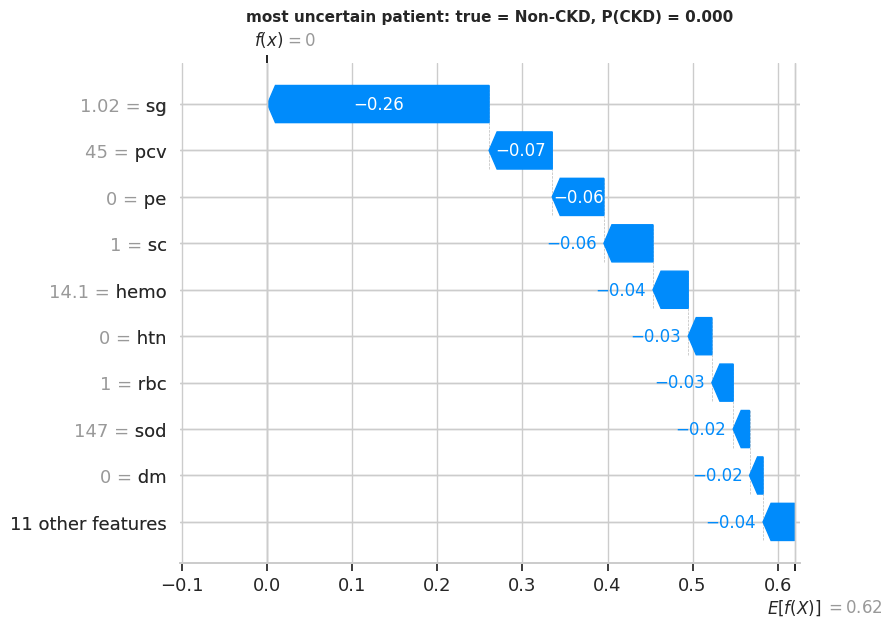

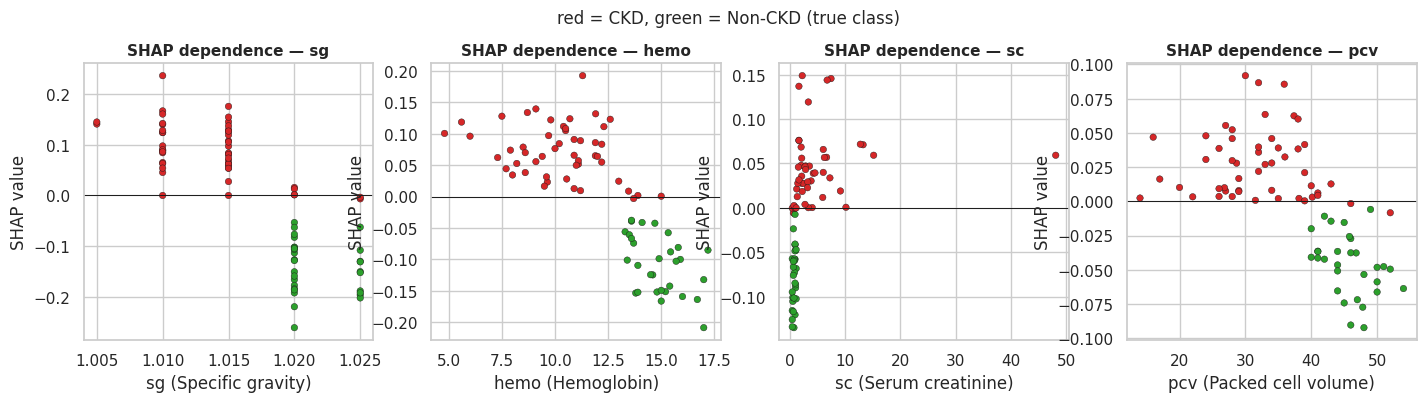

In [36]:
FEATS = SELECTED_FEATURES
P_FEATS = len(FEATS)


def proba_proposed(A):
    return PROPOSED_MODEL.predict_proba(pd.DataFrame(np.asarray(A, float), columns=FEATS))[:, 1]


shap_bg = X_train_sel.sample(n=min(SHAP_BACKGROUND, len(X_train_sel)), random_state=RANDOM_STATE)
explainer = shap.PermutationExplainer(proba_proposed, shap.maskers.Independent(shap_bg.to_numpy(float), max_samples=len(shap_bg)),
                                      seed=RANDOM_STATE)
t0 = time.time()
_sv = explainer(X_test_sel.to_numpy(float), max_evals=3 * (2 * P_FEATS + 1), silent=True)
shap_exp = shap.Explanation(values=np.asarray(_sv.values), base_values=np.asarray(_sv.base_values),
                            data=X_test_sel.to_numpy(float), feature_names=FEATS)
print(f"SHAP values for {len(X_test_sel)} test patients × {P_FEATS} features in {time.time() - t0:.0f}s")
gap = np.abs(shap_exp.values.sum(axis=1) + shap_exp.base_values - proba_proposed(X_test_sel)).max()
print(f"Local accuracy check: max |Σφ + base − P(CKD)| = {gap:.2e}")
shap_df = pd.DataFrame(shap_exp.values, columns=FEATS, index=X_test_sel.index)
shap_df.to_csv(TAB_DIR / "14_shap_values_test.csv")
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Level 1 — global importance with hierarchical clustering of (redundant) features
corr = np.array(X_train_sel.corr(method="spearman").fillna(0).to_numpy(), dtype=float, copy=True)
np.fill_diagonal(corr, 1.0)
dist = np.clip(1 - np.abs(corr), 0, None)
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0)
link = sch.linkage(squareform(dist, checks=False), method="average")
fig, (ax_d, ax_b) = plt.subplots(1, 2, figsize=(13, 0.45 * P_FEATS + 2), gridspec_kw={"width_ratios": [1, 2.3]})
dn = sch.dendrogram(link, orientation="left", labels=FEATS, ax=ax_d, color_threshold=0.5, above_threshold_color="grey")
leaves = dn["ivl"]
ypos = 10 * np.arange(len(leaves)) + 5
ax_b.barh(ypos, mean_abs_shap[leaves].to_numpy(), height=7, color="tab:red", alpha=0.8)
ax_b.set_yticks(ypos)
ax_b.set_yticklabels([f"{f} — {FEATURE_LABELS.get(f, f)}" for f in leaves])
ax_b.set_ylim(ax_d.get_ylim())
ax_b.set_xlabel("mean |SHAP value| (impact on P(CKD))")
ax_d.set_xlabel("1 − |Spearman ρ|")
ax_d.set_title("Feature hierarchy (redundancy clustering)")
ax_b.set_title(f"Global SHAP importance — {PROPOSED}")
save_fig(fig, "14_1_shap_global_hierarchical")

plt.figure()
shap.plots.beeswarm(shap_exp, max_display=P_FEATS, show=False)
plt.title(f"SHAP summary (beeswarm) — {PROPOSED}", fontweight="bold")
save_fig(plt.gcf(), "14_1_shap_beeswarm")

# Level 2 — class-wise (cohort) SHAP
cls_tab = pd.DataFrame({"mean |SHAP| (CKD patients)": shap_df[y_test == 1].abs().mean(),
                        "mean |SHAP| (Non-CKD patients)": shap_df[y_test == 0].abs().mean(),
                        "mean SHAP (CKD patients)": shap_df[y_test == 1].mean(),
                        "mean SHAP (Non-CKD patients)": shap_df[y_test == 0].mean()}).loc[mean_abs_shap.index]
save_table(cls_tab.round(5), "14_1_shap_classwise")
fig, axes = plt.subplots(1, 2, figsize=(15, 0.4 * P_FEATS + 2))
cls_tab[["mean |SHAP| (CKD patients)", "mean |SHAP| (Non-CKD patients)"]].iloc[::-1].plot.barh(ax=axes[0], color=["tab:red", "tab:green"])
axes[0].set_title("Class-wise global importance")
cls_tab[["mean SHAP (CKD patients)", "mean SHAP (Non-CKD patients)"]].iloc[::-1].plot.barh(ax=axes[1], color=["tab:red", "tab:green"])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Class-wise mean signed SHAP (push toward CKD > 0)")
save_fig(fig, "14_1_shap_classwise")

# Level 3 — local explanations of representative patients
p_test_prop = proba_proposed(X_test_sel)
yt = y_test.to_numpy()
pred_t = (p_test_prop >= DECISION_THRESHOLD).astype(int)
pos = np.where((yt == 1) & (pred_t == 1))[0]
neg = np.where((yt == 0) & (pred_t == 0))[0]
REP = {"typical CKD patient": int(pos[np.argmax(p_test_prop[pos])]) if len(pos) else int(np.argmax(p_test_prop)),
       "typical Non-CKD patient": int(neg[np.argmin(p_test_prop[neg])]) if len(neg) else int(np.argmin(p_test_prop)),
       "most uncertain patient": int(np.argmin(np.abs(p_test_prop - 0.5)))}
for name, i in REP.items():
    plt.figure()
    shap.plots.waterfall(shap_exp[i], max_display=10, show=False)
    plt.title(f"{name}: true = {CLASS_NAMES[yt[i]]}, P(CKD) = {p_test_prop[i]:.3f}", fontweight="bold")
    save_fig(plt.gcf(), f"14_1_shap_waterfall_{name.split()[0]}_{name.split()[1]}")

top4 = list(mean_abs_shap.index[:4])
fig, axes = plt.subplots(1, len(top4), figsize=(4.3 * len(top4), 3.6))
for ax, f in zip(np.atleast_1d(axes), top4):
    ax.scatter(X_test_sel[f], shap_df[f], c=np.where(yt == 1, "tab:red", "tab:green"), s=22, edgecolors="k", linewidths=0.3)
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel(f"{f} ({FEATURE_LABELS.get(f, f)})")
    ax.set_ylabel("SHAP value")
    ax.set_title(f"SHAP dependence — {f}")
fig.suptitle("red = CKD, green = Non-CKD (true class)", y=1.03)
save_fig(fig, "14_1_shap_dependence")

### 14.2 Class-wise local LIME explanations
LIME fits a sparse local linear surrogate around one patient using perturbed samples drawn from the training distribution
(categorical features are perturbed as categories). Each representative patient is explained **for its own class**, followed by
class-wise aggregation over `LIME_PER_CLASS` test patients of each class.

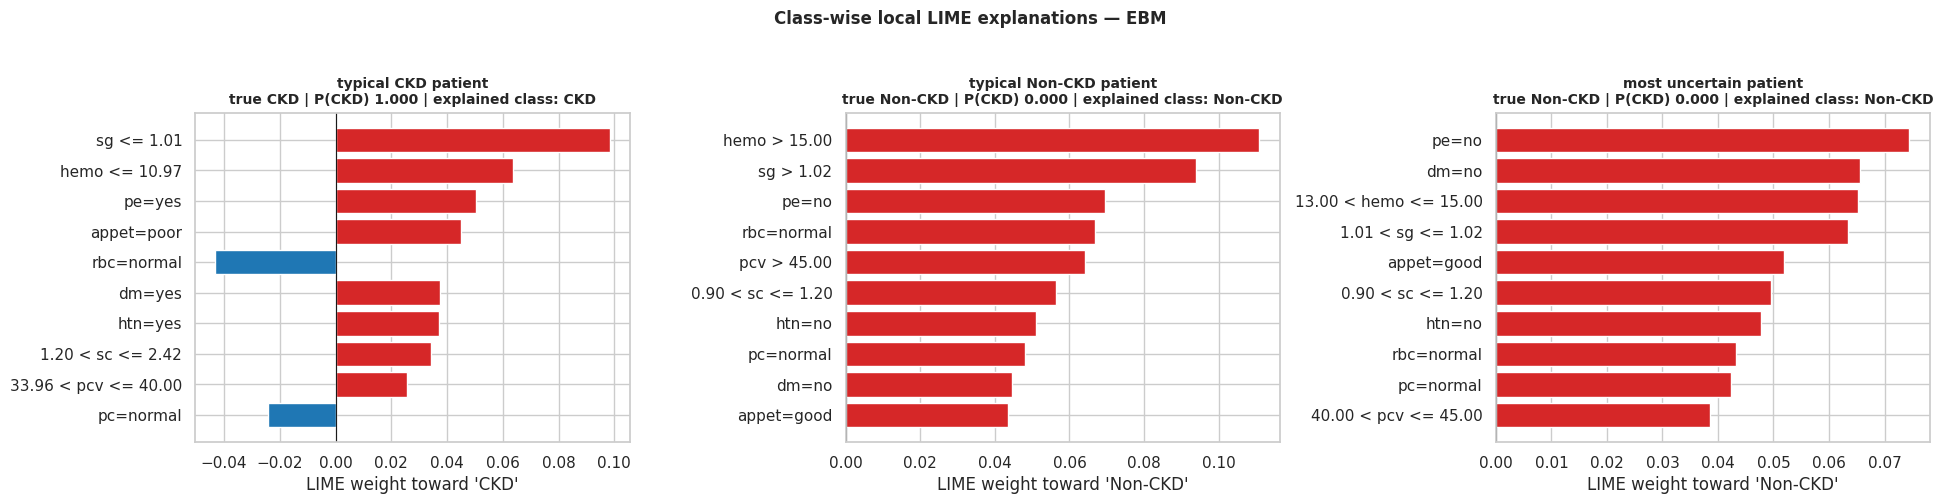

,patient,explained class,condition,weight
0,typical CKD patient,CKD,sg <= 1.01,0.0984
1,typical CKD patient,CKD,hemo <= 10.97,0.0637
2,typical CKD patient,CKD,pe=yes,0.0505
3,typical CKD patient,CKD,appet=poor,0.0448
4,typical CKD patient,CKD,rbc=normal,-0.0432
5,typical CKD patient,CKD,dm=yes,0.0375
6,typical CKD patient,CKD,htn=yes,0.0371
7,typical CKD patient,CKD,1.20 < sc <= 2.42,0.0342
8,typical CKD patient,CKD,33.96 < pcv <= 40.00,0.0257
9,typical CKD patient,CKD,pc=normal,-0.0243


Class-wise LIME aggregation over 20 CKD and 20 Non-CKD test patients (1s)


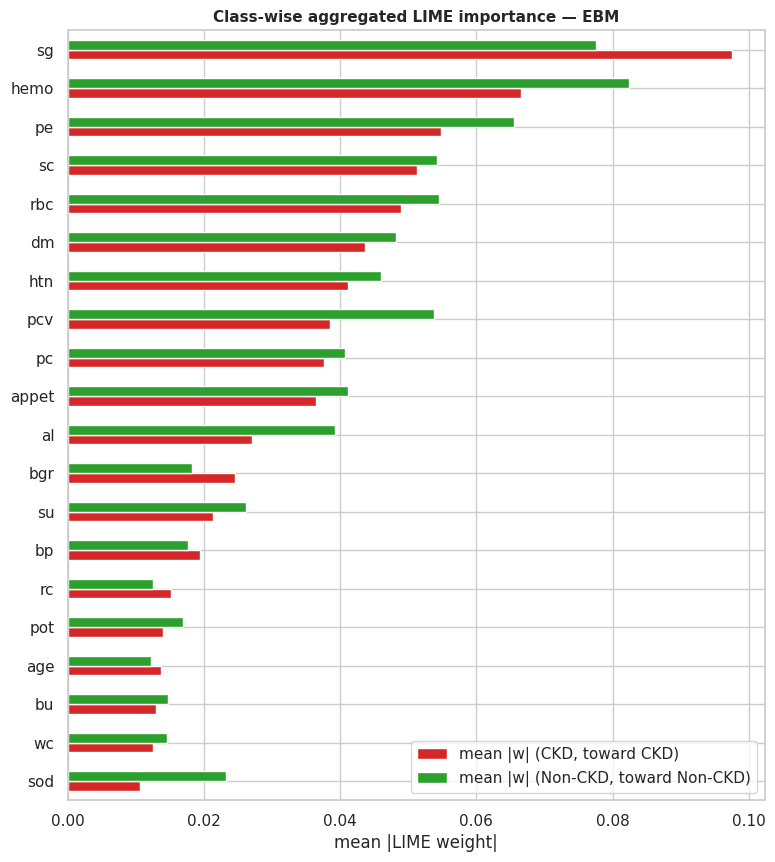

In [37]:
cat_idx = [i for i, f in enumerate(FEATS) if f in CATEGORICAL_COLS]
cat_names = {i: list(prep.encoder_.encoders_[f].classes_) for i, f in enumerate(FEATS) if f in CATEGORICAL_COLS}
lime_explainer = LimeTabularExplainer(X_train_sel.to_numpy(float), mode="classification", feature_names=FEATS,
                                      class_names=CLASS_NAMES, categorical_features=cat_idx, categorical_names=cat_names,
                                      discretize_continuous=True, random_state=RANDOM_STATE)


def lime_predict(A):
    return PROPOSED_MODEL.predict_proba(pd.DataFrame(np.asarray(A, float), columns=FEATS))


N_LIME_FEATS = min(10, P_FEATS)
fig, axes = plt.subplots(1, len(REP), figsize=(6.5 * len(REP), 4.8))
lime_local_rows = []
for ax, (name, i) in zip(np.atleast_1d(axes), REP.items()):
    target = int(pred_t[i]) if name == "most uncertain patient" else int(yt[i])
    exp = lime_explainer.explain_instance(X_test_sel.to_numpy(float)[i], lime_predict, num_features=N_LIME_FEATS,
                                          labels=(target,), num_samples=LIME_SAMPLES)
    items = exp.as_list(label=target)[::-1]
    ax.barh([t for t, _ in items], [w for _, w in items], color=["tab:red" if w > 0 else "tab:blue" for _, w in items])
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{name}\ntrue {CLASS_NAMES[yt[i]]} | P(CKD) {p_test_prop[i]:.3f} | explained class: {CLASS_NAMES[target]}",
                 fontsize=10)
    ax.set_xlabel(f"LIME weight toward '{CLASS_NAMES[target]}'")
    for cond, w in exp.as_list(label=target):
        lime_local_rows.append({"patient": name, "explained class": CLASS_NAMES[target], "condition": cond, "weight": w})
fig.suptitle(f"Class-wise local LIME explanations — {PROPOSED}", fontweight="bold", y=1.04)
fig.tight_layout()
save_fig(fig, "14_2_lime_local")
display(save_table(pd.DataFrame(lime_local_rows), "14_2_lime_local", index=False).round(4))

# Class-wise aggregation (each patient explained toward its own true class)
rng_l = np.random.default_rng(RANDOM_STATE)
agg = {c: [] for c in (0, 1)}
t0 = time.time()
for c in (0, 1):
    idx = np.where(yt == c)[0]
    for i in rng_l.choice(idx, size=min(LIME_PER_CLASS, len(idx)), replace=False):
        exp = lime_explainer.explain_instance(X_test_sel.to_numpy(float)[i], lime_predict, num_features=P_FEATS,
                                              labels=(c,), num_samples=max(500, LIME_SAMPLES // 2))
        w = np.zeros(P_FEATS)
        for j, val in exp.as_map()[c]:
            w[j] = val
        agg[c].append(w)
lime_cls = pd.DataFrame({"mean |w| (CKD, toward CKD)": np.abs(agg[1]).mean(axis=0),
                         "mean |w| (Non-CKD, toward Non-CKD)": np.abs(agg[0]).mean(axis=0),
                         "mean w (CKD, toward CKD)": np.mean(agg[1], axis=0),
                         "mean w (Non-CKD, toward Non-CKD)": np.mean(agg[0], axis=0)}, index=FEATS)
lime_cls = lime_cls.sort_values("mean |w| (CKD, toward CKD)", ascending=False)
save_table(lime_cls.round(5), "14_2_lime_classwise")
print(f"Class-wise LIME aggregation over {len(agg[1])} CKD and {len(agg[0])} Non-CKD test patients ({time.time() - t0:.0f}s)")
fig, ax = plt.subplots(figsize=(9, 0.4 * P_FEATS + 2))
lime_cls[["mean |w| (CKD, toward CKD)", "mean |w| (Non-CKD, toward Non-CKD)"]].iloc[::-1].plot.barh(ax=ax, color=["tab:red", "tab:green"])
ax.set_title(f"Class-wise aggregated LIME importance — {PROPOSED}")
ax.set_xlabel("mean |LIME weight|")
save_fig(fig, "14_2_lime_classwise")

## 15. Interpretability through global sensitivity and permutation analysis
### 15.1 Morris global sensitivity analysis (elementary effects) of the proposed model
Each feature is varied one-at-a-time along `MORRIS_TRAJECTORIES` random trajectories over its training range (`MORRIS_LEVELS`-level grid).
The elementary effect of feature *i* is the change in P(CKD) per unit (normalised) step. The table reports the **mean elementary effect
(μ)**, the **absolute mean effect (μ\*)** — overall influence, the **standard deviation of the elementary effects (σ)** — non-linearity
and/or interactions, and the **95% bootstrap confidence estimate for μ\***. Binary categorical features are rounded to 0/1 before
prediction (with 4 levels each step flips the category exactly).

Morris design: 2100 model evaluations (100 trajectories × 21 points)


,clinical name,μ (mean elementary effect),μ* (absolute mean effect),σ (SD of elementary effects),μ* 95% confidence (±)
feature,,,,,
rbc,Red blood cells (urine),-0.0035,0.0035,0.0335,0.0067
pc,Pus cells,-0.0033,0.0033,0.0330,0.0067
sg,Specific gravity,-0.0001,0.0001,0.0009,0.0002
al,Albumin grade,0.0001,0.0001,0.0007,0.0001
appet,Appetite,0.0001,0.0001,0.0006,0.0001
hemo,Hemoglobin,-0.0000,0.0000,0.0002,0.0000
pe,Pedal edema,0.0000,0.0000,0.0002,0.0000
pot,Potassium,-0.0000,0.0000,0.0002,0.0000
bgr,Blood glucose random,0.0000,0.0000,0.0002,0.0000


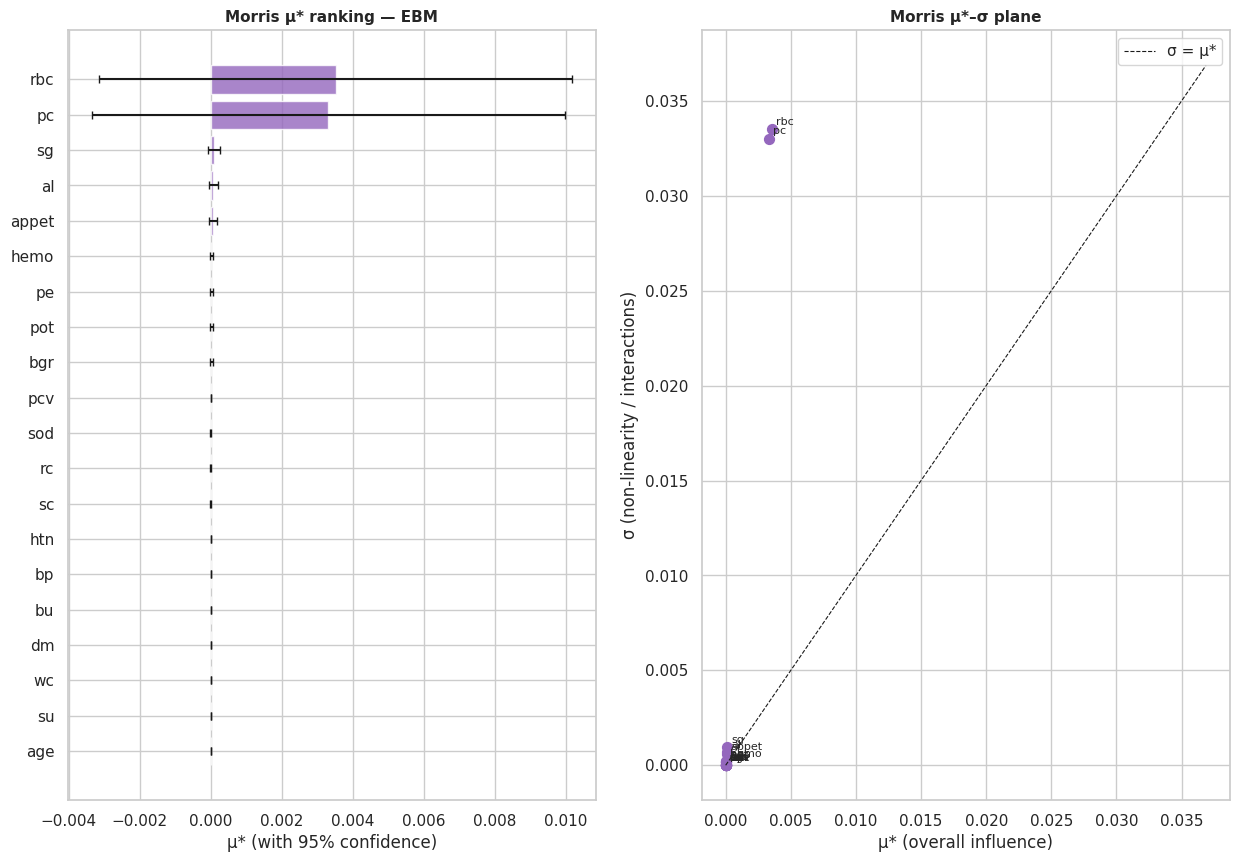

In [38]:
bounds = []
for f in FEATS:
    lo, hi = float(X_train_sel[f].min()), float(X_train_sel[f].max())
    bounds.append([lo, hi if hi > lo else lo + 1e-6])
morris_problem = {"num_vars": P_FEATS, "names": FEATS, "bounds": bounds}
X_morris = morris_sample.sample(morris_problem, N=MORRIS_TRAJECTORIES, num_levels=MORRIS_LEVELS, seed=RANDOM_STATE)
X_eval = X_morris.copy()
for j, f in enumerate(FEATS):
    if f in CATEGORICAL_COLS:
        X_eval[:, j] = np.round(X_eval[:, j])
Y_morris = proba_proposed(X_eval)
Si = morris_analyze.analyze(morris_problem, X_morris, Y_morris, num_levels=MORRIS_LEVELS, conf_level=0.95,
                            num_resamples=1000, print_to_console=False, seed=RANDOM_STATE)
morris_df = pd.DataFrame({"feature": FEATS, "clinical name": [FEATURE_LABELS.get(f, f) for f in FEATS],
                          "μ (mean elementary effect)": np.asarray(Si["mu"]),
                          "μ* (absolute mean effect)": np.asarray(Si["mu_star"]),
                          "σ (SD of elementary effects)": np.asarray(Si["sigma"]),
                          "μ* 95% confidence (±)": np.asarray(Si["mu_star_conf"])}).set_index("feature")
morris_df = morris_df.sort_values("μ* (absolute mean effect)", ascending=False)
save_table(morris_df.round(5), "15_1_morris_sensitivity")
print(f"Morris design: {X_morris.shape[0]} model evaluations ({MORRIS_TRAJECTORIES} trajectories × {P_FEATS + 1} points)")
display(morris_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 0.35 * P_FEATS + 3))
md = morris_df.iloc[::-1]
axes[0].barh(md.index, md["μ* (absolute mean effect)"], xerr=md["μ* 95% confidence (±)"], color="tab:purple", alpha=0.8, capsize=3)
axes[0].set_xlabel("μ* (with 95% confidence)")
axes[0].set_title(f"Morris μ* ranking — {PROPOSED}")
axes[1].scatter(morris_df["μ* (absolute mean effect)"], morris_df["σ (SD of elementary effects)"], s=50, color="tab:purple")
for f, r in morris_df.iterrows():
    axes[1].annotate(f, (r["μ* (absolute mean effect)"], r["σ (SD of elementary effects)"]), fontsize=8,
                     xytext=(3, 3), textcoords="offset points")
lim = max(morris_df["μ* (absolute mean effect)"].max(), morris_df["σ (SD of elementary effects)"].max()) * 1.1 + 1e-9
axes[1].plot([0, lim], [0, lim], "k--", lw=0.8, label="σ = μ*")
axes[1].set_xlabel("μ* (overall influence)")
axes[1].set_ylabel("σ (non-linearity / interactions)")
axes[1].set_title("Morris μ*–σ plane")
axes[1].legend()
save_fig(fig, "15_1_morris")

### 15.2 Permutation importance of the proposed model
Each feature of the hold-out test set is randomly shuffled `PERM_REPEATS` times; importance = **reduction in model performance** after
shuffling (drop in AUC, drop in accuracy, increase in Brier score). Because test AUC is often near 1.0, the Brier score is the most
sensitive of the three.

Permutation importance (30 repeats) computed in 2s


,AUC drop (mean),AUC drop (SD),Accuracy drop (mean),Accuracy drop (SD),Brier increase (mean),Brier increase (SD)
sg,0.002,0.0023,0.1354,0.0285,0.0964,0.0205
hemo,0.000,0.0000,0.0433,0.0167,0.0301,0.0087
sc,0.000,0.0000,0.0083,0.0087,0.0060,0.0032
pe,0.000,0.0000,0.0000,0.0000,0.0024,0.0013
pcv,0.000,0.0000,0.0000,0.0000,0.0002,0.0002
rbc,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
dm,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
al,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
htn,0.000,0.0000,0.0000,0.0000,0.0000,0.0000
appet,0.000,0.0000,0.0000,0.0000,0.0000,0.0000


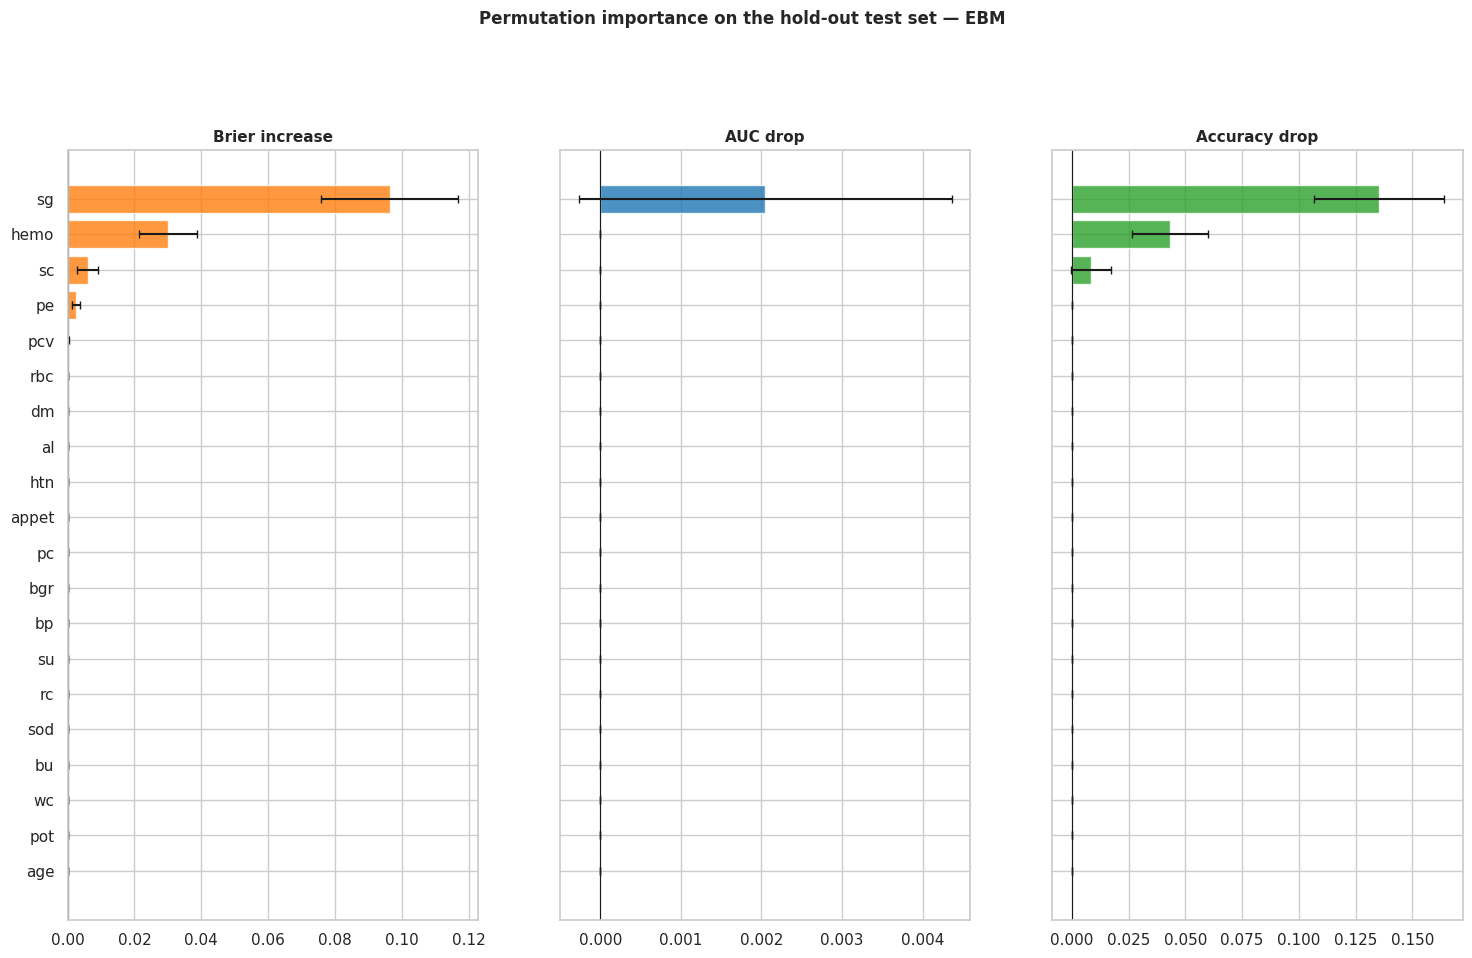

In [39]:
def _p1(est, X):
    return est.predict_proba(X)[:, 1]


SCORERS = {"AUC": lambda est, X, y: roc_auc_score(y, _p1(est, X)),
           "Accuracy": lambda est, X, y: accuracy_score(y, (_p1(est, X) >= DECISION_THRESHOLD).astype(int)),
           "neg Brier": lambda est, X, y: -brier_score_loss(y, _p1(est, X))}
t0 = time.time()
perm = permutation_importance(PROPOSED_MODEL, X_test_sel, y_test.to_numpy(), scoring=SCORERS, n_repeats=PERM_REPEATS,
                              random_state=RANDOM_STATE, n_jobs=1)
perm_df = pd.DataFrame({"AUC drop (mean)": perm["AUC"].importances_mean, "AUC drop (SD)": perm["AUC"].importances_std,
                        "Accuracy drop (mean)": perm["Accuracy"].importances_mean,
                        "Accuracy drop (SD)": perm["Accuracy"].importances_std,
                        "Brier increase (mean)": perm["neg Brier"].importances_mean,
                        "Brier increase (SD)": perm["neg Brier"].importances_std}, index=FEATS)
perm_df = perm_df.sort_values(["Brier increase (mean)", "AUC drop (mean)"], ascending=False)
save_table(perm_df.round(5), "15_2_permutation_importance")
print(f"Permutation importance ({PERM_REPEATS} repeats) computed in {time.time() - t0:.0f}s")
display(perm_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 0.35 * P_FEATS + 3), sharey=True)
pdx = perm_df.iloc[::-1]
for ax, (mcol, scol, col) in zip(axes, [("Brier increase (mean)", "Brier increase (SD)", "tab:orange"),
                                        ("AUC drop (mean)", "AUC drop (SD)", "tab:blue"),
                                        ("Accuracy drop (mean)", "Accuracy drop (SD)", "tab:green")]):
    ax.barh(pdx.index, pdx[mcol], xerr=pdx[scol], color=col, alpha=0.8, capsize=3)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(mcol.replace(" (mean)", ""))
fig.suptitle(f"Permutation importance on the hold-out test set — {PROPOSED}", fontweight="bold", y=1.02)
save_fig(fig, "15_2_permutation_importance")

## 16. CKD risk factor identification
Risk factors are identified by **consensus** across seven independent importance views of the leakage-free pipeline:
Boruta–SHAP (training data), SHAP of the proposed model, LIME (class-wise), Morris μ\*, permutation importance (Brier and AUC),
and the surrogate tree. Each view is converted to ranks and the ranks are averaged. The **direction** of each factor is taken from the sign
of the Spearman correlation between the feature value and its SHAP value (does a higher value push the prediction toward CKD?).
These are *predictive* associations learned from this dataset, not causal effects.

Ranks of each feature in each importance view (1 = most important):


,Boruta–SHAP (train),SHAP (proposed),LIME (class-wise),Morris μ*,Permutation (Brier),Permutation (AUC),Surrogate tree,consensus rank (mean)
sg,1.0,1.0,1.0,3.0,1.0,1.0,2.0,1.43
hemo,2.0,2.0,2.0,6.0,2.0,11.0,1.0,3.71
sc,3.0,3.0,4.0,13.0,3.0,11.0,3.0,5.71
pcv,4.0,4.0,6.0,10.0,5.0,11.0,4.0,6.29
rbc,6.0,8.0,5.0,1.0,6.0,11.0,13.0,7.14
al,5.0,5.0,11.0,4.0,8.0,11.0,13.0,8.14
pe,16.0,9.0,3.0,7.0,4.0,11.0,13.0,9.00
dm,7.0,7.0,7.0,17.0,7.0,11.0,13.0,9.86
bgr,9.0,10.0,13.0,9.0,12.0,11.0,5.0,9.86
htn,10.0,6.0,8.0,14.0,9.0,11.0,13.0,10.14



Identified CKD risk factors (ordered by consensus):


,clinical name,consensus rank,direction (from SHAP),"Spearman(value, SHAP)",CKD patients (train),Non-CKD patients (train)
feature,,,,,,
sg,Specific gravity,1.43,lower → ↑ CKD risk,-0.807,median 1.01,median 1.02
hemo,Hemoglobin,3.71,lower → ↑ CKD risk,-0.773,median 11.4,median 15.1
sc,Serum creatinine,5.71,higher → ↑ CKD risk,0.788,median 2,median 0.9
pcv,Packed cell volume,6.29,lower → ↑ CKD risk,-0.737,median 35,median 46
rbc,Red blood cells (urine),7.14,'abnormal' → ↑ CKD risk,-0.723,54% 'normal',100% 'normal'
al,Albumin grade,8.14,higher → ↑ CKD risk,0.814,median 2,median 0
pe,Pedal edema,9.00,'yes' → ↑ CKD risk,0.693,28% 'yes',0% 'yes'
dm,Diabetes mellitus,9.86,'yes' → ↑ CKD risk,0.849,53% 'yes',0% 'yes'
bgr,Blood glucose random,9.86,higher → ↑ CKD risk,0.773,median 140,median 108


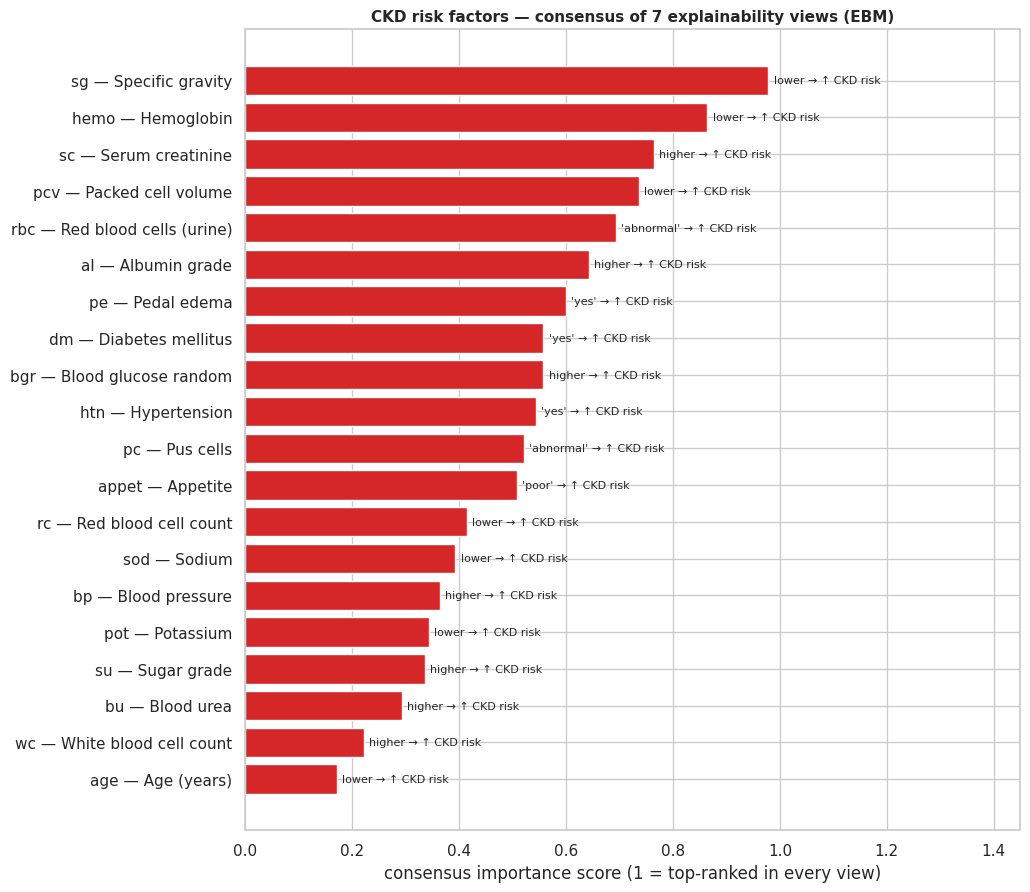

In [40]:
views = {"Boruta–SHAP (train)": boruta_table.loc[FEATS, "mean |SHAP|"].astype(float),
         "SHAP (proposed)": mean_abs_shap,
         "LIME (class-wise)": lime_cls[["mean |w| (CKD, toward CKD)", "mean |w| (Non-CKD, toward Non-CKD)"]].mean(axis=1),
         "Morris μ*": morris_df["μ* (absolute mean effect)"],
         "Permutation (Brier)": perm_df["Brier increase (mean)"],
         "Permutation (AUC)": perm_df["AUC drop (mean)"],
         "Surrogate tree": pd.Series(surrogates[PROPOSED].feature_importances_, index=FEATS)}
rank_tab = pd.DataFrame({k: v.reindex(FEATS).rank(ascending=False, method="average") for k, v in views.items()})
rank_tab["consensus rank (mean)"] = rank_tab.mean(axis=1)
rank_tab = rank_tab.sort_values("consensus rank (mean)")

risk_rows = []
Xtr_c = X_train_sel.copy()
ytr_c = y_train_clean.to_numpy()
for f in rank_tab.index:
    rho = stats.spearmanr(X_test_sel[f], shap_df[f]).correlation if X_test_sel[f].nunique() > 1 else np.nan
    if f in CATEGORICAL_COLS:
        lv = list(prep.encoder_.encoders_[f].classes_)
        risky = lv[1] if (rho or 0) > 0 else lv[0]
        direction = f"'{risky}' → ↑ CKD risk" if abs(rho or 0) >= 0.1 else "weak / inconsistent"
        ckd_stat = f"{(Xtr_c.loc[ytr_c == 1, f] == 1).mean():.0%} '{lv[1]}'"
        non_stat = f"{(Xtr_c.loc[ytr_c == 0, f] == 1).mean():.0%} '{lv[1]}'"
    else:
        direction = ("higher → ↑ CKD risk" if rho >= 0.1 else "lower → ↑ CKD risk" if rho <= -0.1 else "weak / non-monotonic")
        ckd_stat = f"median {Xtr_c.loc[ytr_c == 1, f].median():.3g}"
        non_stat = f"median {Xtr_c.loc[ytr_c == 0, f].median():.3g}"
    risk_rows.append({"feature": f, "clinical name": FEATURE_LABELS.get(f, f),
                      "consensus rank": round(rank_tab.at[f, "consensus rank (mean)"], 2),
                      "direction (from SHAP)": direction, "Spearman(value, SHAP)": round(float(rho), 3) if rho == rho else np.nan,
                      "CKD patients (train)": ckd_stat, "Non-CKD patients (train)": non_stat})
risk_df = save_table(pd.DataFrame(risk_rows).set_index("feature"), "16_ckd_risk_factors")
save_table(rank_tab.round(2), "16_risk_factor_rank_views")
print("Ranks of each feature in each importance view (1 = most important):")
display(rank_tab.round(2))
print("\nIdentified CKD risk factors (ordered by consensus):")
display(risk_df)

score = (P_FEATS + 1 - rank_tab["consensus rank (mean)"]) / P_FEATS
fig, ax = plt.subplots(figsize=(10, 0.42 * P_FEATS + 2))
cols = ["tab:red" if "↑" in risk_df.at[f, "direction (from SHAP)"] else "tab:grey" for f in score.index]
ax.barh([f"{f} — {FEATURE_LABELS.get(f, f)}" for f in score.index][::-1], score.values[::-1], color=cols[::-1])
for yi, f in enumerate(score.index[::-1]):
    ax.text(score[f] + 0.01, yi, risk_df.at[f, "direction (from SHAP)"], va="center", fontsize=8)
ax.set_xlim(0, 1.45)
ax.set_xlabel("consensus importance score (1 = top-ranked in every view)")
ax.set_title(f"CKD risk factors — consensus of 7 explainability views ({PROPOSED})")
save_fig(fig, "16_ckd_risk_factors")
TOP_RISK = list(rank_tab.index[:min(8, P_FEATS)])

## 17. Summary and export

In [41]:
ci_p = ci_cv[PROPOSED]
rob_p = rob_df[rob_df.model == PROPOSED]
summary_md = f"""
**Data.** {len(df)} patients ({int(y_all.sum())} CKD / {int((1 - y_all).sum())} Non-CKD); `id` deleted; {len(clean_log['implausible_values'])} impossible
values set to missing; stratified {int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)} split performed **before** any fitted preprocessing.

**Preprocessing (training split only).** LabelEncoder → MICE–ExtraTrees → Isolation Forest (removed {int(prep.train_if_flags_.sum())} training rows,
0 features, 0 test rows) → Boruta–SHAP selected **{len(SELECTED_FEATURES)} / {len(FEATURES_ALL)}** features: {', '.join(SELECTED_FEATURES)}.

**Models.** {len(ACTIVE_BASE_MODELS)} individual learners ({', '.join(ACTIVE_BASE_MODELS)}) + stacking, soft-voting and weighted-voting ensembles.
TabPFN status: {'included' if TABPFN_AVAILABLE else 'NOT available in this session — ' + TABPFN_STATUS[:120]}.

**Proposed model: {PROPOSED}.** Leakage-free (nested) 10-fold CV — AUC {ci_p.at['AUC', 'estimate']:.4f} [95% CI {ci_p.at['AUC', 'CI low']:.4f}–{ci_p.at['AUC', 'CI high']:.4f}],
accuracy {ci_p.at['Accuracy', 'estimate']:.4f} [{ci_p.at['Accuracy', 'CI low']:.4f}–{ci_p.at['Accuracy', 'CI high']:.4f}],
recall {ci_p.at['Recall (TPR)', 'estimate']:.4f}, specificity (TNR) {ci_p.at['TNR', 'estimate']:.4f}, Brier {ci_p.at['Brier', 'estimate']:.4f},
Kappa {ci_p.at['Kappa', 'estimate']:.4f}; cost {ci_p.at['Cost', 'estimate']:.3f} per patient under the 5:1 cost matrix
(treat-all {treat_all_cost:.3f}). Hold-out test (n = 80): accuracy {holdout_tuned.at[PROPOSED, 'Accuracy']:.4f}, AUC {holdout_tuned.at[PROPOSED, 'AUC']:.4f}.
Across {len(ROBUST_SEEDS)} random seeds: accuracy {rob_p['Accuracy'].mean():.4f} ± {rob_p['Accuracy'].std(ddof=1):.4f},
AUC {rob_p['AUC'].mean():.4f} ± {rob_p['AUC'].std(ddof=1):.4f}.

**Significance.** Against the proposed model, {int(sig_df[(sig_df.metric == 'Accuracy')]['significant (corrected, Holm < 0.05)'].sum())} of
{len(ALL_MODELS) - 1} competitors differ significantly in accuracy after correction (corrected paired t-test, Holm) — differences among the top
models on this dataset are small and should be reported as such.

**Top CKD risk factors (consensus):** {', '.join(f'{f} ({FEATURE_LABELS.get(f, f)}; {risk_df.at[f, "direction (from SHAP)"]})' for f in TOP_RISK)}.
"""
display(Markdown(summary_md))
(OUT_DIR / "summary.md").write_text(summary_md, encoding="utf-8")

final_table = pd.DataFrame({"CV mean ± SD AUC": cv_pm["AUC"], "CV mean ± SD Accuracy": cv_pm["Accuracy"],
                            "CV mean ± SD F1": cv_pm["F1-score"], "CV mean ± SD Recall": cv_pm["Recall (TPR)"],
                            "hold-out AUC": holdout_tuned["AUC"].round(4), "hold-out Accuracy": holdout_tuned["Accuracy"].round(4),
                            "overall rank": selection["position"]}).sort_values("overall rank")
display(save_table(final_table, "17_final_model_table"))

try:
    with open(OUT_DIR / "proposed_model.pkl", "wb") as fh:
        pickle.dump({"model": PROPOSED_MODEL, "name": PROPOSED, "features": SELECTED_FEATURES, "preprocessor": prep}, fh)
    print("Saved proposed model + fitted preprocessor -> proposed_model.pkl")
except Exception as e:
    print("Could not pickle the proposed model:", e)

zip_path = OUT_DIR.parent / "ckd_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in OUT_DIR.rglob("*"):
        if fpath.is_file():
            zf.write(fpath, fpath.relative_to(OUT_DIR.parent))
print(f"All figures/tables exported to {OUT_DIR} and zipped to {zip_path}")
print(f"Total notebook run time: {(time.time() - NOTEBOOK_START) / 60:.1f} min")


**Data.** 400 patients (250 CKD / 150 Non-CKD); `id` deleted; 3 impossible
values set to missing; stratified 80/20 split performed **before** any fitted preprocessing.

**Preprocessing (training split only).** LabelEncoder → MICE–ExtraTrees → Isolation Forest (removed 16 training rows,
0 features, 0 test rows) → Boruta–SHAP selected **20 / 24** features: sg, hemo, sc, pcv, al, rbc, dm, rc, bgr, htn, sod, bu, su, bp, appet, pe, pc, pot, age, wc.

**Models.** 8 individual learners (XGBoost, CatBoost, LightGBM, Random Forest, Extra Trees, HistGradientBoosting, EBM, TabPFN) + stacking, soft-voting and weighted-voting ensembles.
TabPFN status: included.

**Proposed model: EBM.** Leakage-free (nested) 10-fold CV — AUC 1.0000 [95% CI 1.0000–1.0000],
accuracy 1.0000 [1.0000–1.0000],
recall 1.0000, specificity (TNR) 1.0000, Brier 0.0001,
Kappa 1.0000; cost 1.000 per patient under the 5:1 cost matrix
(treat-all 2.500). Hold-out test (n = 80): accuracy 1.0000, AUC 1.0000.
Across 10 random seeds: accuracy 0.9925 ± 0.0121,
AUC 0.9999 ± 0.0002.

**Significance.** Against the proposed model, 0 of
10 competitors differ significantly in accuracy after correction (corrected paired t-test, Holm) — differences among the top
models on this dataset are small and should be reported as such.

**Top CKD risk factors (consensus):** sg (Specific gravity; lower → ↑ CKD risk), hemo (Hemoglobin; lower → ↑ CKD risk), sc (Serum creatinine; higher → ↑ CKD risk), pcv (Packed cell volume; lower → ↑ CKD risk), rbc (Red blood cells (urine); 'abnormal' → ↑ CKD risk), al (Albumin grade; higher → ↑ CKD risk), pe (Pedal edema; 'yes' → ↑ CKD risk), dm (Diabetes mellitus; 'yes' → ↑ CKD risk).


,CV mean ± SD AUC,CV mean ± SD Accuracy,CV mean ± SD F1,CV mean ± SD Recall,hold-out AUC,hold-out Accuracy,overall rank
EBM,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0,1.0,1
Stacking Ensemble,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0,1.0,2
TabPFN,1.0000 ± 0.0000,0.9950 ± 0.0105,0.9959 ± 0.0086,0.9920 ± 0.0169,1.0,1.0,3
Random Forest,1.0000 ± 0.0000,0.9950 ± 0.0158,0.9958 ± 0.0132,0.9920 ± 0.0253,1.0,1.0,4
Extra Trees,1.0000 ± 0.0000,0.9950 ± 0.0105,0.9959 ± 0.0086,0.9920 ± 0.0169,1.0,1.0,5
Weighted Voting Ensemble,1.0000 ± 0.0000,0.9950 ± 0.0105,0.9959 ± 0.0086,0.9920 ± 0.0169,1.0,1.0,6
XGBoost,0.9995 ± 0.0017,0.9925 ± 0.0121,0.9939 ± 0.0099,0.9880 ± 0.0193,1.0,1.0,7
Soft Voting Ensemble,1.0000 ± 0.0000,0.9925 ± 0.0121,0.9939 ± 0.0099,0.9880 ± 0.0193,1.0,1.0,8
LightGBM,1.0000 ± 0.0000,0.9900 ± 0.0129,0.9918 ± 0.0105,0.9840 ± 0.0207,1.0,1.0,9
HistGradientBoosting,1.0000 ± 0.0000,0.9900 ± 0.0129,0.9918 ± 0.0105,0.9840 ± 0.0207,1.0,1.0,10


Saved proposed model + fitted preprocessor -> proposed_model.pkl
All figures/tables exported to /kaggle/working/ckd_outputs and zipped to /kaggle/working/ckd_outputs.zip
Total notebook run time: 101.5 min
